In [1]:
from pathlib import Path
import sys

from google.cloud import bigquery

import numpy as np
import pandas as pd
from scipy import stats
from statsmodels.tsa.stattools import pacf

CURRENT_DIR = Path.cwd().resolve()
PROJECT_ROOT = CURRENT_DIR.parent

SRC_DIR = PROJECT_ROOT / "src"
DATA_DIR = PROJECT_ROOT / "data"

# Make the project utilities available when the notebook is executed
# from the notebooks directory.
if str(SRC_DIR) not in sys.path:
    sys.path.append(str(SRC_DIR))

from eda_utils import *

# AgriClimate Intelligence - Exploratory Data Analysis

This notebook examines the two curated datasets used by the project:

- a monthly climate dataset at province level;
- an annual production dataset at province and crop level.

The current stage covers data structure, internal consistency, completeness, univariate analysis and the temporal behaviour of agricultural yield. The construction of crop-season features and their bivariate relationship with the target will be added after these checks.

The notebook assumes the following project structure:

```text
project/
├── data/
│   └── climate_full_dataset.csv
│   └── production_full_dataset.csv
├── notebooks/
│   └── EDA_AgriClimate_Intelligence.ipynb
└── src/
    ├── province_transformation.py
    └── eda_utils.py
```

`province_transformation.py` contains the utilities used in the transformation pipeline, while `eda_utils.py` contains reusable functions for exploratory analysis and visualisation.

**IMPORTANT**: `data` folder is an alternative proposed to the download of the datasets using BigQuery, which is the default option proposed below. In case BigQuery is used the presence of `data` folder is, therefore, not mandatory.

In [2]:
# Optional local sources can be used instead of BigQuery when exported
# copies of the curated tables are available in the data directory.

CLIMATE_DATA = DATA_DIR / "climate_full_dataset.csv"
PRODUCTION_DATA = DATA_DIR / "production_full_dataset.csv"

climate_df = pd.read_csv(CLIMATE_DATA)
production_df = pd.read_csv(PRODUCTION_DATA)

In [3]:
# BigQuery sources containing the transformed climate and production data.
PROJECT_ID = "agriclimate-intelligence"
DATASET_ID = "curated"

CLIMATE_TABLE_ID = "climate_full_dataset_v1"
PRODUCTION_TABLE_ID = "production_full_dataset_v1"

CLIMATE_TABLE = (
    f"{PROJECT_ID}.{DATASET_ID}.{CLIMATE_TABLE_ID}"
)

PRODUCTION_TABLE = (
    f"{PROJECT_ID}.{DATASET_ID}.{PRODUCTION_TABLE_ID}"
)

# Application Default Credentials are used by the BigQuery client.
#bq_client = bigquery.Client(
#    project=PROJECT_ID
#)

In [4]:
# Load both curated tables and inspect their first and last rows.
#climate_df = (
#    bq_client
#    .list_rows(CLIMATE_TABLE)
#    .to_dataframe()
#)

print("CLIMATE DATA\n")
display(climate_df.head())
display(climate_df.tail())
climate_df.info()

#production_df = (
#    bq_client
#    .list_rows(PRODUCTION_TABLE)
#    .to_dataframe()
#)

print("\nPRODUCTION DATA\n")
display(production_df.head())
display(production_df.tail())
production_df.info()

CLIMATE DATA



,YEAR_MONTH,OBSERVED_DAYS,N_CELLS,TEMPERATURE_AVG_MONTH,TEMPERATURE_MAX_MONTH,TEMPERATURE_MIN_MONTH,PRECIPITATION_DAILY_AVG,PRECIPITATION_LOCAL_DAILY_MAX,WINDSPEED_AVG_MONTH,WINDSPEED_LOCAL_MAX,...,MAX_CONSECUTIVE_FROST_10PCT_DAYS,MAX_CONSECUTIVE_HOT_30_10PCT_DAYS,MAX_CONSECUTIVE_HOT_35_10PCT_DAYS,ALTITUDE_MEAN,ALTITUDE_STD,ALTITUDE_MIN,ALTITUDE_MAX,ALTITUDE_RANGE,PROVINCE,REGION
0,1980-01,31,58,10.145884,19.4,0.5,0.765295,14,4.899889,15.0,...,0,0,0,256.655172,200.313224,1,864,863,Agrigento,Sicilia
1,1980-02,29,58,10.290428,19.3,0.9,0.543401,7,3.449287,14.8,...,0,0,0,256.655172,200.313224,1,864,863,Agrigento,Sicilia
2,1980-03,31,58,11.562514,21.7,0.9,1.922136,17,3.984483,10.6,...,0,0,0,256.655172,200.313224,1,864,863,Agrigento,Sicilia
3,1980-04,30,58,11.819885,21.5,2.5,0.945402,9,4.083966,10.9,...,0,0,0,256.655172,200.313224,1,864,863,Agrigento,Sicilia
4,1980-05,31,58,15.488710,26.5,5.9,0.736930,16,4.362681,10.9,...,0,0,0,256.655172,200.313224,1,864,863,Agrigento,Sicilia


,YEAR_MONTH,OBSERVED_DAYS,N_CELLS,TEMPERATURE_AVG_MONTH,TEMPERATURE_MAX_MONTH,TEMPERATURE_MIN_MONTH,PRECIPITATION_DAILY_AVG,PRECIPITATION_LOCAL_DAILY_MAX,WINDSPEED_AVG_MONTH,WINDSPEED_LOCAL_MAX,...,MAX_CONSECUTIVE_FROST_10PCT_DAYS,MAX_CONSECUTIVE_HOT_30_10PCT_DAYS,MAX_CONSECUTIVE_HOT_35_10PCT_DAYS,ALTITUDE_MEAN,ALTITUDE_STD,ALTITUDE_MIN,ALTITUDE_MAX,ALTITUDE_RANGE,PROVINCE,REGION
58507,2025-08,31,56,25.247984,41.7,12.1,2.453341,66,1.663998,5.9,...,0,18,10,248.017857,158.827807,4,626,622,Viterbo,Lazio
58508,2025-09,30,56,21.571548,33.7,7.9,3.529762,54,1.534643,6.3,...,0,7,0,248.017857,158.827807,4,626,622,Viterbo,Lazio
58509,2025-10,31,56,16.275230,28.8,1.1,1.506912,43,2.005300,11.4,...,0,0,0,248.017857,158.827807,4,626,622,Viterbo,Lazio
58510,2025-11,30,56,11.943095,25.7,-5.0,2.453571,36,1.861369,9.9,...,1,0,0,248.017857,158.827807,4,626,622,Viterbo,Lazio
58511,2025-12,31,56,9.491820,19.4,-5.0,1.984447,42,1.493952,5.4,...,3,0,0,248.017857,158.827807,4,626,622,Viterbo,Lazio


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 58512 entries, 0 to 58511
Data columns (total 74 columns):
 #   Column                                  Non-Null Count  Dtype  
---  ------                                  --------------  -----  
 0   YEAR_MONTH                              58512 non-null  object 
 1   OBSERVED_DAYS                           58512 non-null  int64  
 2   N_CELLS                                 58512 non-null  int64  
 3   TEMPERATURE_AVG_MONTH                   58512 non-null  float64
 4   TEMPERATURE_MAX_MONTH                   58512 non-null  float64
 5   TEMPERATURE_MIN_MONTH                   58512 non-null  float64
 6   PRECIPITATION_DAILY_AVG                 58512 non-null  float64
 7   PRECIPITATION_LOCAL_DAILY_MAX           58512 non-null  int64  
 8   WINDSPEED_AVG_MONTH                     58512 non-null  float64
 9   WINDSPEED_LOCAL_MAX                     58512 non-null  float64
 10  VAPOURPRESSURE_AVG_MONTH                58512 non-null  fl

,province,year,crop_name,area,production,yield,q_cv_group,q_area_coverage,q_n_regions_used,q_n_expected_regions,q_n_missing_regions,q_n_structural_zero_regions,q_source_status,q_apy_incoherent,q_calculated_region
0,Agrigento,1995,Durum wheat,50190.0,79199.8,1.578000,Agrigento,1.0,1,1,0,0,complete,False,False
1,Agrigento,1996,Durum wheat,51520.0,114776.2,2.227799,Agrigento,1.0,1,1,0,0,complete,False,False
2,Agrigento,1997,Durum wheat,50200.0,120480.0,2.400000,Agrigento,1.0,1,1,0,0,complete,False,False
3,Agrigento,1998,Durum wheat,34039.0,81693.6,2.400000,Agrigento,1.0,1,1,0,0,complete,False,False
4,Agrigento,1999,Durum wheat,48000.0,96000.0,2.000000,Agrigento,1.0,1,1,0,0,complete,False,False


,province,year,crop_name,area,production,yield,q_cv_group,q_area_coverage,q_n_regions_used,q_n_expected_regions,q_n_missing_regions,q_n_structural_zero_regions,q_source_status,q_apy_incoherent,q_calculated_region
7571,Viterbo,2021,Grain maize,1770.0,17170.0,9.700565,Viterbo,1.0,1,1,0,0,complete,False,False
7572,Viterbo,2021,Soft wheat,2690.0,12850.0,4.776952,Viterbo,1.0,1,1,0,0,complete,False,False
7573,Viterbo,2022,Durum wheat,19740.0,62900.0,3.186424,Viterbo,1.0,1,1,0,0,complete,False,False
7574,Viterbo,2022,Grain maize,1770.0,17000.0,9.604520,Viterbo,1.0,1,1,0,0,complete,False,False
7575,Viterbo,2022,Soft wheat,2680.0,11300.0,4.216418,Viterbo,1.0,1,1,0,0,complete,False,False


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7576 entries, 0 to 7575
Data columns (total 15 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   province                     7576 non-null   object 
 1   year                         7576 non-null   int64  
 2   crop_name                    7576 non-null   object 
 3   area                         7576 non-null   float64
 4   production                   7576 non-null   float64
 5   yield                        7576 non-null   float64
 6   q_cv_group                   7576 non-null   object 
 7   q_area_coverage              7576 non-null   float64
 8   q_n_regions_used             7576 non-null   int64  
 9   q_n_expected_regions         7576 non-null   int64  
 10  q_n_missing_regions          7576 non-null   int64  
 11  q_n_structural_zero_regions  7576 non-null   int64  
 12  q_source_status              7576 non-null   object 
 13  q_apy_incoherent  

### Dataset overview

The climate table contains **58,512 monthly observations and 74 columns**. Each row describes one of 106 production areas in one calendar month, covering the period from January 1980 to December 2025. The complete structure corresponds to 106 areas × 552 months.

The production table contains **7,576 annual observations and 15 columns**. Each row represents one province, one year and one crop. It covers 105 provinces, the years 1995–2022 and three crops: durum wheat, grain maize and soft wheat.

Neither table contains explicit null values. This does not by itself guarantee that every expected province–year–crop combination is present, so the completeness of the production dataset is examined separately below.

In [5]:
# Summarise data type, cardinality and missing values for the climate table.
pd.set_option("display.max_rows", None)
summarize_columns(climate_df)
pd.reset_option("display.max_rows")

,Column,Data Type,Total Values,Unique Values,NaN Values,NaN %
0,YEAR_MONTH,object,58512,552,0,0.0
1,OBSERVED_DAYS,int64,58512,4,0,0.0
2,N_CELLS,int64,58512,60,0,0.0
3,TEMPERATURE_AVG_MONTH,float64,58512,58252,0,0.0
4,TEMPERATURE_MAX_MONTH,float64,58512,379,0,0.0
5,TEMPERATURE_MIN_MONTH,float64,58512,511,0,0.0
6,PRECIPITATION_DAILY_AVG,float64,58512,48760,0,0.0
7,PRECIPITATION_LOCAL_DAILY_MAX,int64,58512,228,0,0.0
8,WINDSPEED_AVG_MONTH,float64,58512,56511,0,0.0
9,WINDSPEED_LOCAL_MAX,float64,58512,283,0,0.0


In [6]:
# Apply the same summary to the production table.
pd.set_option("display.max_rows", None)
summarize_columns(production_df)
pd.reset_option("display.max_rows")

,Column,Data Type,Total Values,Unique Values,NaN Values,NaN %
0,province,object,7576,105,0,0.0
1,year,int64,7576,28,0,0.0
2,crop_name,object,7576,3,0,0.0
3,area,float64,7576,3473,0,0.0
4,production,float64,7576,5727,0,0.0
5,yield,float64,7576,4898,0,0.0
6,q_cv_group,object,7576,97,0,0.0
7,q_area_coverage,float64,7576,12,0,0.0
8,q_n_regions_used,int64,7576,3,0,0.0
9,q_n_expected_regions,int64,7576,3,0,0.0


The column summaries confirm that all fields are populated. Their cardinality also reflects the different nature of the variables:

- continuous meteorological measurements have many distinct values;
- event counts and maximum sequence lengths take a limited set of integer values;
- province-level characteristics are repeated across monthly observations;
- quality fields in the production table describe how each annual observation was reconstructed.

A zero in an event-related climate variable is a valid value and generally indicates that the event did not occur during that province-month.

In [7]:
# Separate identifiers, static province characteristics and monthly
# climate variables without relying on their position in the table.
IDENTIFIER_COLUMNS = [
    "YEAR_MONTH",
    "OBSERVED_DAYS",
    "PROVINCE",
    "REGION"
]

STATIC_COLUMNS = [
    "N_CELLS",
    "ALTITUDE_MIN",
    "ALTITUDE_MAX",
    "ALTITUDE_RANGE",
    "ALTITUDE_MEAN",
    "ALTITUDE_STD"
]

CLIMATE_COLUMNS = [
    column
    for column in climate_df.columns
    if column not in (
        IDENTIFIER_COLUMNS
        + STATIC_COLUMNS
    )
]

### Internal consistency checks

The climate table is expected to contain one row for every province and calendar month. The following checks verify the uniqueness of this key, the correspondence between `OBSERVED_DAYS` and the calendar, and some relationships imposed by the transformation pipeline.

In [8]:
# Convert the monthly identifier only for the checks that require
# calendar information; the original column is left unchanged.
year_month = pd.to_datetime(
    climate_df["YEAR_MONTH"],
    format="%Y-%m"
)

In [9]:
# A province-month key must be unique and each row must contain the
# complete number of days of its calendar month.
print(
    "Duplicated climate keys:",
    climate_df.duplicated(
        ["PROVINCE", "YEAR_MONTH"]
    ).sum()
)

print(
    "Rows with incomplete month length:",
    (
        climate_df["OBSERVED_DAYS"]
        != year_month.dt.days_in_month
    ).sum()
)

Duplicated climate keys: 0
Rows with incomplete month length: 0


In [10]:
# Monthly minimum, average and maximum temperature must preserve
# their natural ordering.
temperature_violation = (
    (
        climate_df["TEMPERATURE_MIN_MONTH"]
        > climate_df["TEMPERATURE_AVG_MONTH"]
    )
    |
    (
        climate_df["TEMPERATURE_AVG_MONTH"]
        > climate_df["TEMPERATURE_MAX_MONTH"]
    )
)

print(
    "Temperature ordering violations:",
    temperature_violation.sum()
)

Temperature ordering violations: 0


In [11]:
# Wet and dry day counts are complementary and should sum to the
# number of observed days.
wet_dry_violation = ~np.isclose(
    climate_df["WET_DAYS_AREA_MEAN"]
    + climate_df["DRY_DAYS_AREA_MEAN"],
    climate_df["OBSERVED_DAYS"]
)

print(
    "Wet/dry complement violations:",
    wet_dry_violation.sum()
)

Wet/dry complement violations: 0


In [12]:
# No day count or maximum sequence length can exceed the number of
# days observed in the month.
day_count_columns = [
    column
    for column in CLIMATE_COLUMNS
    if column.startswith(
        (
            "DAYS_",
            "MAX_CONSECUTIVE_",
            "WET_DAYS_",
            "DRY_DAYS_"
        )
    )
]

day_count_violations = (
    climate_df[day_count_columns]
    .gt(
        climate_df["OBSERVED_DAYS"],
        axis=0
    )
)

print(
    "Day-count values above observed days:",
    day_count_violations.sum().sum()
)

Day-count values above observed days: 0


All checks return zero violations. The climate dataset therefore has unique province-month keys, complete calendar months and internally coherent temperature, wet/dry and duration indicators.

### Province-level features

Some columns describe stable characteristics of each production area rather than monthly climate. They are repeated for every month and are therefore extracted into a table with one row per province before their distributions are examined. This avoids giving additional weight to a province simply because it appears once for every month.

In [13]:
# Keep one row for each distinct set of province-level characteristics.
provinces = (
    climate_df[
        [
            "PROVINCE",
            "REGION"
        ]
        + STATIC_COLUMNS
    ]
    .drop_duplicates(
        ignore_index=True
    )
)

In [14]:
display(provinces.head())
display(provinces.tail())
provinces.info()

,PROVINCE,REGION,N_CELLS,ALTITUDE_MIN,ALTITUDE_MAX,ALTITUDE_RANGE,ALTITUDE_MEAN,ALTITUDE_STD
0,Agrigento,Sicilia,58,1,864,863,256.655172,200.313224
1,Alessandria,Piemonte,56,77,932,855,243.017857,189.006829
2,Ancona,Marche,35,29,562,533,229.800000,155.172162
3,Arezzo,Toscana,51,157,863,706,369.686275,168.063380
4,Ascoli Piceno,Marche,24,0,1353,1353,434.291667,353.373737


,PROVINCE,REGION,N_CELLS,ALTITUDE_MIN,ALTITUDE_MAX,ALTITUDE_RANGE,ALTITUDE_MEAN,ALTITUDE_STD
101,Vercelli,Piemonte,36,103,2485,2382,572.722222,626.408886
102,Verona,Veneto,49,10,1060,1050,197.163265,263.993477
103,Vibo Valentia,Calabria,24,7,997,990,408.916667,281.760755
104,Vicenza,Veneto,45,14,1179,1165,345.600000,387.341193
105,Viterbo,Lazio,56,4,626,622,248.017857,158.827807


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 106 entries, 0 to 105
Data columns (total 8 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   PROVINCE        106 non-null    object 
 1   REGION          106 non-null    object 
 2   N_CELLS         106 non-null    int64  
 3   ALTITUDE_MIN    106 non-null    int64  
 4   ALTITUDE_MAX    106 non-null    int64  
 5   ALTITUDE_RANGE  106 non-null    int64  
 6   ALTITUDE_MEAN   106 non-null    float64
 7   ALTITUDE_STD    106 non-null    float64
dtypes: float64(2), int64(4), object(2)
memory usage: 6.8+ KB


In [15]:
print(
    "Number of different provinces:",
    climate_df["PROVINCE"].nunique()
)

Number of different provinces: 106


The province-level table contains exactly **106 rows**, matching the 106 unique values of `PROVINCE` in the climate table. Each province is therefore associated with a single stable value for the number of grid cells and for all altitude indicators. Their repetition in the monthly table reflects the repeated monthly structure of the dataset and not a data inconsistency.

In [16]:
# Descriptive statistics for the static province features.
display(
    provinces
    .describe(include="all")
    .T
)

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
PROVINCE,106,106,Agrigento,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
REGION,106,20,Lombardia,12,NaN,NaN,NaN,NaN,NaN,NaN,NaN
N_CELLS,106.0,NaN,NaN,NaN,47.132075,23.197321,8.0,32.0,43.0,56.75,112.0
ALTITUDE_MIN,106.0,NaN,NaN,NaN,46.90566,71.422623,0.0,1.0,9.0,63.5,321.0
ALTITUDE_MAX,106.0,NaN,NaN,NaN,1021.858491,652.470768,13.0,611.75,962.5,1303.75,2869.0
ALTITUDE_RANGE,106.0,NaN,NaN,NaN,974.95283,616.25504,12.0,559.5,924.5,1208.5,2661.0
ALTITUDE_MEAN,106.0,NaN,NaN,NaN,368.109783,306.307687,4.8125,199.371552,312.134167,432.380515,1817.45098
ALTITUDE_STD,106.0,NaN,NaN,NaN,265.241616,169.011165,3.963035,159.686041,244.386514,344.538002,796.279262


Detected type for 'REGION': categorical
'REGION': 0 missing (0.0%)


,Region,abs_freq,rel_freq_%
0,Lombardia,12,11.32
1,Toscana,10,9.43
2,Emilia-Romagna,9,8.49
3,Sicilia,9,8.49
4,Piemonte,8,7.55
5,Veneto,7,6.60
6,Puglia,6,5.66
7,Marche,5,4.72
8,Campania,5,4.72
9,Calabria,5,4.72


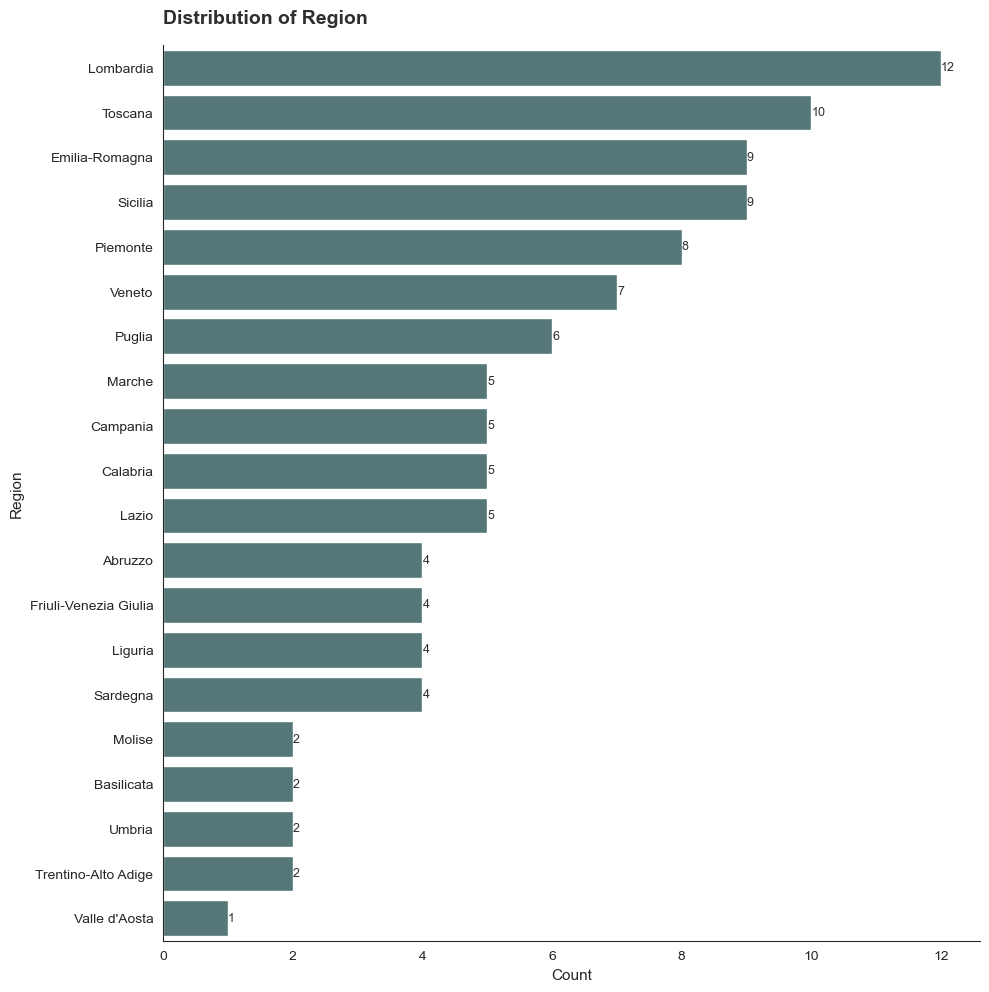

Detected type for 'N_CELLS': continuous
'N_CELLS': 0 missing (0.0%)
Skew: 0.968


,count,mean,std,min,25%,50%,75%,max
N_CELLS,106.0,47.132075,23.197321,8.0,32.0,43.0,56.75,112.0


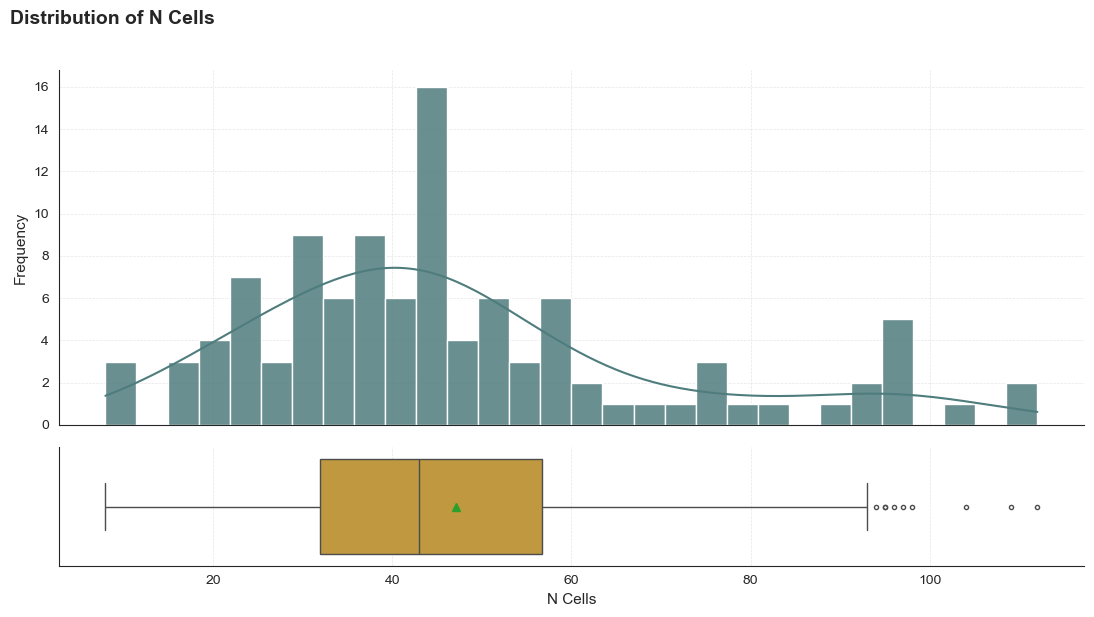

Detected type for 'ALTITUDE_MIN': continuous
'ALTITUDE_MIN': 0 missing (0.0%), 16 zeros (15.1%)
Skew: 1.747


,count,mean,std,min,25%,50%,75%,max
ALTITUDE_MIN,106.0,46.90566,71.422623,0.0,1.0,9.0,63.5,321.0


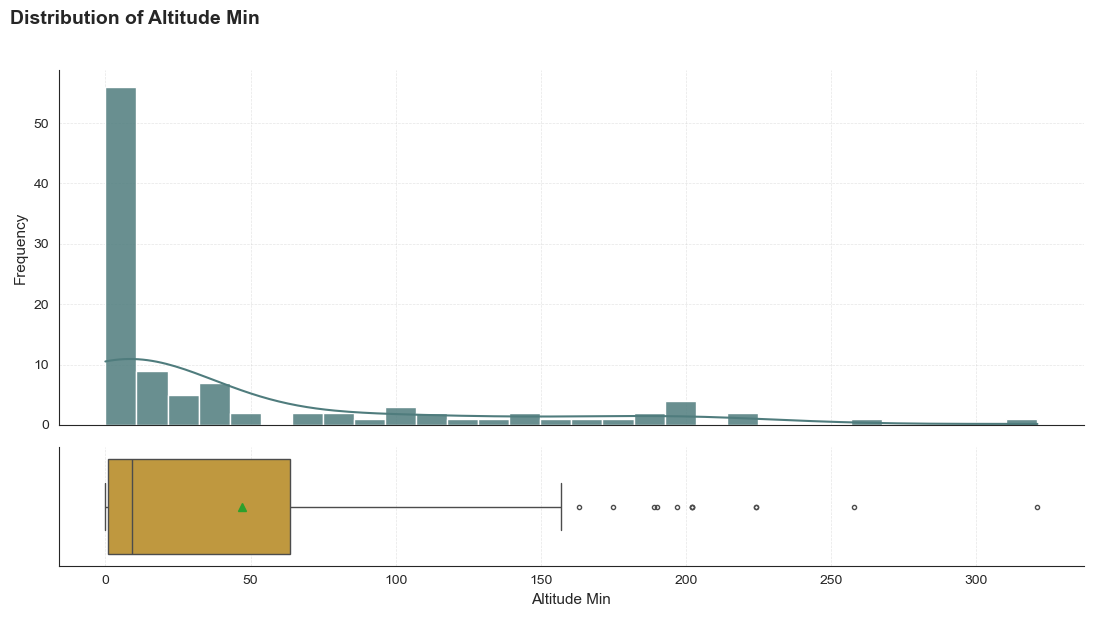

Detected type for 'ALTITUDE_MAX': continuous
'ALTITUDE_MAX': 0 missing (0.0%)
Skew: 1.053


,count,mean,std,min,25%,50%,75%,max
ALTITUDE_MAX,106.0,1021.858491,652.470768,13.0,611.75,962.5,1303.75,2869.0


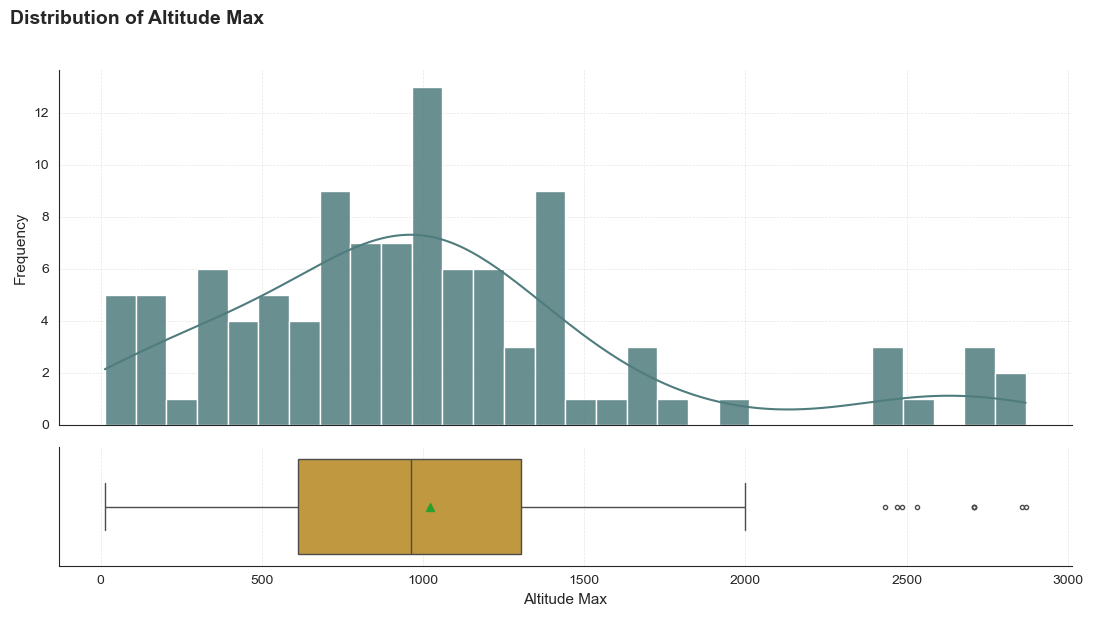

Detected type for 'ALTITUDE_RANGE': continuous
'ALTITUDE_RANGE': 0 missing (0.0%)
Skew: 0.919


,count,mean,std,min,25%,50%,75%,max
ALTITUDE_RANGE,106.0,974.95283,616.25504,12.0,559.5,924.5,1208.5,2661.0


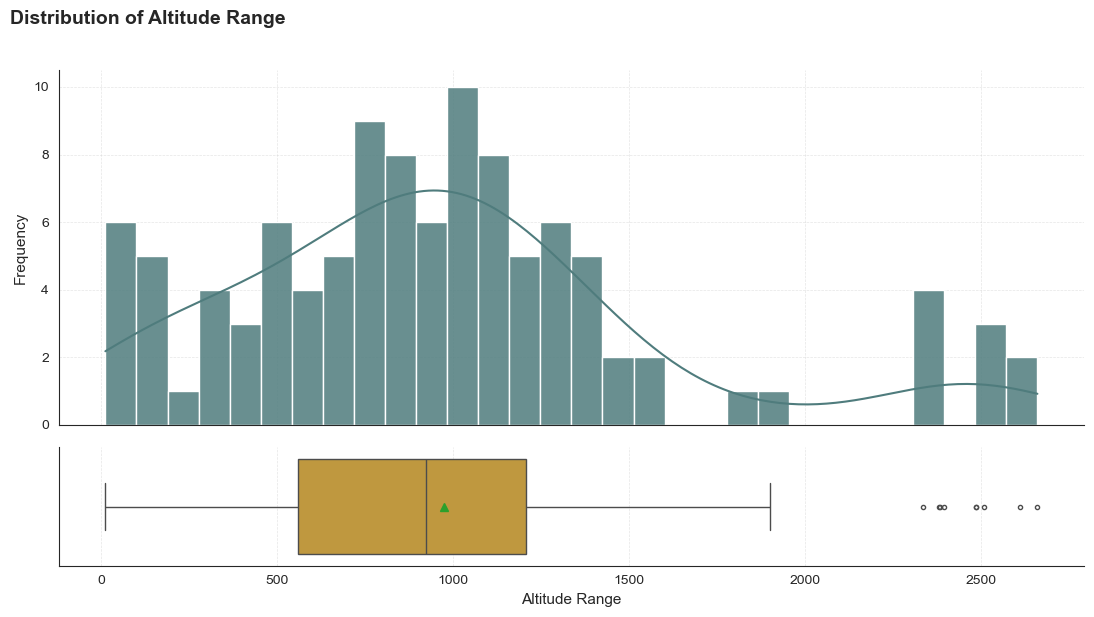

Detected type for 'ALTITUDE_MEAN': continuous
'ALTITUDE_MEAN': 0 missing (0.0%)
Skew: 2.335


,count,mean,std,min,25%,50%,75%,max
ALTITUDE_MEAN,106.0,368.109783,306.307687,4.8125,199.371552,312.134167,432.380515,1817.45098


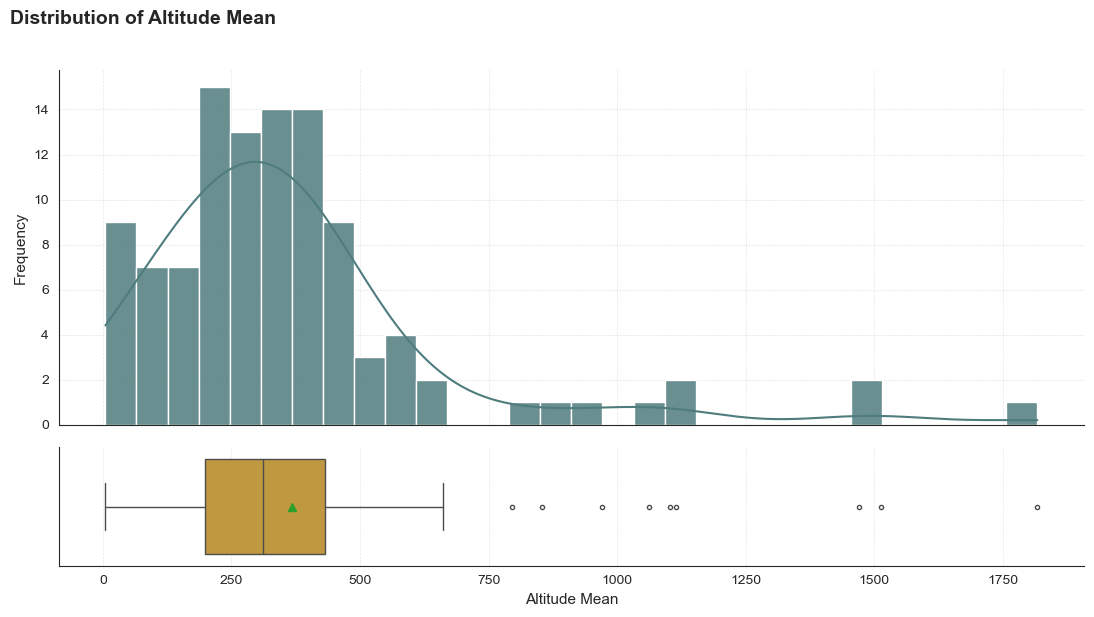

Detected type for 'ALTITUDE_STD': continuous
'ALTITUDE_STD': 0 missing (0.0%)
Skew: 0.957


,count,mean,std,min,25%,50%,75%,max
ALTITUDE_STD,106.0,265.241616,169.011165,3.963035,159.686041,244.386514,344.538002,796.279262


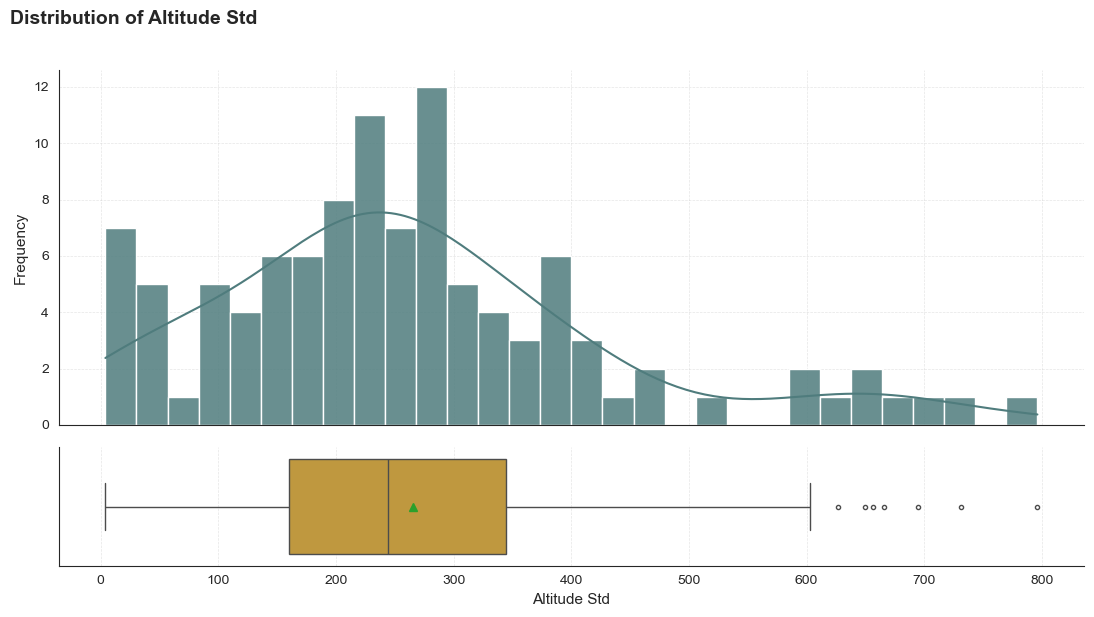

In [17]:
# Use the reusable EDA utilities to inspect each province-level variable.
for column in provinces.columns[1:]:
    kind = infer_variable_type(
        provinces[column]
    )

    if kind == "continuous":
        describe_variable(
            provinces,
            column,
            auto_log=False
        )
    else:
        describe_variable(
            provinces,
            column
        )

**Province-level observations**

The regional frequencies reflect the Italian administrative structure: for example, Lombardia contributes 12 production areas, Toscana 10, Emilia-Romagna and Sicilia 9 each, while Valle d’Aosta contributes one.

The number of grid cells ranges from 8 to 112, with a median of 43. It represents the spatial support used in the previous aggregation step and should be interpreted as a contextual variable: spatial fractions, local maxima and measures of internal variability are all affected by the number of cells available for a province (which represent the extension of their territory).

Altitude varies substantially across areas. Minimum altitude has a median of 9 metres and is equal to zero in 16 provinces, while maximum altitude reaches 2,869 metres. Mean altitude and its standard deviation are positively skewed, showing that several provinces combine lowland and elevated areas. Mean, range and standard deviation therefore describe different aspects of territorial morphology and can be used as static candidate predictors.

In [18]:
# Areas with the largest spatial support.
display(
    provinces.nlargest(
        10,
        "N_CELLS"
    )
)

,PROVINCE,REGION,N_CELLS,ALTITUDE_MIN,ALTITUDE_MAX,ALTITUDE_RANGE,ALTITUDE_MEAN,ALTITUDE_STD
83,Sassari,Sardegna,112,0,852,852,223.687500,193.815647
73,Area vasta Sud Sardegna,Sardegna,109,0,1013,1013,174.018349,215.775646
72,Provincia Autonoma di Bolzano / Autonome Provi...,Trentino-Alto Adige,104,224,2710,2486,1513.951923,602.613698
70,Potenza,Basilicata,98,39,1150,1111,595.663265,239.059021
63,Perugia,Umbria,97,189,1353,1164,439.000000,227.947499
23,Cosenza,Calabria,96,0,1389,1389,465.270833,408.125019
26,Cuneo,Piemonte,95,135,2470,2335,853.957895,656.106811
31,Foggia,Puglia,95,0,729,729,213.968421,214.471565
91,Torino,Piemonte,94,149,2533,2384,971.297872,796.279262
93,Trento,Trentino-Alto Adige,93,224,2710,2486,1103.225806,595.368449


#### Production dataset completeness

The absence of explicit null values does not guarantee that the production dataset is complete. An observation may be missing because the corresponding province-year-crop row is entirely absent from the table rather than present with empty values.

The analysis therefore begins with two internal consistency checks. The combination of province, year and crop must uniquely identify each observation, and yield must reproduce the ratio between production and cultivated area within numerical precision.

Completeness is then assessed by reconstructing the full set of combinations expected from the 105 provinces, the consecutive years from 1995 to 2022 and the three available crops. Each absent combination is classified according to its position within the corresponding province-crop series:

* `crop never reported` when the crop is never observed for that province;
* `before first year` when the absence precedes the first available observation;
* `after last year` when it follows the last available observation;
* `interruption` when it occurs between two parts of an otherwise observed series.

These categories are inspected separately because they do not have the same analytical meaning. In particular, internal interruptions are more likely to require attention when continuous time series are constructed, while observations outside the available span or crops never reported may represent structural limitations of the source.

The distribution of the absent combinations is examined across provinces, years and crops. The final part of the section considers a separate completeness dimension: the territorial coverage represented within rows that are present in the production table.

In [19]:
# Natural key of the annual production table.
PRODUCTION_KEY = [
    "province",
    "year",
    "crop_name"
]

In [20]:
print(
    "Duplicated production keys:",
    production_df
    .duplicated(PRODUCTION_KEY)
    .sum()
)

Duplicated production keys: 0


In [21]:
# Yield should be equal to production divided by cultivated area.
recomputed_yield = (
    production_df["production"]
    / production_df["area"]
)

In [22]:
print(
    "Maximum yield identity deviation:",
    (
        recomputed_yield
        - production_df["yield"]
    )
    .abs()
    .max()
)

Maximum yield identity deviation: 3.552713678800501e-15


In [23]:
# Build the table of expected data. This is
# equivalent to the Cartesian product of provinces, years and crops,
# but keeps each component visible and easy to inspect.
all_provinces = pd.DataFrame(
    {
        "province": sorted(
            production_df["province"].unique()
        )
    }
)

all_years = pd.DataFrame(
    {
        "year": range(
            int(production_df["year"].min()),
            int(production_df["year"].max()) + 1
        )
    }
)

all_crops = pd.DataFrame(
    {
        "crop_name": sorted(
            production_df["crop_name"].unique()
        )
    }
)

expected_grid = (
    all_provinces
    .merge(all_years, how="cross")
    .merge(all_crops, how="cross")
)

observed_keys = (
    production_df[PRODUCTION_KEY]
    .assign(observed=True)
)

expected_grid = expected_grid.merge(
    observed_keys,
    how="left",
    on=PRODUCTION_KEY
)

expected_grid["observed"] = (
    expected_grid["observed"]
    .eq(True)
)

In [24]:
# For every province-crop series, identify its first and last observed
# year and classify each absent row according to its position.
series_span = (
    production_df
    .groupby(
        ["province", "crop_name"],
        as_index=False
    )
    .agg(
        first_year=("year", "min"),
        last_year=("year", "max")
    )
)

expected_grid = expected_grid.merge(
    series_span,
    how="left",
    on=["province", "crop_name"]
)

missing = ~expected_grid["observed"]

never_reported = (
    missing
    & expected_grid["first_year"].isna()
)

before_first_year = (
    missing
    & expected_grid["first_year"].notna()
    & (
        expected_grid["year"]
        < expected_grid["first_year"]
    )
)

after_last_year = (
    missing
    & expected_grid["last_year"].notna()
    & (
        expected_grid["year"]
        > expected_grid["last_year"]
    )
)

expected_grid["status"] = np.select(
    [
        never_reported,
        before_first_year,
        after_last_year,
        missing
    ],
    [
        "crop never reported",
        "before first year",
        "after last year",
        "interruption"
    ],
    default="observed"
)

display(
    expected_grid["status"]
    .value_counts()
    .to_frame("cells")
)

display(
    pd.crosstab(
        expected_grid["crop_name"],
        expected_grid["status"]
    )
)

,cells
status,
observed,7576
crop never reported,476
before first year,427
after last year,193
interruption,148


status,after last year,before first year,crop never reported,interruption,observed
crop_name,,,,,
Durum wheat,66,222,140,81,2431
Grain maize,61,65,140,14,2660
Soft wheat,66,140,196,53,2485


In [25]:
# Separate all absent province-year-crop cells from the subset of
# internal gaps occurring inside an otherwise observed series.
missing_grid = (
    expected_grid.loc[
        expected_grid["status"] != "observed"
    ]
    .copy()
)

interruption_grid = (
    expected_grid.loc[
        expected_grid["status"] == "interruption"
    ]
    .copy()
)

# Keep the absence categories in a meaningful order when summaries
# are produced below.
ABSENCE_STATUS_ORDER = [
    "crop never reported",
    "before first year",
    "after last year",
    "interruption"
]

# A crop that is never reported for a province generates one absent
# cell for every year in the reconstructed grid. Reduce these cases
# to unique province-crop series before counting them.
never_reported_series = (
    expected_grid.loc[
        expected_grid["status"] == "crop never reported",
        ["province", "crop_name"]
    ]
    .drop_duplicates()
    .sort_values(
        ["crop_name", "province"]
    )
    .reset_index(drop=True)
)

print(
    "Absent province-year-crop cells:",
    len(missing_grid)
)

print(
    "Internal interruptions:",
    len(interruption_grid)
)

print(
    "Province-crop series never reported:",
    len(never_reported_series)
)

display(never_reported_series)

Absent province-year-crop cells: 1244
Internal interruptions: 148
Province-crop series never reported: 17


,province,crop_name
0,Lecco,Durum wheat
1,Massa-Carrara,Durum wheat
2,Provincia Autonoma di Bolzano / Autonome Provi...,Durum wheat
3,Savona,Durum wheat
4,Verbano-Cusio-Ossola,Durum wheat
5,Agrigento,Grain maize
6,Caltanissetta,Grain maize
7,Catania,Grain maize
8,Enna,Grain maize
9,Trapani,Grain maize


The reconstructed grid contains 8,820 expected combinations, obtained from 105 provinces, 28 years and three crops. Of these, 7,576 are observed and 1,244 are absent.

Most absent cells do not represent gaps inside an established time series:

* 476 cells are associated with crops never reported for a province;
* 427 precede the first observed year of a province-crop series;
* 193 follow its last observed year;
* 148 are interruptions between the first and last observed years.

The 476 cells classified as `crop never reported` correspond to 17 distinct province-crop series. Each of these series contributes one absent cell for every year in the reconstructed grid, **so the number of cells should not be interpreted as the number of independent structural cases**.

**Internal interruptions** are concentrated in **durum wheat** and **soft wheat**, while **grain maize has comparatively few**. These interruptions are the cases most directly comparable to missing observations inside a conventional time series and are therefore examined separately across provinces and years.

None of these cases is an explicit null value. They should not be replaced automatically with zero, because absence from the source does not demonstrate that cultivated area, production or yield was equal to zero. Their eventual treatment will depend on the requirements of the modelling dataset and on whether a continuous province-crop series is needed.

### Distribution of absent observations

A simple frequency count of all absent cells would combine situations with different meanings. It would also give disproportionate weight to crops never reported, because the same structural absence is repeated for every year in the expected grid.

The complete distribution by status is retained in the summary tables, while the main province and year visualisations focus on `interruption`. In these plots, one count corresponds to one absent province-year-crop combination occurring between the first and last observed years of that province-crop series.

Province frequencies identify the areas in which internal gaps occur most often. Annual frequencies show whether interruptions are isolated or concentrated in particular years, which may indicate broader limitations in the source rather than problems affecting a single local series.

In [26]:
# Summarise internal gaps by province. The table uses the same data
# represented in the following bar plot.
interruptions_by_province = (
    interruption_grid
    .groupby(
        "province",
        as_index=False
    )
    .agg(
        interruptions=("year", "size"),
        affected_years=("year", "nunique"),
        affected_crops=("crop_name", "nunique")
    )
    .sort_values(
        "interruptions",
        ascending=False
    )
    .reset_index(drop=True)
)

display(
    interruptions_by_province.head(20)
)

,province,interruptions,affected_years,affected_crops
0,Como,19,19,1
1,Vercelli,11,11,1
2,Monza e della Brianza,10,10,1
3,Oristano,9,8,2
4,Pordenone,8,8,1
5,Matera,7,7,2
6,Nuoro,7,7,1
7,Sassari,7,7,1
8,Valle d'Aosta / Vallée d'Aoste,7,5,3
9,Barletta-Andria-Trani,6,6,1


'province': 0 missing (0.0%)


,Province,abs_freq,rel_freq_%
0,Como,19,12.84
1,Vercelli,11,7.43
2,Monza e della Brianza,10,6.76
3,Oristano,9,6.08
4,Pordenone,8,5.41
5,Matera,7,4.73
6,Nuoro,7,4.73
7,Sassari,7,4.73
8,Valle d'Aosta / Vallée d'Aoste,7,4.73
9,Barletta-Andria-Trani,6,4.05


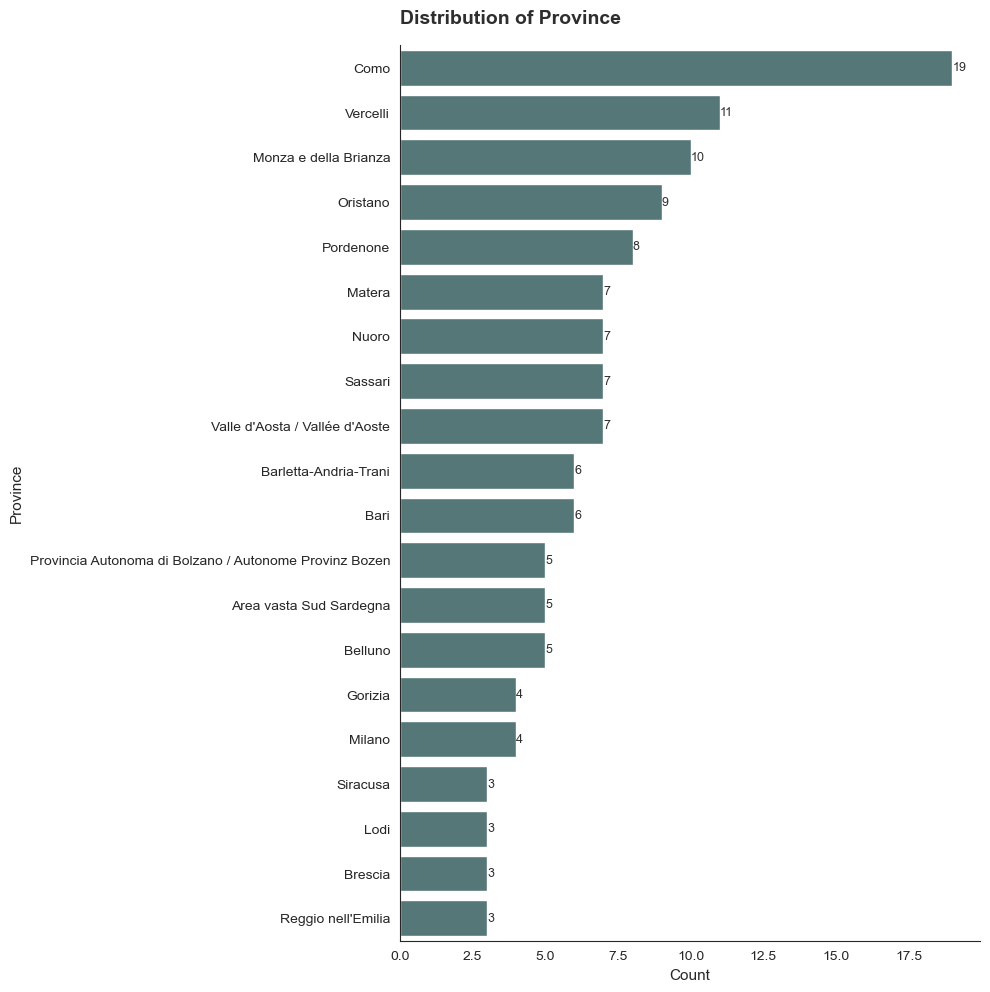

In [27]:
# Plot the provinces with the largest number of internal gaps.
# The reusable function also displays the corresponding frequency table.
plot_categorical_distribution(
    interruption_grid,
    "province",
    max_categories=20,
    horizontal=True
)

In [28]:
# Summarise every absence category by year. All years are retained,
# including those without a particular type of absence.
missing_by_year = pd.crosstab(
    missing_grid["year"],
    missing_grid["status"]
)

missing_by_year = (
    missing_by_year
    .reindex(
        index=all_years["year"],
        fill_value=0
    )
    .reindex(
        columns=ABSENCE_STATUS_ORDER,
        fill_value=0
    )
)

missing_by_year["total_absent"] = (
    missing_by_year.sum(axis=1)
)

display(missing_by_year)

status,crop never reported,before first year,after last year,interruption,total_absent
year,,,,,
1995,17,53,0,0,70
1996,17,42,0,4,63
1997,17,31,1,3,52
1998,17,29,2,4,52
1999,17,26,2,6,51
2000,17,26,3,9,55
2001,17,25,3,7,52
2002,17,25,3,8,53
2003,17,24,3,8,52


In [29]:
# Count internal gaps by year and retain information on how many
# provinces and crops are affected.
interruptions_by_year = (
    interruption_grid
    .groupby(
        "year",
        as_index=False
    )
    .agg(
        interruptions=("province", "size"),
        affected_provinces=("province", "nunique"),
        affected_crops=("crop_name", "nunique")
    )
)

# Reintroduce years without interruptions so that the complete
# chronological sequence remains visible.
interruptions_by_year = all_years.merge(
    interruptions_by_year,
    how="left",
    on="year"
)

count_columns = [
    "interruptions",
    "affected_provinces",
    "affected_crops"
]

interruptions_by_year[count_columns] = (
    interruptions_by_year[count_columns]
    .fillna(0)
    .astype(int)
)

display(interruptions_by_year)

,year,interruptions,affected_provinces,affected_crops
0,1995,0,0,0
1,1996,4,4,2
2,1997,3,3,2
3,1998,4,4,2
4,1999,6,6,2
5,2000,9,9,2
6,2001,7,7,2
7,2002,8,8,2
8,2003,8,8,2
9,2004,8,8,2


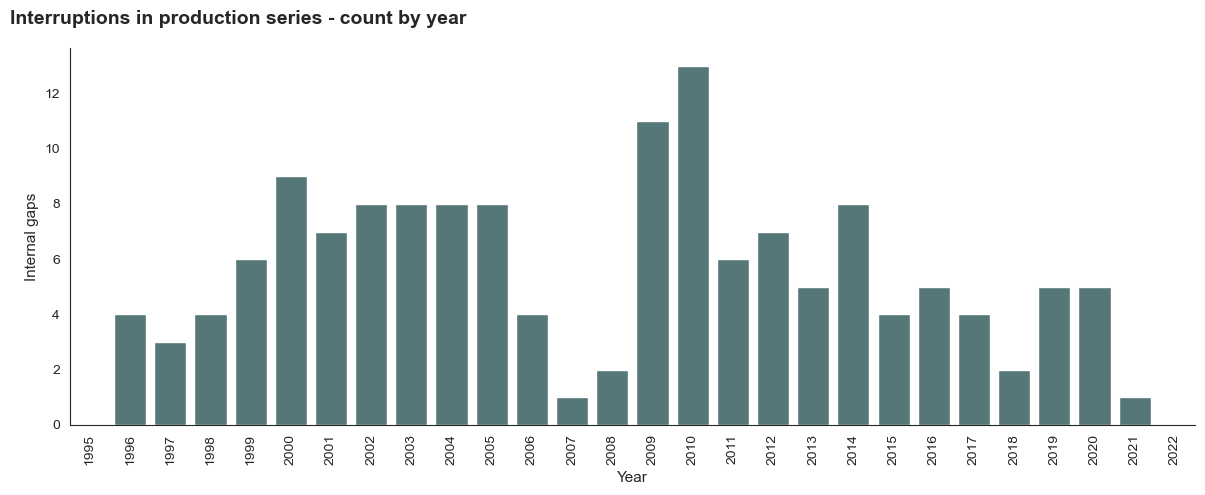

In [30]:
# Plot interruptions in chronological order rather than sorting years
# by frequency.

set_plot_style()

fig, ax = plt.subplots(
    figsize=(12, 5)
)

sns.barplot(
    data=interruptions_by_year,
    x="year",
    y="interruptions",
    color=TEAL,
    ax=ax
)

ax.set_xlabel("Year")
ax.set_ylabel("Internal gaps")
ax.tick_params(
    axis="x",
    rotation=90
)

plt.suptitle("Interruptions in production series - count by year", fontsize=14, weight='bold', ha='left', x=0.0)

fig.tight_layout()
plt.show()

In [31]:
# List the provinces affected by an internal gap for each year and crop.
# Keeping crop_name in the grouping avoids losing the crop dimension
# that distinguishes this dataset from a simple province-year table.
interruptions_by_year_crop = (
    interruption_grid
    .groupby(
        ["year", "crop_name"],
        as_index=False
    )
    .agg(
        province_count=("province", "nunique"),
        provinces=(
            "province",
            lambda values: sorted(
                values.unique()
            )
        )
    )
    .sort_values(
        ["year", "crop_name"]
    )
    .reset_index(drop=True)
)

display(interruptions_by_year_crop)

,year,crop_name,province_count,provinces
0,1996,Durum wheat,3,"[Brescia, Gorizia, Vercelli]"
1,1996,Grain maize,1,[Lecco]
2,1997,Durum wheat,2,"[Brescia, Vercelli]"
3,1997,Soft wheat,1,[Novara]
4,1998,Durum wheat,3,"[Brescia, Como, Vercelli]"
5,1998,Grain maize,1,[Oristano]
6,1999,Durum wheat,4,"[Milano, Monza e della Brianza, Venezia, Verce..."
7,1999,Soft wheat,2,"[Lecco, Matera]"
8,2000,Durum wheat,6,"[Como, Milano, Monza e della Brianza, Pordenon..."
9,2000,Soft wheat,3,"[Bari, Barletta-Andria-Trani, Matera]"


The distribution of internal interruptions is uneven across both crops and provinces. Durum wheat accounts for 81 of the 148 interruptions, followed by soft wheat with 53, while grain maize contributes only 14. The issue is therefore more relevant for the two wheat series, although all three crops are affected in some years.

A limited group of provinces contains a substantial share of the gaps. Como has the highest number, with 19 interruptions, followed by Vercelli with 11, Monza e della Brianza with 10, Oristano with nine and Pordenone with eight. Together, these five provinces account for 57 interruptions, approximately 39% of the total. The province-year-crop listing also shows that several cases are not isolated missing observations but sequences affecting the same crop and province over consecutive years. Examples include the durum wheat series for Como and recurring soft wheat gaps in several Sardinian provinces.

The interruptions occur throughout most of the observation period rather than being attributable to a single missing year in the source. The largest annual counts are observed in 2010, with 13 interruptions affecting 11 provinces and all three crops, and in 2009, with 11 interruptions. Other smaller concentrations occur around 2000–2005 and in 2014. No internal gaps are identified in 1995 or 2022 because absent observations outside the first and last available year of a series are classified separately as `before first year` or `after last year`.

Overall, the results point to a combination of isolated gaps and longer discontinuities specific to particular province-crop series, rather than to a uniform loss of observations across the whole dataset. These cases should therefore be considered at series level when preparing the modelling data. In particular, the longer discontinuities may limit the construction of lagged variables and the estimation of temporal dependence, while isolated interruptions may be handled differently depending on their position and on the modelling strategy adopted.

### Territorial coverage

The production table includes a quality indicator describing the share of the expected territorial area represented in each observation. The following sensitivity table shows how many observations and how much agricultural area and production would remain under different minimum coverage thresholds.

In [32]:
# Candidate coverage thresholds are inspected without selecting one yet.
COVERAGE_THRESHOLDS = [
    1.00,
    0.95,
    0.90,
    0.75,
    0.50,
    0.00
]

In [33]:
coverage_rows = []

for threshold in COVERAGE_THRESHOLDS:

    retained = production_df[
        production_df["q_area_coverage"]
        >= threshold
    ]

    coverage_rows.append(
        {
            "threshold": threshold,
            "observations": len(retained),
            "observations_share": (
                len(retained)
                / len(production_df)
            ),
            "area_share": (
                retained["area"].sum()
                / production_df["area"].sum()
            ),
            "production_share": (
                retained["production"].sum()
                / production_df["production"].sum()
            )
        }
    )

display(
    pd.DataFrame(coverage_rows)
)

,threshold,observations,observations_share,area_share,production_share
0,1.00,7531,0.994060,0.999753,0.999907
1,0.95,7531,0.994060,0.999753,0.999907
2,0.90,7531,0.994060,0.999753,0.999907
3,0.75,7539,0.995116,0.999838,0.999934
4,0.50,7551,0.996700,0.999848,0.999950
5,0.00,7576,1.000000,1.000000,1.000000


A requirement of complete territorial coverage retains 7,531 of 7,576 observations, or **99.4%** of the table, while preserving more than **99.97% of cultivated area** and **99.99% of production**. The incomplete observations are therefore few and small in agricultural weight.

The table supports the use of complete observations as a conservative modelling base, but the final threshold is intentionally left open until the geographical distribution of the excluded records and the needs of the model are considered.

### Consecutive-year pairs

Several later steps compare an observation with the same province-crop series one year earlier: a lagged value, a relative change, a difference against the preceding harvest. Two properties of the table decide whether such a comparison describes two harvests, and both are established here rather than inside the analyses that rely on them.

The first is repetition. Where the reported area and yield of a year are identical to those of the year before, the row does not record a movement between the two harvests.

The second is territorial coverage. Where the share of the expected territory represented in an observation moves between two consecutive years, the two rows do not describe the same territory, and the difference between their areas measures the reported perimeter rather than the cultivated land.

In [34]:
# Pair every observation with the preceding year of the same province-crop
# series and check the two conditions a year-over-year difference rests on.
change_ordered = (
    production_df
    .sort_values(
        ["province", "crop_name", "year"]
    )
    .copy()
)

previous_values = (
    change_ordered
    .groupby(
        ["province", "crop_name"]
    )[
        [
            "year",
            "area",
            "yield",
            "q_area_coverage"
        ]
    ]
    .shift()
    .add_prefix("previous_")
)

change_ordered = pd.concat(
    [
        change_ordered,
        previous_values
    ],
    axis=1
)

consecutive_pairs = (
    change_ordered.loc[
        change_ordered["year"]
        - change_ordered["previous_year"]
        == 1
    ]
    .copy()
)

repeated_area = (
    consecutive_pairs["area"]
    == consecutive_pairs["previous_area"]
)

repeated_yield = (
    consecutive_pairs["yield"]
    == consecutive_pairs["previous_yield"]
)

coverage_moved = (
    consecutive_pairs["q_area_coverage"]
    != consecutive_pairs["previous_q_area_coverage"]
)

# The pairs crossing a change of coverage are kept aside rather than dropped:
# the two years do not describe the same territory.
coverage_break_pairs = (
    consecutive_pairs[coverage_moved]
    .copy()
)

comparable_pairs = (
    consecutive_pairs[~coverage_moved]
    .copy()
)

print(
    "Consecutive-year pairs:",
    len(consecutive_pairs),
    "| repeating the reported area:",
    int(repeated_area.sum()),
    "| repeating area and yield:",
    int(
        (
            repeated_area
            & repeated_yield
        )
        .sum()
    )
)

print(
    "Pairs crossing a change of coverage:",
    len(coverage_break_pairs),
    "| series:",
    coverage_break_pairs
    .groupby(
        ["province", "crop_name"]
    )
    .ngroups,
    "| provinces:",
    ", ".join(
        sorted(
            coverage_break_pairs["province"].unique()
        )
    )
)

Consecutive-year pairs: 7226 | repeating the reported area: 980 | repeating area and yield: 430
Pairs crossing a change of coverage: 19 | series: 9 | provinces: Area vasta Sud Sardegna, Nuoro, Sassari


Of the 7,226 consecutive-year pairs in the dataset, 980 report an area identical to the previous year, and in 430 of these the yield is identical as well. Since yield is production over area, those 430 rows reproduce all three production quantities of the preceding year exactly. **They repeat the previous year rather than recording a movement**, and a repeated row raises the measured dependence of a series on its own first lag without any harvest having behaved that way.

Nineteen pairs cross a change of reported territorial coverage. They belong to nine series in three provinces, Area vasta Sud Sardegna, Nuoro and Sassari, in which area and production are not reported over the same perimeter in the two years. These pairs are retained in `coverage_break_pairs` rather than dropped, and the pairs available for a year-over-year comparison are held in `comparable_pairs`.

### Climate data - univariate analysis

The descriptive statistics pool 58,512 province-month observations. Each marginal distribution combines two sources of variation: the annual seasonal cycle and geographical differences between production areas. A multimodal or highly dispersed national distribution may therefore reflect the mixture of months and territories rather than an anomaly.

At this stage the purpose is to inspect support, cardinality, zero concentration, skewness and possible ceiling effects. All variables are profiled in tabular form, while graphs are restricted to a representative subset.

In [35]:
# Descriptive statistics for all monthly climate variables.
pd.set_option("display.max_rows", None)
display(
    climate_df[CLIMATE_COLUMNS]
    .describe(include="all")
    .T
)
pd.reset_option("display.max_rows")

,count,mean,std,min,25%,50%,75%,max
TEMPERATURE_AVG_MONTH,58512.0,13.713433,7.075590,-8.558634,8.194055,13.332396,19.786838,29.009302
TEMPERATURE_MAX_MONTH,58512.0,26.962473,7.448628,8.500000,20.700000,26.800000,33.200000,50.100000
TEMPERATURE_MIN_MONTH,58512.0,-0.337374,7.959925,-36.600000,-5.600000,-0.400000,5.900000,19.400000
PRECIPITATION_DAILY_AVG,58512.0,2.091006,1.778572,0.000000,0.828205,1.674546,2.857686,22.566667
PRECIPITATION_LOCAL_DAILY_MAX,58512.0,33.355278,26.009550,0.000000,16.000000,27.000000,43.000000,309.000000
WINDSPEED_AVG_MONTH,58512.0,2.545378,0.964750,0.220222,1.844541,2.404432,3.156296,9.245674
WINDSPEED_LOCAL_MAX,58512.0,8.902584,3.708981,1.200000,6.200000,8.300000,10.900000,33.200000
VAPOURPRESSURE_AVG_MONTH,58512.0,12.439507,4.860364,2.292157,8.407971,11.770770,16.361075,28.018755
ET0_DAILY_AVG,58512.0,2.704101,1.641751,0.188387,1.243671,2.461306,4.057924,7.434327
RADIATION_DAILY_AVG,58512.0,14959.739761,7352.516221,2467.922379,7994.667248,14778.700941,21705.419039,32191.586111


**Relationships imposed by construction**

Some variables describe the same information in different forms.

- Monthly totals are obtained from daily averages and the number of observed days. Both forms can be useful, but they should not enter a model as competing predictors. Daily averages are easier to compare across months, while totals are the appropriate form for seasonal accumulation.
- `WET_DAYS_AREA_MEAN` and `DRY_DAYS_AREA_MEAN` are complementary and sum to `OBSERVED_DAYS`.
- Event indicators defined at different spatial or severity thresholds are nested. Their redundancy is expected and will be quantified after seasonal features are constructed.

These relationships indicate where a later feature set should choose a representation according to its analytical meaning.

In [36]:
# Profile every climate variable without producing one graph for each
# of the 64 monthly indicators.
variable_profile = pd.DataFrame(
    {
        "dtype": (
            climate_df[CLIMATE_COLUMNS]
            .dtypes
            .astype(str)
        ),
        "unique_values": (
            climate_df[CLIMATE_COLUMNS]
            .nunique()
        ),
        "zero_share": (
            climate_df[CLIMATE_COLUMNS]
            .eq(0)
            .mean()
        ),
        "modal_share": (
            climate_df[CLIMATE_COLUMNS]
            .apply(
                lambda column:
                column.value_counts(
                    normalize=True
                ).iloc[0]
            )
        ),
        "skewness": (
            climate_df[CLIMATE_COLUMNS]
            .skew()
        )
    }
)

In [37]:
# Flag variables whose distribution may require additional attention:
# a majority of zeros, a dominant modal value or strong asymmetry.
variable_profile["flagged"] = (
    (
        variable_profile["zero_share"]
        >= 0.50
    )
    |
    (
        variable_profile["modal_share"]
        >= 0.90
    )
    |
    (
        variable_profile["skewness"]
        .abs()
        >= 3
    )
)

In [38]:
print("Number of variables requiring particular attention:",variable_profile[variable_profile["flagged"]].shape[0])

Number of variables requiring particular attention: 14


In [39]:
display(
    variable_profile[variable_profile["flagged"]].sort_values("zero_share", ascending = False)
)

,dtype,unique_values,zero_share,modal_share,skewness,flagged
DAYS_RAIN_50,int64,9,0.882845,0.882845,4.412750,True
DAYS_HOT_35_10PCT,int64,30,0.859841,0.859841,4.784547,True
MAX_CONSECUTIVE_HOT_35_10PCT_DAYS,int64,25,0.859841,0.859841,5.011274,True
DAYS_HOT_35_ANY_AREA,int64,31,0.823540,0.823540,4.065080,True
RAIN_50_AREA_FRACTION_MAX,float64,1283,0.816192,0.816192,3.966163,True
DAYS_VERY_EXTREME_RAIN,int64,9,0.760306,0.760306,2.622204,True
MAX_CONSECUTIVE_VERY_EXTREME_RAIN_DAYS,int64,5,0.760306,0.760306,1.867733,True
MAX_CONSECUTIVE_HOT_30_10PCT_DAYS,int64,32,0.648995,0.648995,2.501354,True
DAYS_HOT_30_10PCT,int64,32,0.648995,0.648995,1.785679,True
VERY_EXTREME_RAIN_AREA_FRACTION_MAX,float64,1792,0.643167,0.643167,2.489148,True


The profile provides coverage for every climate column without requiring dozens of repetitive graphs. The visual analysis below is limited to indicators representing ordinary temperature, precipitation, atmospheric demand, radiation, wind and the frequency, persistence or spatial extent of extreme events.

In [40]:
# Representative variables selected across the main climate families.
CLIMATE_PLOT_SELECTION = [
    "TEMPERATURE_AVG_MONTH",
    "TEMPERATURE_MIN_MONTH",
    "TEMPERATURE_MAX_MONTH",
    "TEMPERATURE_SPATIAL_STD_AVG",
    "PRECIPITATION_TOTAL_MONTH",
    "PRECIPITATION_LOCAL_DAILY_MAX",
    "WET_DAYS_AREA_MEAN",
    "MAX_CONSECUTIVE_DRY_DAYS_AREA_MEAN",
    "ET0_TOTAL_MONTH",
    "RADIATION_TOTAL_MONTH",
    "VAPOURPRESSURE_AVG_MONTH",
    "WINDSPEED_AVG_MONTH",
    "DAYS_HOT_30_10PCT",
    "DAYS_FROST_10PCT",
    "DAYS_EXTREME_RAIN",
    "EXTREME_HEAT_AREA_FRACTION_AVG",
    "EXTREME_RAIN_AREA_FRACTION_AVG"
]

'TEMPERATURE_AVG_MONTH': 0 missing (0.0%)
Skew: -0.059


,count,mean,std,min,25%,50%,75%,max
TEMPERATURE_AVG_MONTH,58512.0,13.713433,7.07559,-8.558634,8.194055,13.332396,19.786838,29.009302


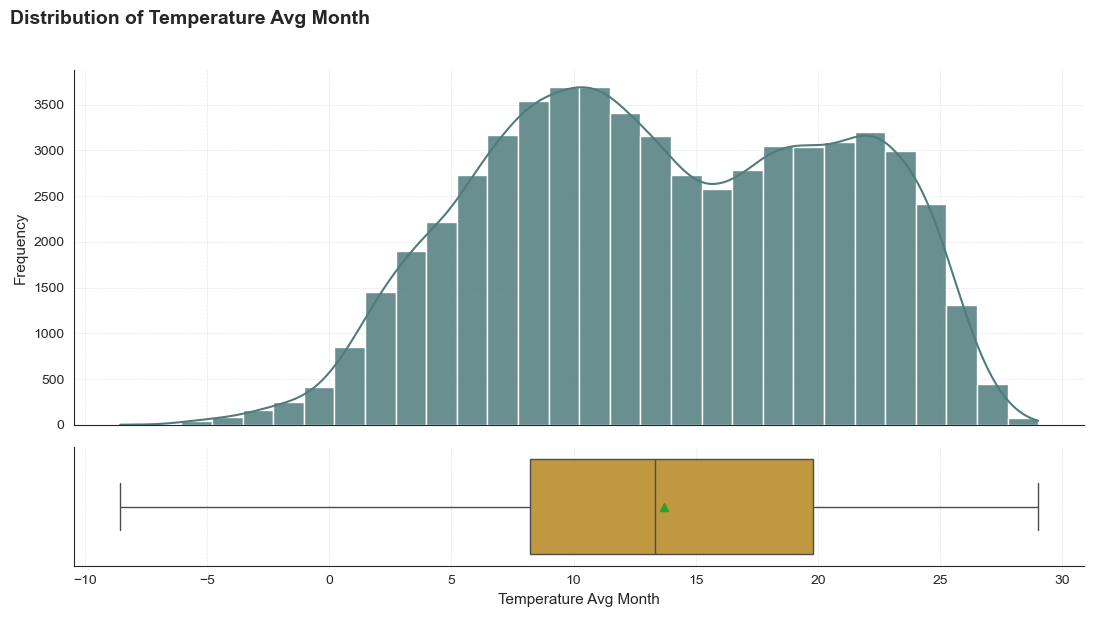

'TEMPERATURE_MIN_MONTH': 0 missing (0.0%), 296 zeros (0.5%)
Skew: -0.330


,count,mean,std,min,25%,50%,75%,max
TEMPERATURE_MIN_MONTH,58512.0,-0.337374,7.959925,-36.6,-5.6,-0.4,5.9,19.4


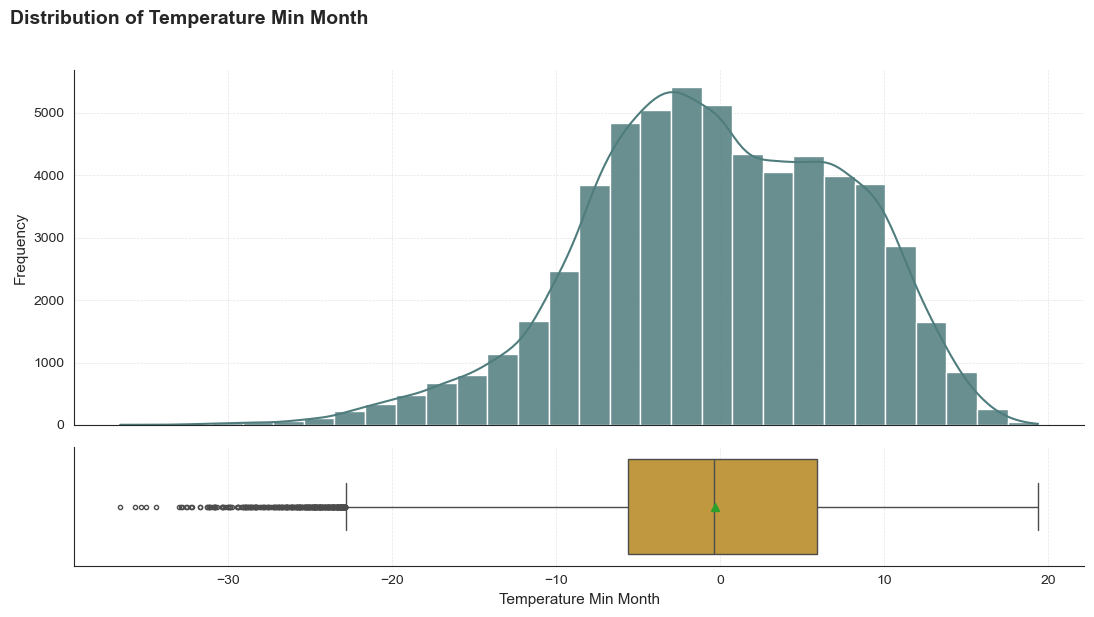

'TEMPERATURE_MAX_MONTH': 0 missing (0.0%)
Skew: 0.029


,count,mean,std,min,25%,50%,75%,max
TEMPERATURE_MAX_MONTH,58512.0,26.962473,7.448628,8.5,20.7,26.8,33.2,50.1


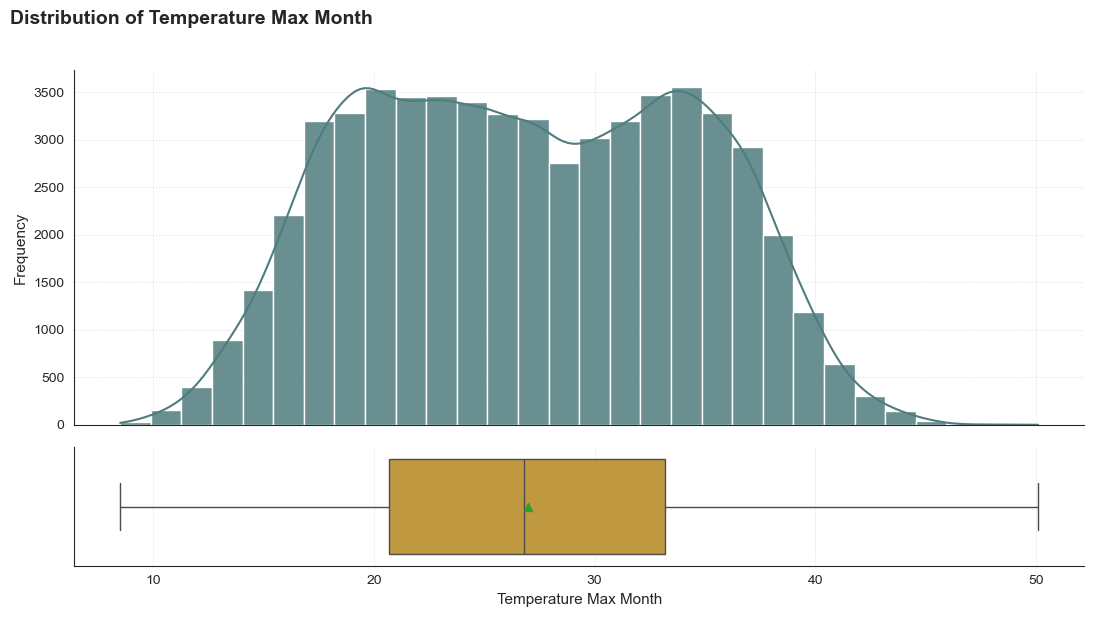

'TEMPERATURE_SPATIAL_STD_AVG': 0 missing (0.0%)
Skew: 1.243


,count,mean,std,min,25%,50%,75%,max
TEMPERATURE_SPATIAL_STD_AVG,58512.0,1.698439,0.939492,0.141508,1.060677,1.507697,2.094745,5.869416


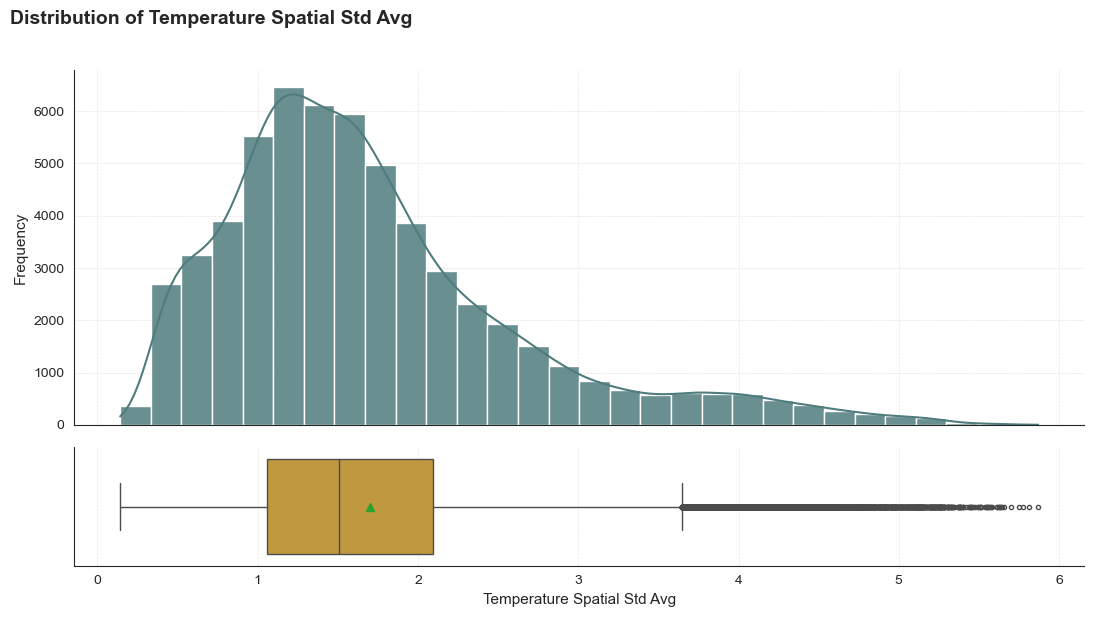

'PRECIPITATION_TOTAL_MONTH': 0 missing (0.0%), 161 zeros (0.3%)
Skew: 1.967


,count,mean,std,min,25%,50%,75%,max
PRECIPITATION_TOTAL_MONTH,58512.0,63.607624,54.097269,0.0,25.178478,50.902492,86.871976,677.0


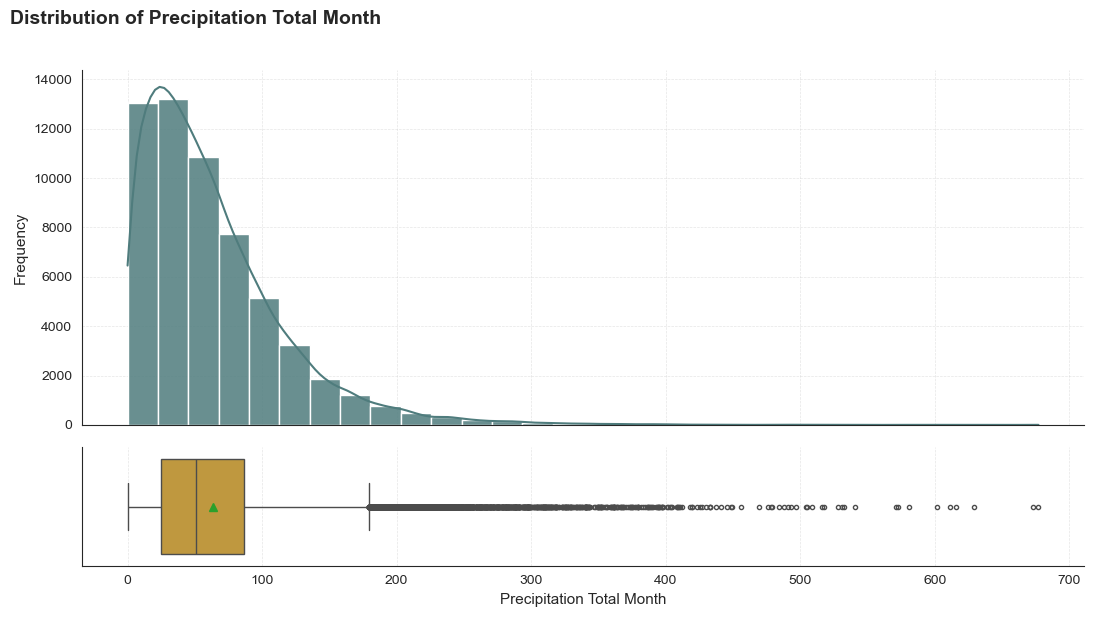

'PRECIPITATION_LOCAL_DAILY_MAX': 0 missing (0.0%), 161 zeros (0.3%)
Skew: 2.267


,count,mean,std,min,25%,50%,75%,max
PRECIPITATION_LOCAL_DAILY_MAX,58512.0,33.355278,26.00955,0.0,16.0,27.0,43.0,309.0


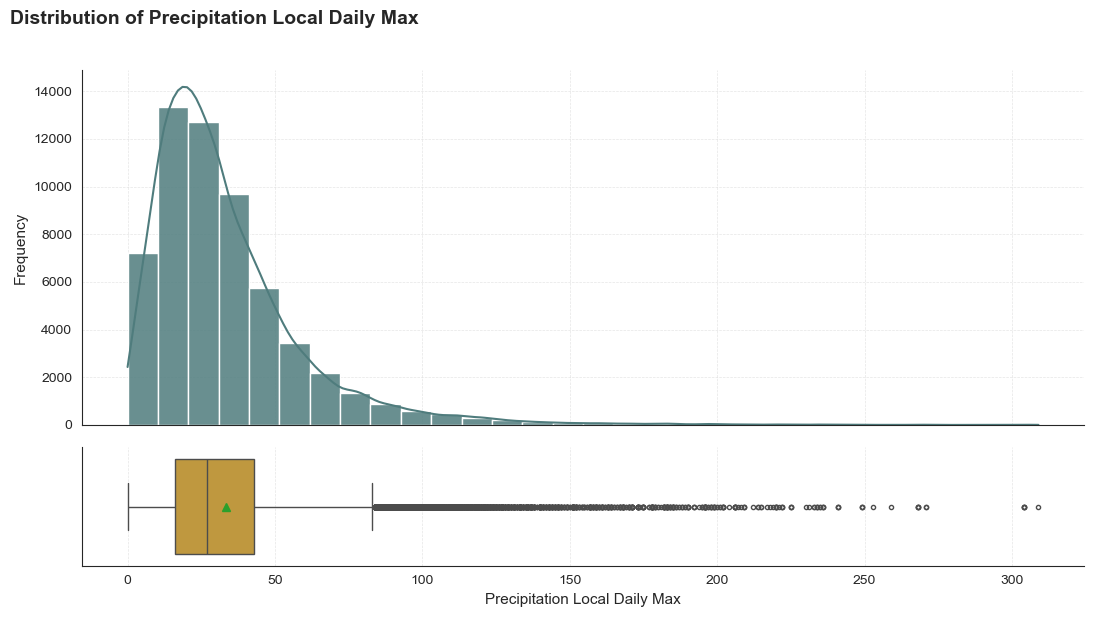

'WET_DAYS_AREA_MEAN': 0 missing (0.0%), 1354 zeros (2.3%)
Skew: 0.403


,count,mean,std,min,25%,50%,75%,max
WET_DAYS_AREA_MEAN,58512.0,8.893372,4.909643,0.0,5.0,9.0,12.0,31.0


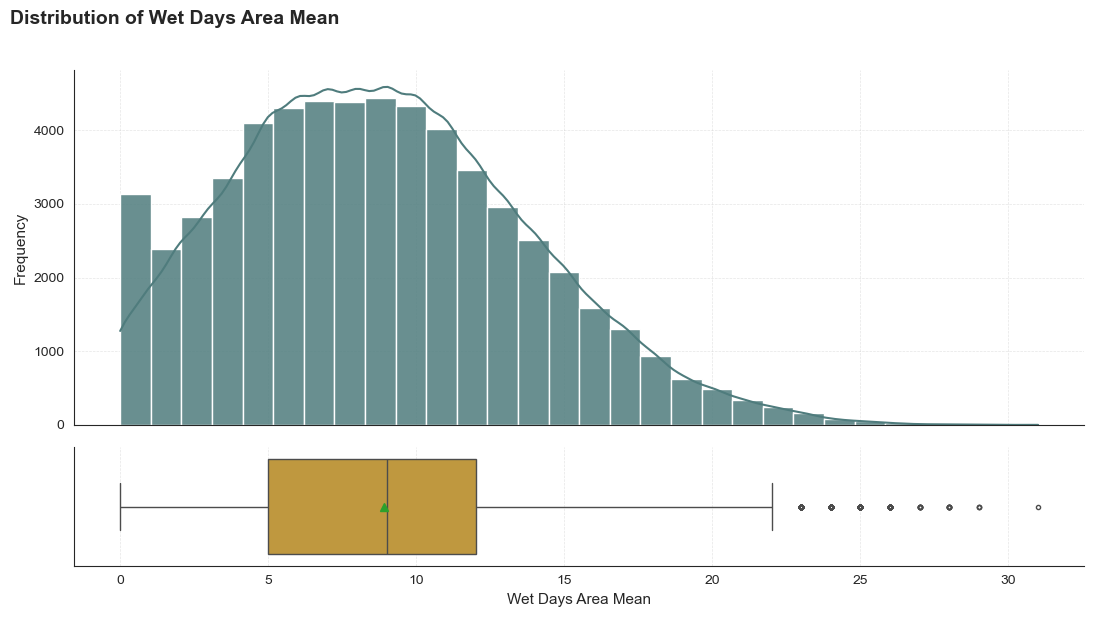

'MAX_CONSECUTIVE_DRY_DAYS_AREA_MEAN': 0 missing (0.0%), 1 zeros (0.0%)
Skew: 1.148


,count,mean,std,min,25%,50%,75%,max
MAX_CONSECUTIVE_DRY_DAYS_AREA_MEAN,58512.0,11.51169,6.203667,0.0,7.0,10.0,15.0,31.0


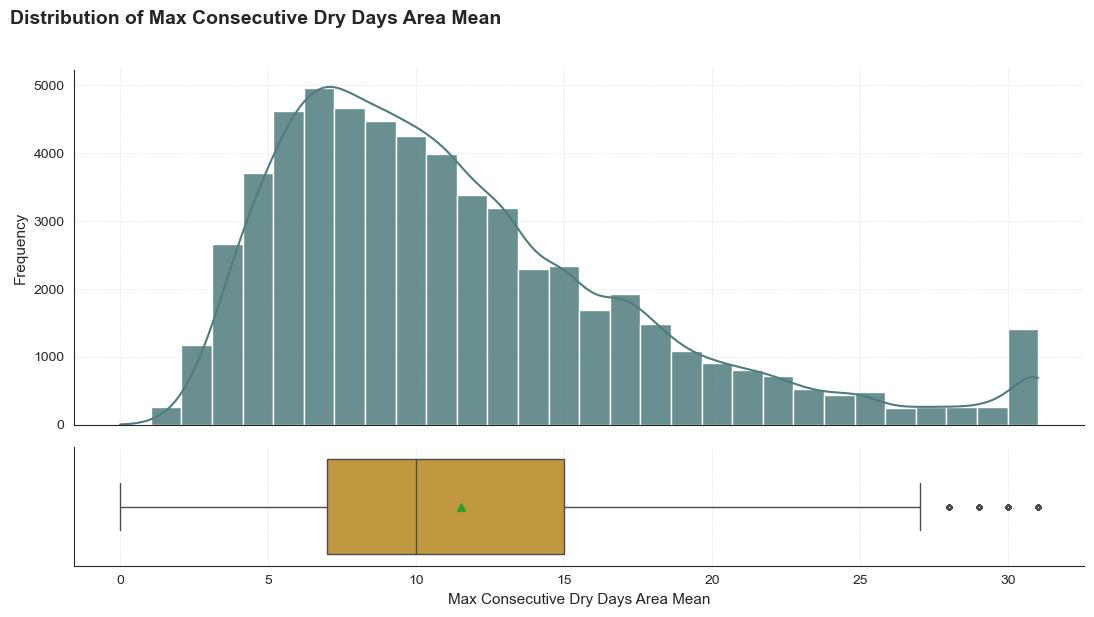

'ET0_TOTAL_MONTH': 0 missing (0.0%)
Skew: 0.426


,count,mean,std,min,25%,50%,75%,max
ET0_TOTAL_MONTH,58512.0,82.547046,50.580959,5.84,37.313043,74.829825,124.505689,230.464151


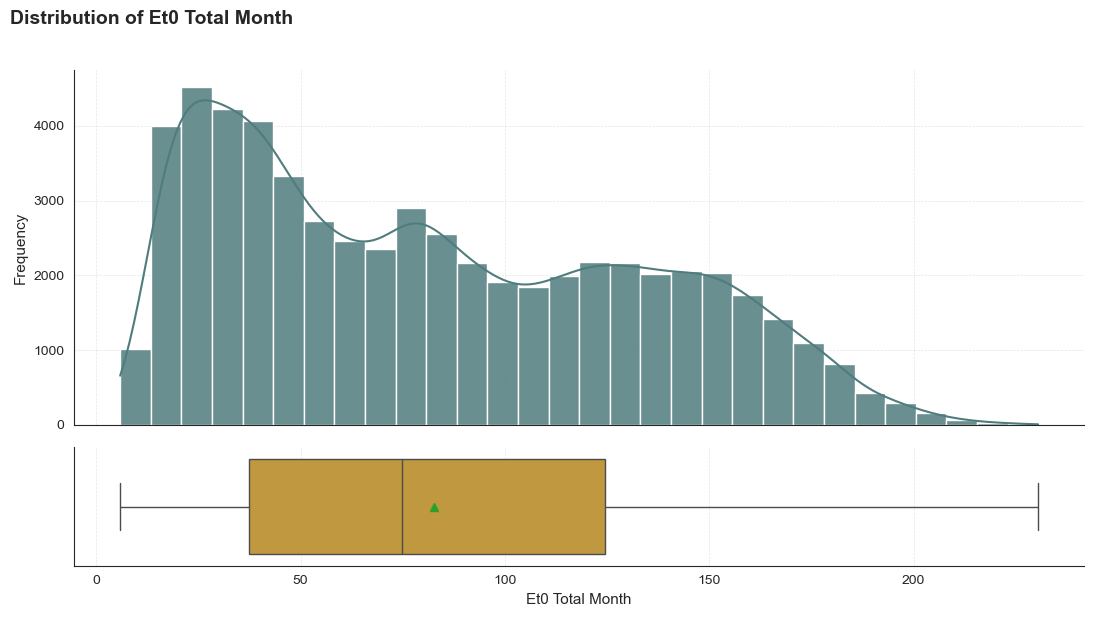

'RADIATION_TOTAL_MONTH': 0 missing (0.0%)
Skew: 0.122


,count,mean,std,min,25%,50%,75%,max
RADIATION_TOTAL_MONTH,58512.0,456181.031278,226551.960895,76505.59375,237072.491953,450887.090705,668173.133571,987516.375


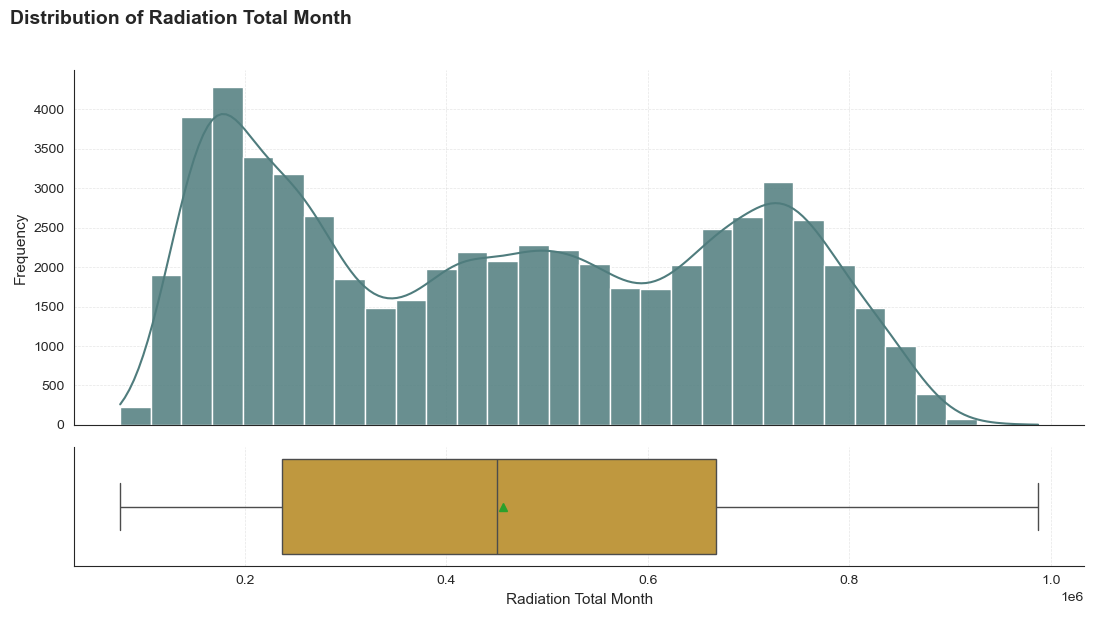

'VAPOURPRESSURE_AVG_MONTH': 0 missing (0.0%)
Skew: 0.310


,count,mean,std,min,25%,50%,75%,max
VAPOURPRESSURE_AVG_MONTH,58512.0,12.439507,4.860364,2.292157,8.407971,11.77077,16.361075,28.018755


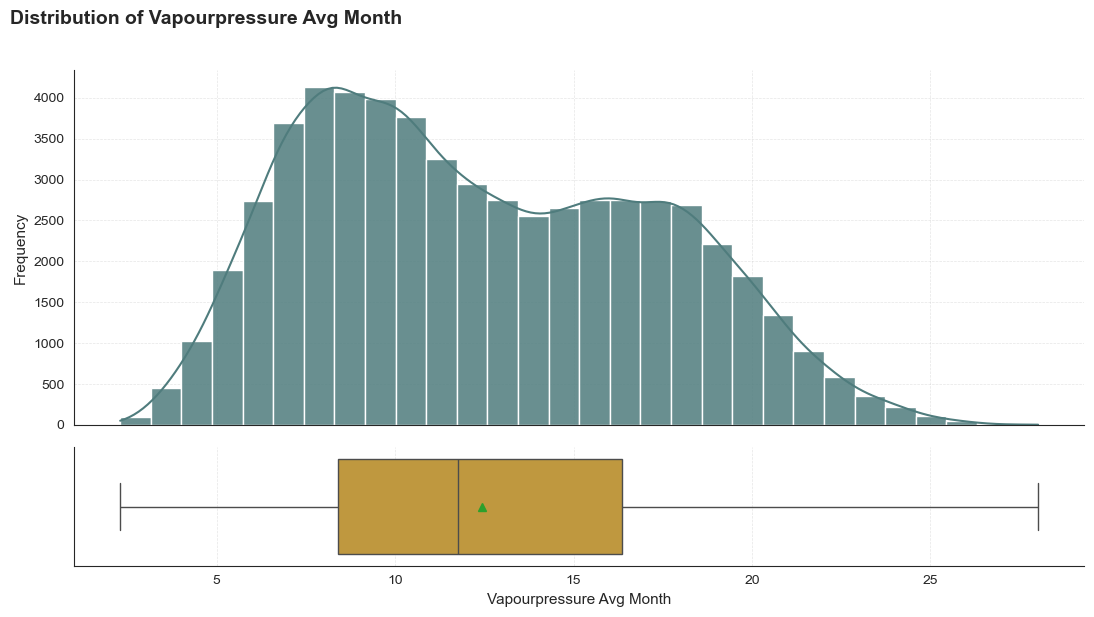

'WINDSPEED_AVG_MONTH': 0 missing (0.0%)
Skew: 0.658


,count,mean,std,min,25%,50%,75%,max
WINDSPEED_AVG_MONTH,58512.0,2.545378,0.96475,0.220222,1.844541,2.404432,3.156296,9.245674


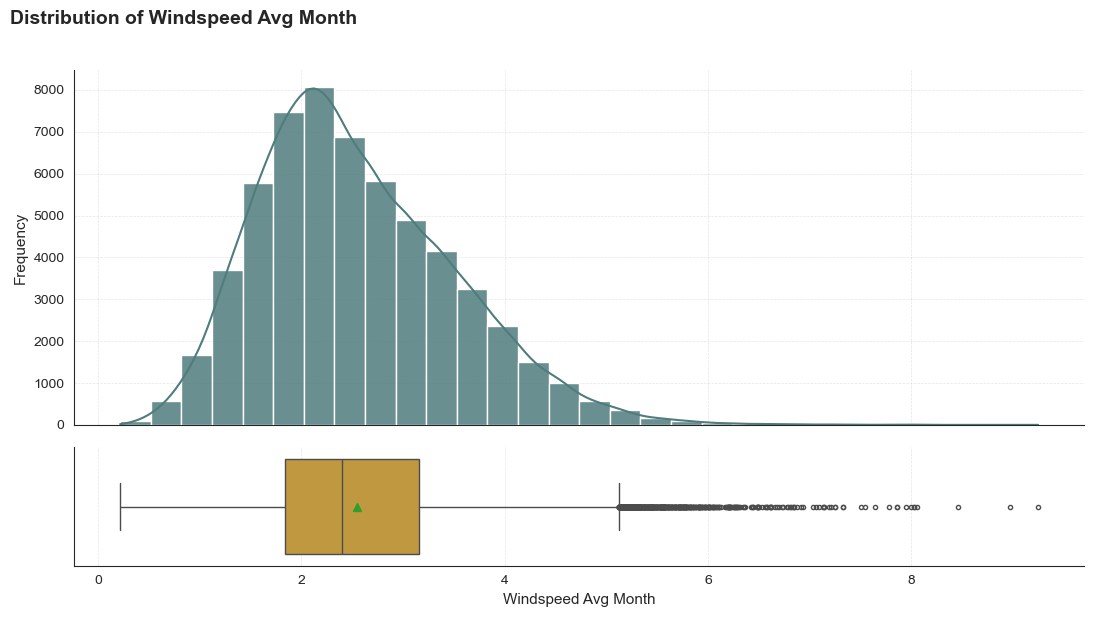

'DAYS_HOT_30_10PCT': 0 missing (0.0%), 37974 zeros (64.9%)
Skew: 1.786


,count,mean,std,min,25%,50%,75%,max
DAYS_HOT_30_10PCT,58512.0,4.618711,8.409849,0.0,0.0,0.0,5.0,31.0


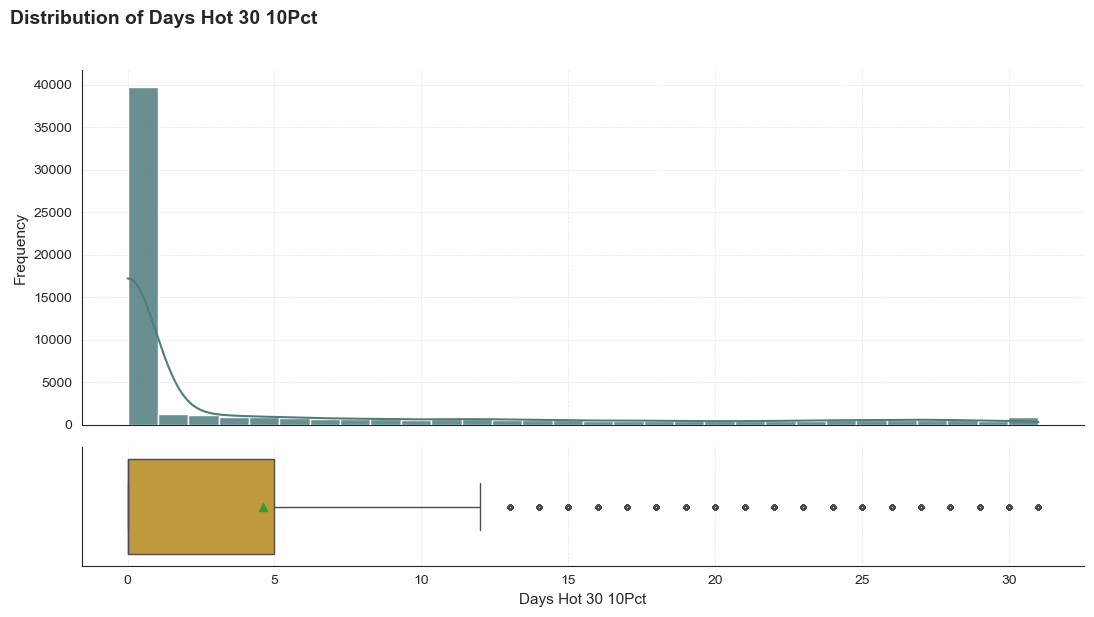

'DAYS_FROST_10PCT': 0 missing (0.0%), 32777 zeros (56.0%)
Skew: 1.445


,count,mean,std,min,25%,50%,75%,max
DAYS_FROST_10PCT,58512.0,6.049084,9.533724,0.0,0.0,0.0,10.0,31.0


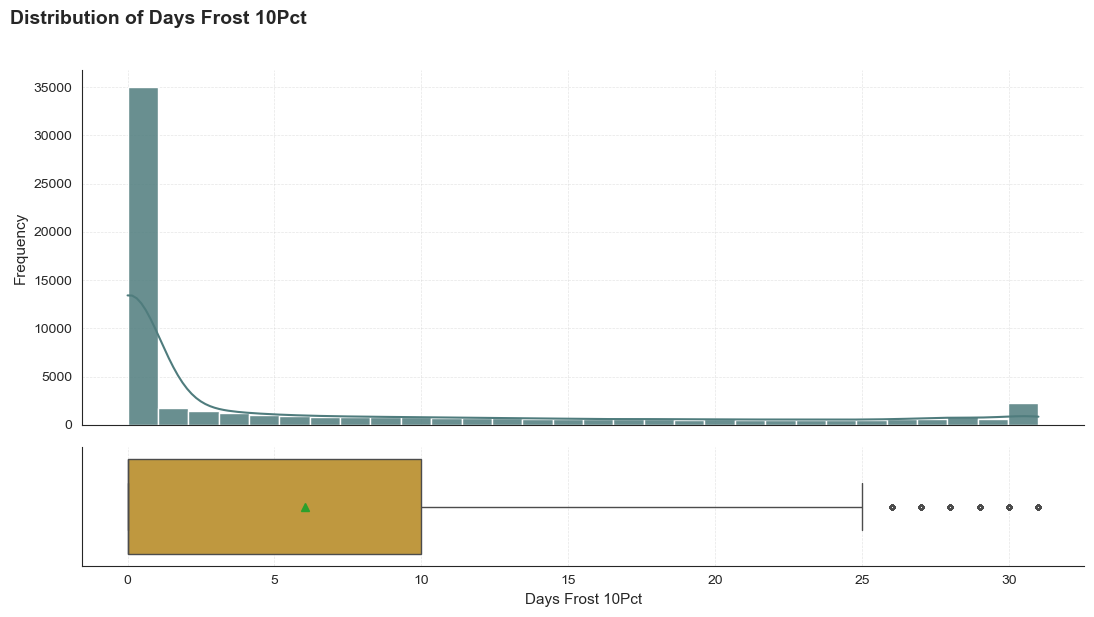

'DAYS_EXTREME_RAIN': 0 missing (0.0%), 24626 zeros (42.1%)


,Days Extreme Rain,abs_freq,rel_freq_%
0,0,24626,42.09
1,1,15938,27.24
2,2,9257,15.82
3,3,4696,8.03
4,4,2230,3.81
5,5,1024,1.75
6,6,436,0.75
7,7,178,0.30
8,8,86,0.15
9,9,28,0.05


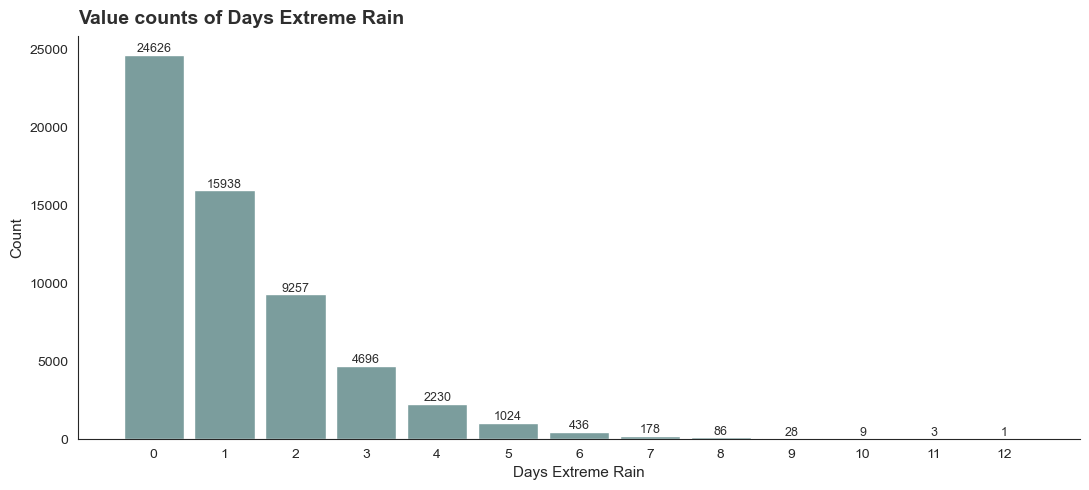

'EXTREME_HEAT_AREA_FRACTION_AVG': 0 missing (0.0%), 2971 zeros (5.1%)
Skew: 1.355


,count,mean,std,min,25%,50%,75%,max
EXTREME_HEAT_AREA_FRACTION_AVG,58512.0,0.127476,0.113867,0.0,0.040428,0.099798,0.182796,0.790323


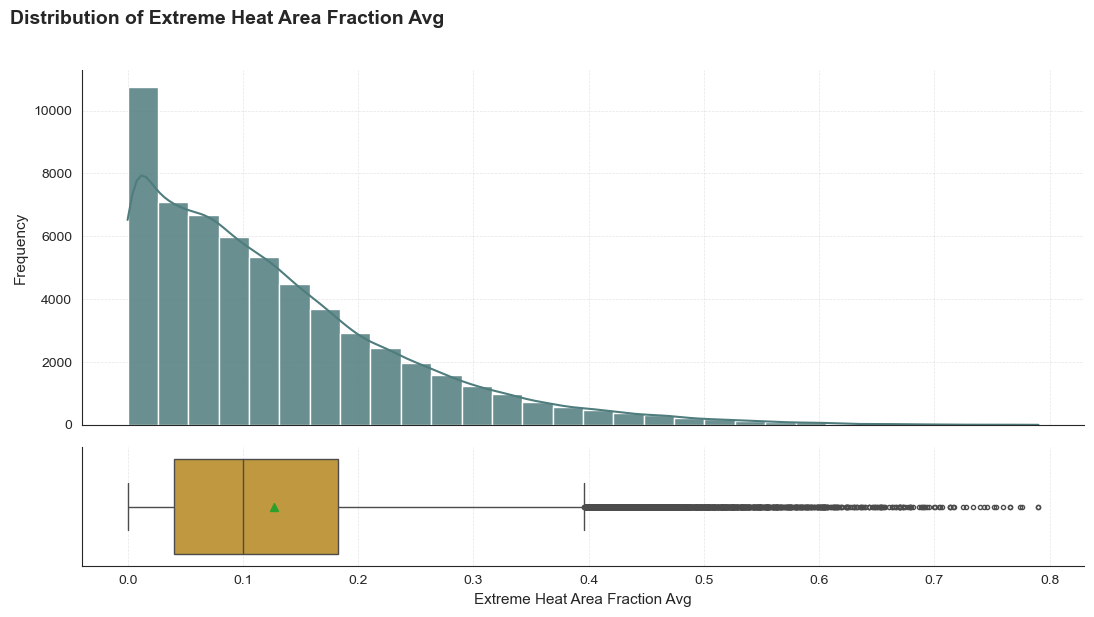

'EXTREME_RAIN_AREA_FRACTION_AVG': 0 missing (0.0%), 18160 zeros (31.0%)
Skew: 1.966


,count,mean,std,min,25%,50%,75%,max
EXTREME_RAIN_AREA_FRACTION_AVG,58512.0,0.018192,0.024115,0.0,0.0,0.008065,0.029412,0.232975


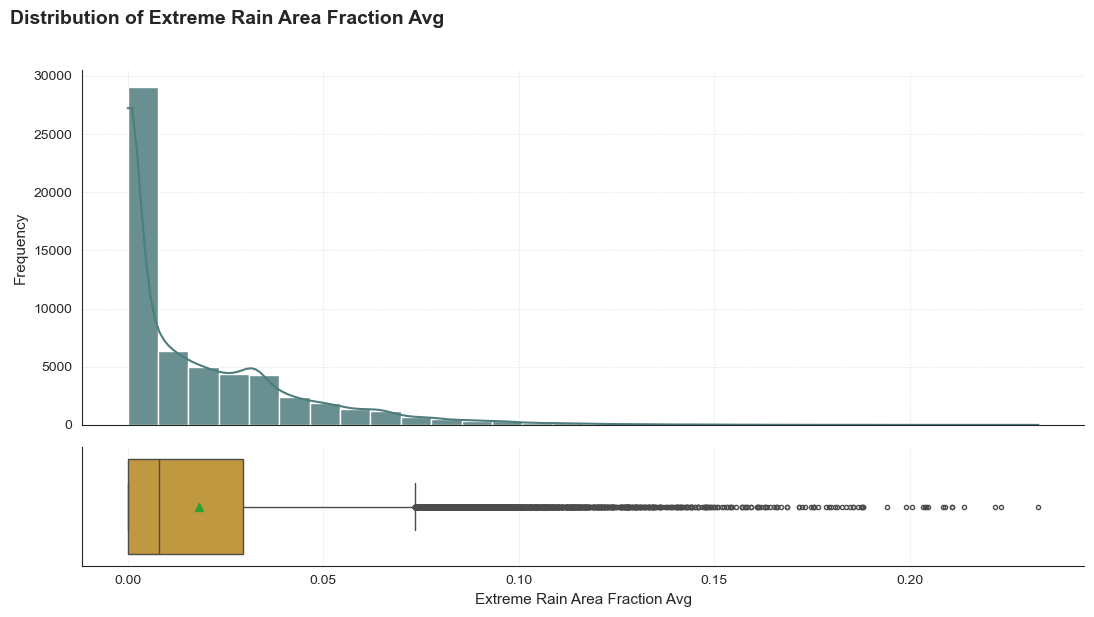

In [41]:
for column in CLIMATE_PLOT_SELECTION:
    kind = infer_variable_type(
        climate_df[column]
    )

    # Log scaling is disabled because zero is meaningful for many
    # event indicators. Numeric variables with few possible values
    # are displayed as discrete rather than continuous distributions.
    if (
        kind == "continuous"
        and climate_df[column].nunique() > 30
    ):
        plot_numeric_distribution(
            climate_df,
            column,
            auto_log=False
        )

    elif (
        kind == "continuous"
        and climate_df[column].nunique() > 7
    ):
        plot_categorical_distribution(
            climate_df,
            column,
            max_categories=30,
            horizontal=True
        )

    elif kind in ["continuous", "discrete"]:
        plot_discrete_distribution(
            climate_df,
            column
        )

    else:
        plot_categorical_distribution(
            climate_df,
            column
        )

**Main observations from the climate distributions**

The selected plots confirm that ordinary temperature, radiation and evapotranspiration are strongly seasonal. Their national marginal distributions mix winter and summer regimes and should not be interpreted as single homogeneous populations.

Precipitation and event-related indicators are more asymmetric. Monthly precipitation has a median of about 51 mm and a mean of about 64 mm, while a small number of province-months are completely dry. Local daily maxima have a much longer upper tail than province-wide averages, showing the information lost through spatial aggregation.

Extreme-event variables combine different dimensions of the same phenomenon:

- frequency, through the number of event days;
- spatial extent, through area fractions;
- persistence, through maximum consecutive-day indicators.

Zeros normally represent absence of the event. The rarest indicators are consequently zero-inflated and may become more informative only after aggregation over a crop phase or an agricultural season.

Duration indicators are calculated within calendar months. Events crossing a month boundary are therefore split, and values close to the length of the month should be interpreted as lower bounds for the true continuous spell.

The distributions support a selective feature-building approach: retain variables with distinct agronomic meaning, aggregate them at the appropriate temporal scale and examine redundancy only after the crop-season features have been created.

### Climate aggregation rules

The monthly climate variables will later be combined over crop-development phases. Before doing that, each variable needs an aggregation rule that preserves its meaning across several months.

The operation depends on what the monthly value represents:

- monthly averages describe a typical condition and are therefore averaged across the phase;
- monthly totals and counts of event days accumulate over time and are summed;
- monthly extremes, maximum affected-area fractions and spell lengths describe the most intense condition and are reduced to their maximum;
- minimum temperature is reduced to its minimum, so the coldest monthly value within the phase is retained.

The rules are inferred directly from the variable names, making the logic visible in the notebook rather than relying on an external configuration file. Static territorial characteristics are excluded because they do not vary from month to month and will be added separately after the climate aggregation.

For a small group of variables, more than one aggregation could be defensible. The within-month temperature standard deviation, average area fractions and area fractions conditional on event presence are provisionally averaged across the phase. This choice remains explicit so it can be reconsidered before modelling.


In [42]:
# Assign one phase-level aggregation rule to every dynamic climate variable.
# The order of the conditions matters: specific extrema and totals are matched
# before the broader patterns used for mean variables.
def phase_aggregation_rule(column):

    # Retain the coldest monthly minimum within the phase.
    if column == "TEMPERATURE_MIN_MONTH":
        return "min"

    # Retain the largest monthly extreme, affected fraction or spell length.
    if (
        column.startswith("MAX_CONSECUTIVE_")
        or column.endswith(
            (
                "_MAX_MONTH",
                "_LOCAL_DAILY_MAX",
                "_LOCAL_MAX",
                "_AREA_DAILY_MAX",
                "_FRACTION_MAX",
            )
        )
    ):
        return "max"

    # Accumulate monthly totals and event-day counts over the phase.
    if (
        column.startswith(("DAYS_", "WET_DAYS_", "DRY_DAYS_"))
        or column.endswith("_TOTAL_MONTH")
    ):
        return "sum"

    # Average variables that represent typical monthly conditions.
    if (
        column == "TEMPERATURE_DAILY_STD"
        or column.endswith(
            (
                "_AVG_MONTH",
                "_DAILY_AVG",
                "_SPATIAL_STD_AVG",
                "_FRACTION_AVG",
                "_AREA_WHEN_PRESENT",
            )
        )
    ):
        return "mean"

    # A new or renamed variable should never receive a silent default rule.
    raise ValueError(
        f"No aggregation rule defined for {column}"
    )


# Build the rule lookup used later in the feature-construction section.
phase_rules = pd.Series(
    {
        column: phase_aggregation_rule(column)
        for column in CLIMATE_COLUMNS
    },
    name="rule",
)

display(
    phase_rules
    .value_counts()
    .rename_axis("rule")
    .to_frame("columns")
)


,columns
rule,
max,23
sum,21
mean,19
min,1


In [43]:
# Isolate the variables whose mean aggregation is a methodological default
# rather than a rule implied unambiguously by the quantity itself.
provisional_mean_columns = [
    column
    for column in CLIMATE_COLUMNS
    if (
        column == "TEMPERATURE_DAILY_STD"
        or column.endswith(
            (
                "_FRACTION_AVG",
                "_AREA_WHEN_PRESENT",
            )
        )
    )
]

display(
    phase_rules.loc[provisional_mean_columns]
    .rename_axis("column")
    .to_frame()
)

print(
    "Climate variables:", len(CLIMATE_COLUMNS),
    "| provisional mean rules:", len(provisional_mean_columns),
)


,rule
column,
TEMPERATURE_DAILY_STD,mean
WET_AREA_FRACTION_AVG,mean
WET_AREA_WHEN_PRESENT,mean
EXTREME_RAIN_AREA_FRACTION_AVG,mean
EXTREME_RAIN_AREA_WHEN_PRESENT,mean
EXTREME_HEAT_AREA_FRACTION_AVG,mean
EXTREME_HEAT_AREA_WHEN_PRESENT,mean
EXTREME_COLD_AREA_FRACTION_AVG,mean
EXTREME_COLD_AREA_WHEN_PRESENT,mean


Climate variables: 64 | provisional mean rules: 11


The rule summary above shows the operations that will later be passed to the phase aggregation. At this point no climate value has changed: only the treatment of each column has been classified.

The remaining question is whether any of those rules are conventions rather than direct consequences of the variable definition. The next cell isolates those cases so they remain easy to review.


All 64 dynamic climate variables receive exactly one aggregation rule. The summary above is therefore both a description of the chosen operations and a compact check that every variable used later can be handled.

Eleven rules remain provisional rather than being uniquely determined by the quantity itself. They currently use the mean and are displayed separately so that this assumption is not hidden inside the feature-construction code.

Nothing is aggregated at this point. The notebook only prepares a `column → rule` lookup; the actual monthly-to-phase transformation is performed later in the feature-construction section after the crop calendars have been expanded.


## Production target and temporal structure

Yield is the modelling target, while cultivated area and production are examined because they determine it and help identify observations with unusual scale. The distributions are shown separately by crop where appropriate.

,count,mean,std,min,25%,50%,75%,max
crop_name,,,,,,,,
Durum wheat,2431.0,3.678060,1.356968,0.194000,2.671073,3.500000,4.611426,8.300000
Grain maize,2660.0,7.625481,2.605876,0.675676,5.868236,7.749918,9.381021,24.000000
Soft wheat,2485.0,4.182414,1.458708,0.047826,3.089888,4.067797,5.242868,8.571429


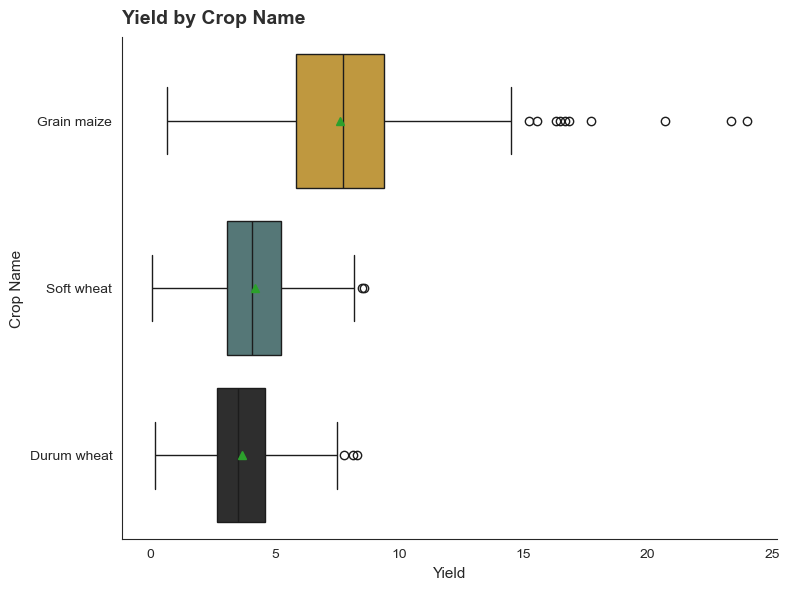

'area': 0 missing (0.0%)
Skew: 5.856


,count,mean,std,min,25%,50%,75%,max
area,7576.0,10938.421509,21070.348061,1.0,743.0075,3030.5,13000.0,279371.83


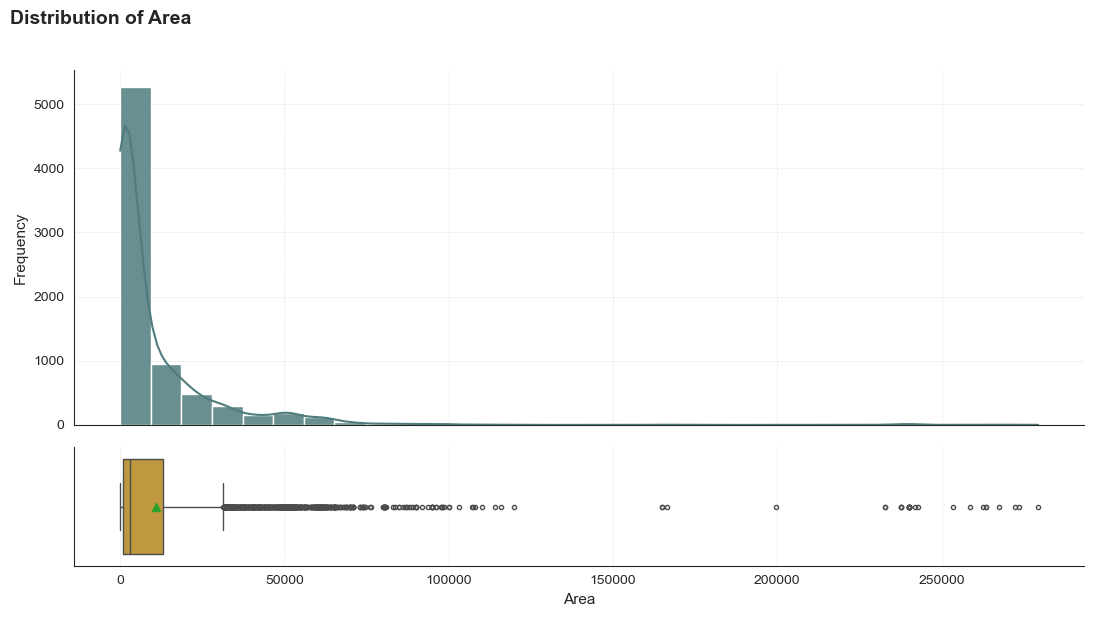

'production': 0 missing (0.0%)
Skew: 3.523


,count,mean,std,min,25%,50%,75%,max
production,7576.0,58607.798045,113213.424358,0.1,2862.25,14693.35,58095.0,1012000.0


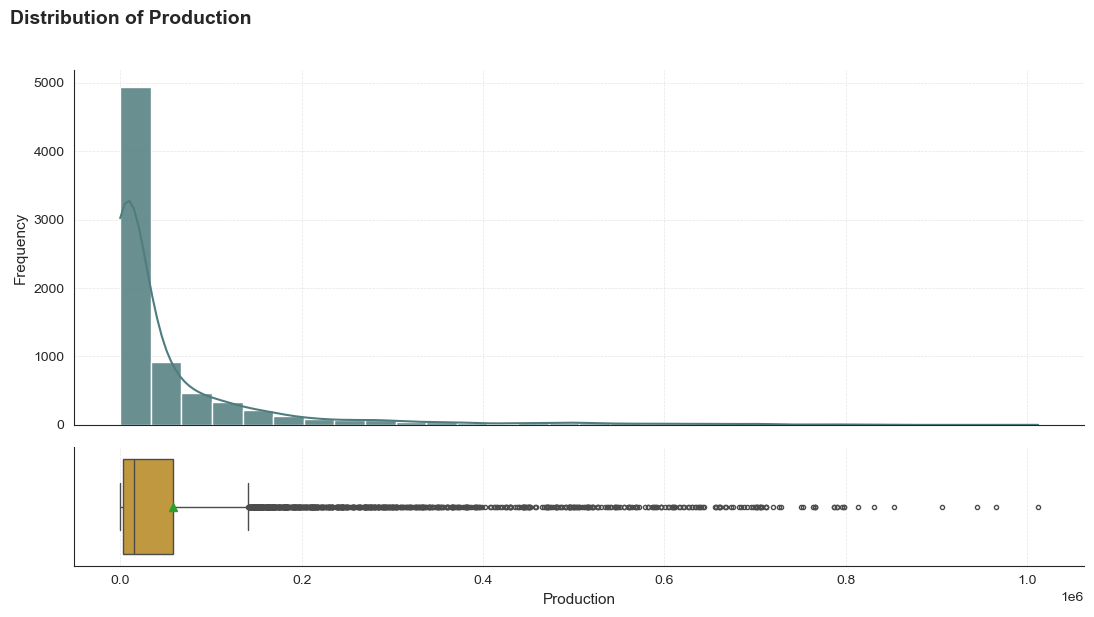

In [44]:
# Compare yield distributions across crops and inspect the scale of
# cultivated area and production.
categorical_vs_numeric(
    production_df,
    "crop_name",
    "yield",
    kind="box"
)

plot_numeric_distribution(
    production_df,
    "area",
    auto_log=False
)

plot_numeric_distribution(
    production_df,
    "production",
    auto_log=False
)

Grain maize has the highest yield and the widest distribution, while the two wheat crops have lower and more compact values.

Cultivated area and production are strongly right-skewed. A small number of province-year-crop observations have a much larger scale than the rest of the dataset. These values may describe genuinely important production areas, but they can influence unweighted summaries and should be considered when evaluating outliers.

### National evolution

The national series below is calculated as total production divided by total cultivated area for each crop and year. It is therefore an area-weighted yield, not the simple mean of provincial yields.

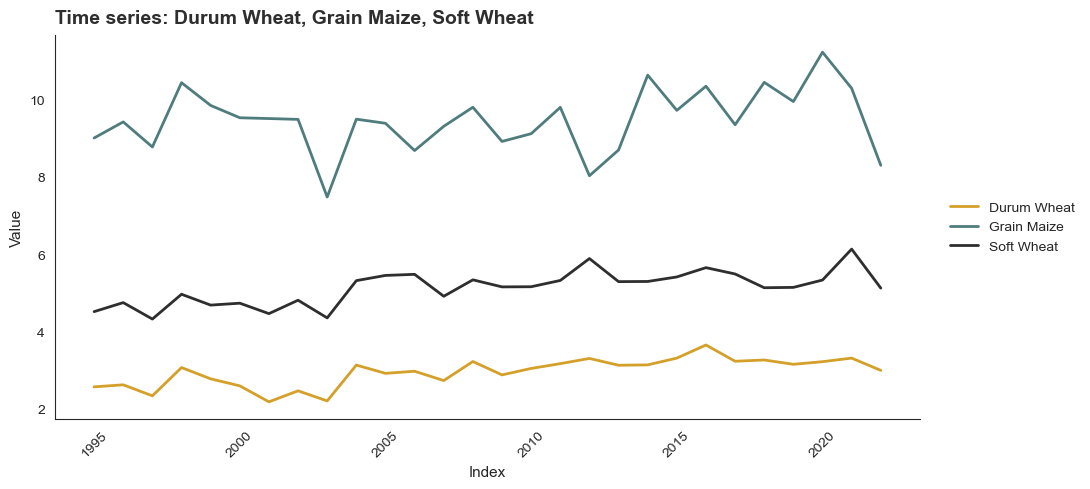

In [45]:
# Aggregate area and production before calculating national yield.
national = (
    production_df
    .groupby(
        ["year", "crop_name"]
    )[
        ["area", "production"]
    ]
    .sum()
)

national_yield = (
    national["production"]
    / national["area"]
).unstack()

plot_time_series(
    national_yield,
    columns=national_yield.columns.tolist()
)

The national series fluctuate from year to year. 
- Grain maize remains above both wheat crops and shows the largest absolute variation
- Durum and soft wheat move within narrower ranges

None of the three series seems to follow a simple common monotonic path, so a national line alone is not sufficient to describe the temporal behaviour of the provincial data.

Trend is therefore estimated separately for each province-crop series.

### Trends within province-crop series

A temporal trend represents the gradual long-term change in the typical yield of a series, separated conceptually from the shorter fluctuations occurring between individual years. Since provinces may follow different trajectories even for the same crop, the trend is estimated independently for each province-crop series rather than from a single pooled or national line.

For every series with at least ten observations, the trend is represented by a robust Theil–Sen line. Instead of estimating the slope by minimizing the squared distance from all observations, as ordinary least squares does, the Theil–Sen method calculates the change in yield per year between every possible pair of observations and uses the median of these pairwise slopes. The resulting coefficient can therefore be interpreted as the typical annual change in yield for that province and crop.

The use of the median makes the estimate less sensitive to a limited number of unusually high or low values. This is particularly useful for agricultural yield series, where individual harvests may be strongly affected by exceptional weather conditions, crop diseases, measurement problems or other temporary events. Such observations remain part of the analysis, but they have less influence on the estimated long-term direction than they would have on an ordinary regression line.

The trend line is intended as a summary of the direction and approximate rate of change, not as a complete explanation of yield evolution or evidence of a causal relationship. It is also used to calculate detrended yield, defined as the difference between the observed value and the value predicted by the local trend.

Both observed and detrended yield are retained for the subsequent partial autocorrelation analysis. PACF calculated directly on the observed series may detect similarity between consecutive years simply because both belong to the same increasing or decreasing long-term trajectory. Repeating the analysis after removing the series-specific trend helps distinguish this effect from shorter-term temporal dependence that remains around the trend.

In [46]:
# Estimate one robust trend for each sufficiently long province-crop
# series and retain the residual from that trend.
MIN_TREND_LENGTH = 10

trend_rows = []
detrended_parts = []

for (
    province,
    crop
), series in production_df.groupby(
    ["province", "crop_name"]
):

    if len(series) < MIN_TREND_LENGTH:
        continue

    series = series.sort_values("year").copy()

    trend = stats.theilslopes(
        series["yield"],
        series["year"]
    )

    series["yield_trend"] = (
        trend.intercept
        + trend.slope * series["year"]
    )

    series["yield_detrended"] = (
        series["yield"]
        - series["yield_trend"]
    )

    trend_rows.append(
        {
            "province": province,
            "crop_name": crop,
            "n_observations": len(series),
            "mean_yield": series["yield"].mean(),
            "theil_slope": trend.slope
        }
    )

    detrended_parts.append(series)

trends = pd.DataFrame(trend_rows)

trends["relative_slope"] = (
    trends["theil_slope"]
    / trends["mean_yield"]
)

yield_trend = pd.concat(
    detrended_parts,
    ignore_index=True
)

display(
    trends
    .groupby("crop_name")
    .agg(
        series=("province", "size"),
        median_slope=("theil_slope", "median"),
        median_relative_slope=("relative_slope", "median"),
        slope_std=("theil_slope", "std"),
        minimum_slope=("theil_slope", "min"),
        maximum_slope=("theil_slope", "max")
    )
)

,series,median_slope,median_relative_slope,slope_std,minimum_slope,maximum_slope
crop_name,,,,,,
Durum wheat,91,0.016174,0.003755,0.034221,-0.073919,0.12683
Grain maize,97,0.003228,0.000394,0.084512,-0.246598,0.28800
Soft wheat,92,0.016080,0.003267,0.039636,-0.157833,0.12500


,count,mean,std,min,25%,50%,75%,max
crop_name,,,,,,,,
Durum wheat,91.0,0.015116,0.034221,-0.073919,-0.003988,0.016174,0.038440,0.12683
Grain maize,97.0,0.001153,0.084512,-0.246598,-0.031612,0.003228,0.052632,0.28800
Soft wheat,92.0,0.012288,0.039636,-0.157833,-0.005152,0.016080,0.036267,0.12500


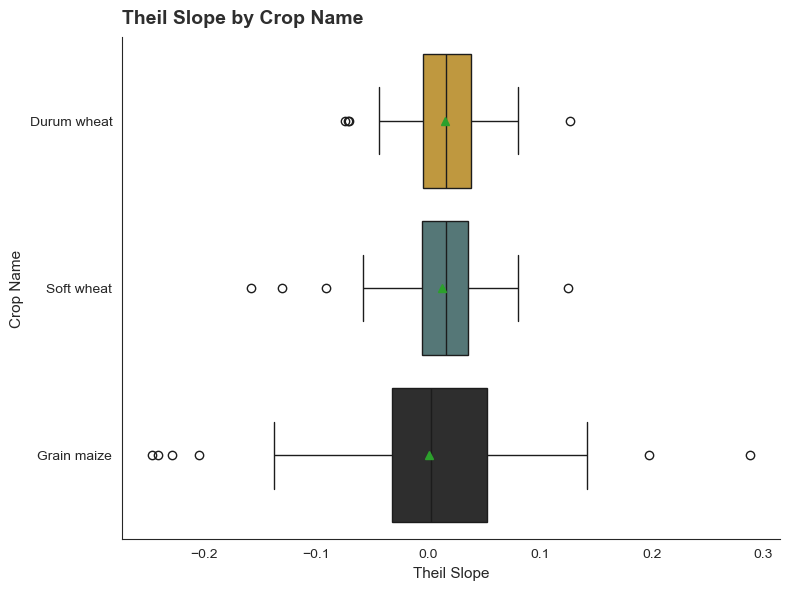

In [47]:
# Compare the distribution of local trend slopes across crops.
categorical_vs_numeric(
    trends,
    "crop_name",
    "theil_slope",
    kind="box"
)

The trend calculation retains 280 province-crop series. Median annual slopes are small and positive for both wheats (approximately 0.016 t/ha per year) and close to zero for grain maize, at about 0.003 t/ha per year.

The more important result is the dispersion between provinces. Maize slopes extend much further in both directions than wheat slopes, so a single national maize trend would conceal strongly different local trajectories. The trend component is therefore treated as series-specific and removed before the second PACF analysis.

### Partial autocorrelation

PACF must be calculated within each province-crop series and must not cross a missing year. Each series is therefore divided into uninterrupted runs of consecutive observations.

The analysis is repeated on observed and detrended yield. This makes it possible to distinguish persistence associated with the long-term trend from dependence that remains after the trend has been removed.

In [48]:
# Assign a run identifier whenever a province-crop series is
# interrupted by one or more missing years.
year_ordered = (
    production_df
    .sort_values(
        ["province", "crop_name", "year"]
    )
    .copy()
)

previous_year = (
    year_ordered
    .groupby(
        ["province", "crop_name"]
    )["year"]
    .shift()
)

new_run = (
    previous_year.isna()
    |
    (
        year_ordered["year"]
        - previous_year
        != 1
    )
)

year_ordered["run"] = (
    new_run
    .groupby(
        [
            year_ordered["province"],
            year_ordered["crop_name"]
        ]
    )
    .cumsum()
)

run_lengths = (
    year_ordered
    .groupby(
        ["province", "crop_name", "run"]
    )
    .size()
    .rename("length")
    .reset_index()
)

longest_run = (
    run_lengths
    .groupby(
        ["province", "crop_name"]
    )["length"]
    .max()
)

print(
    "Series:",
    longest_run.shape[0],
    "| continuous runs:",
    run_lengths.shape[0]
)

display(
    run_lengths
    .groupby(
        ["province", "crop_name"]
    )
    .size()
    .value_counts()
    .sort_index()
    .to_frame("series")
)

RUN_LENGTH_CANDIDATES = [
    10,
    15,
    20,
    24,
    28
]

retention_rows = []

for minimum_length in RUN_LENGTH_CANDIDATES:

    retained = longest_run[
        longest_run >= minimum_length
    ]

    retention_rows.append(
        {
            "minimum_run_length": minimum_length,
            "series_retained": len(retained),
            **retained
            .groupby(level="crop_name")
            .size()
            .to_dict()
        }
    )

display(
    pd.DataFrame(retention_rows)
)

Series: 298 | continuous runs: 350


,series
1,260
2,27
3,8
4,3


,minimum_run_length,series_retained,Durum wheat,Grain maize,Soft wheat
0,10,277,89,97,91
1,15,267,85,95,87
2,20,248,77,89,82
3,24,244,75,88,81
4,28,216,70,77,69


The 298 province-crop series are divided into 350 continuous runs. Most are complete: 260 series form one uninterrupted block, while a smaller group contains two or more runs. The median longest run is 28 years for all crops.

A minimum run length of 20 years retains 248 series: 77 for durum wheat, 89 for grain maize and 82 for soft wheat. This threshold provides enough observations to estimate five lags without restricting the analysis only to completely observed series.

In [49]:
# Compute PACF separately for every continuous run. Five annual lags
# are examined on both observed and detrended yield.
MINIMUM_RUN_LENGTH = 20
MAX_LAG = 5

series_runs = yield_trend.merge(
    year_ordered[
        [
            "province",
            "crop_name",
            "year",
            "run"
        ]
    ],
    how="left",
    on=[
        "province",
        "crop_name",
        "year"
    ]
)

pacf_rows = []

for (
    province,
    crop,
    run
), block in series_runs.groupby(
    ["province", "crop_name", "run"]
):

    if len(block) < MINIMUM_RUN_LENGTH:
        continue

    block = block.sort_values("year")

    for target in [
        "yield",
        "yield_detrended"
    ]:

        coefficients = pacf(
            block[target].to_numpy(),
            nlags=MAX_LAG,
            method="ywm"
        )

        significance_limit = (
            1.96
            / np.sqrt(len(block))
        )

        for lag in range(
            1,
            MAX_LAG + 1
        ):

            pacf_rows.append(
                {
                    "province": province,
                    "crop_name": crop,
                    "run": run,
                    "target": target,
                    "lag": lag,
                    "n_observations": len(block),
                    "pacf": coefficients[lag],
                    "significant": (
                        abs(coefficients[lag])
                        > significance_limit
                    )
                }
            )

pacf_results = pd.DataFrame(
    pacf_rows
)

pacf_summary = (
    pacf_results
    .groupby(
        ["target", "crop_name", "lag"]
    )
    .agg(
        runs=("pacf", "size"),
        median_pacf=("pacf", "median"),
        first_quartile=(
            "pacf",
            lambda values:
            values.quantile(0.25)
        ),
        third_quartile=(
            "pacf",
            lambda values:
            values.quantile(0.75)
        ),
        share_positive=(
            "pacf",
            lambda values:
            (values > 0).mean()
        ),
        share_significant=(
            "significant",
            "mean"
        )
    )
    .reset_index()
)

display(
    pacf_summary
)

,target,crop_name,lag,runs,median_pacf,first_quartile,third_quartile,share_positive,share_significant
0,yield,Durum wheat,1,77,0.229980,0.068406,0.457232,0.818182,0.337662
1,yield,Durum wheat,2,77,0.028957,-0.148582,0.152490,0.558442,0.077922
2,yield,Durum wheat,3,77,0.013224,-0.110095,0.121395,0.519481,0.077922
3,yield,Durum wheat,4,77,0.000234,-0.100788,0.119735,0.506494,0.038961
4,yield,Durum wheat,5,77,-0.014718,-0.124645,0.066350,0.467532,0.012987
5,yield,Grain maize,1,89,0.249905,0.054099,0.507213,0.808989,0.382022
6,yield,Grain maize,2,89,0.028692,-0.070653,0.144192,0.573034,0.033708
7,yield,Grain maize,3,89,0.038399,-0.053999,0.139133,0.584270,0.033708
8,yield,Grain maize,4,89,-0.034958,-0.124328,0.028198,0.325843,0.022472
9,yield,Grain maize,5,89,-0.064236,-0.141858,0.035139,0.337079,0.033708


yield


lag,1,2,3,4,5
crop_name,,,,,
Durum wheat,0.229980,0.028957,0.013224,0.000234,-0.014718
Grain maize,0.249905,0.028692,0.038399,-0.034958,-0.064236
Soft wheat,0.237755,0.032250,-0.031628,0.023562,-0.047560


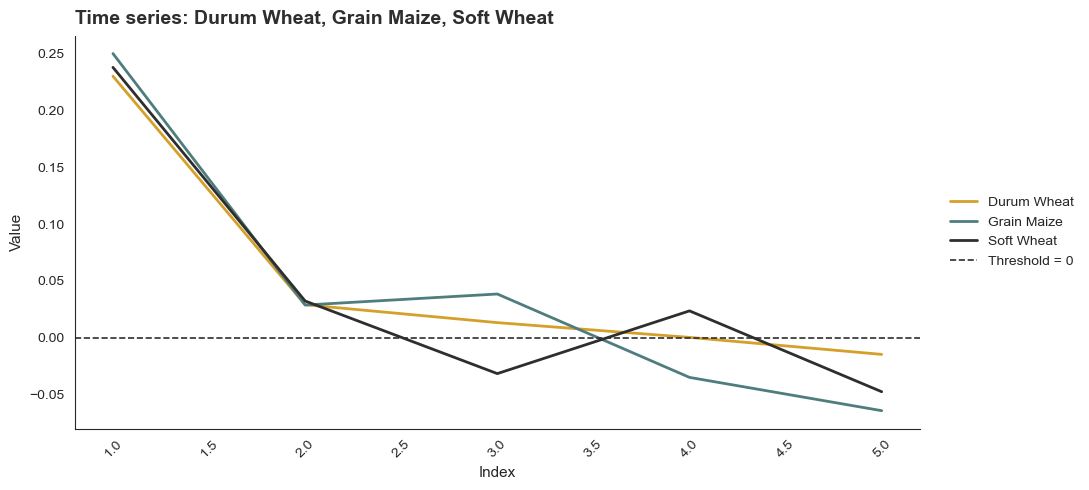

yield_detrended


lag,1,2,3,4,5
crop_name,,,,,
Durum wheat,0.096857,-0.047905,-0.073044,-0.086835,-0.085309
Grain maize,0.164748,-0.027001,-0.007328,-0.062819,-0.106516
Soft wheat,0.120166,-0.018103,-0.099391,-0.075359,-0.111467


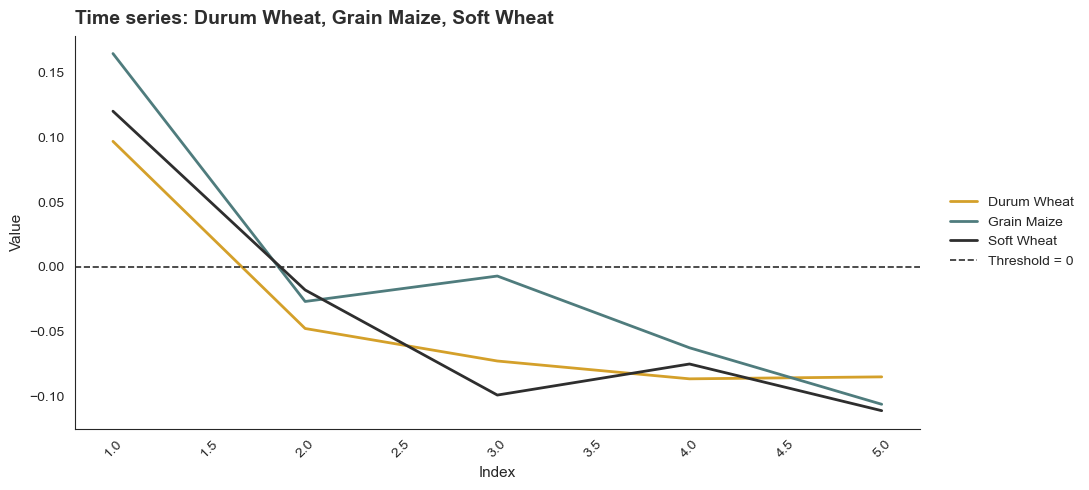

In [50]:
# Plot the median PACF across runs for each crop and target.
for target in [
    "yield",
    "yield_detrended"
]:

    print(target)

    median_pacf = (
        pacf_results[
            pacf_results["target"]
            == target
        ]
        .pivot_table(
            index="lag",
            columns="crop_name",
            values="pacf",
            aggfunc="median"
        )
    )

    display(
        median_pacf.T
    )

    plot_time_series(
        median_pacf,
        columns=median_pacf.columns.tolist(),
        hline=0
    )

The observed yield shows a recurring positive first lag across all crops. Median PACF at lag 1 is approximately 0.23 for durum wheat, 0.25 for grain maize and 0.24 for soft wheat. From lag 2 onward, the median partial coefficients are already close to zero.

After detrending, the first-lag coefficients fall to about 0.10, 0.16 and 0.12 respectively, while later lags are generally small or slightly negative. Part of the apparent persistence in the raw series is therefore associated with long-term trend.

The first annual lag is the only candidate showing a sufficiently recurrent signal across the dataset. This does not fix the final model specification, but it supports testing the previous year's yield as a candidate predictor rather than introducing several annual lags by default.

#### Cultivated area and yield

Provincial yield is an average over the cultivated surface, and the different parts of the province territory used can change from one year to the next. If newly cultivated land is systematically more or less productive than the land already in use, part of the observed yield change could be associated with the change in area rather than with climate (or other factors).

The relationship is therefore examined within each province-crop series and only between consecutive observations already validated in the production completeness analysis. Both quantities are expressed as year-over-year logarithmic changes, so the comparison concerns proportional rather than absolute variation and does not cross missing years or changes in territorial coverage.

In [51]:
# comparable_pairs contains observations that can be compared with the
# immediately preceding valid observation of the same province-crop series.
# Pairs separated by temporal gaps or changes in the production-area coverage
# have already been excluded, so the changes below refer to comparable years.

# Compute year-over-year logarithmic changes in cultivated area and yield.
#
# The logarithmic ratio log(current / previous) expresses a relative change:
# - values above zero indicate an increase;
# - values below zero indicate a decrease;
# - zero indicates no change.
#
# Log changes are used instead of absolute differences because provinces and
# crops can have very different levels of cultivated area and yield. The
# resulting changes are therefore more comparable across series.
area_yield_changes = comparable_pairs.assign(
    area_change=np.log(
        comparable_pairs["area"]
        / comparable_pairs["previous_area"]
    ),
    yield_change=np.log(
        comparable_pairs["yield"]
        / comparable_pairs["previous_yield"]
    )
)

# Store one summary row for each crop.
area_yield_association = []

# Analyse crops separately because the relationship between changes in
# cultivated area and changes in yield may differ across crop types.
for crop, block in area_yield_changes.groupby("crop_name"):

    # Fit a simple linear regression:
    #
    # yield_change = intercept + slope * area_change
    #
    # This is used as a descriptive measure of association, not as a
    # predictive model. The objective is to check whether years with changes
    # in cultivated area also tend to show systematic changes in yield.
    fit = stats.linregress(
        block["area_change"],
        block["yield_change"]
    )

    # rvalue is the Pearson correlation between the two logarithmic changes.
    # The slope indicates the average direction and magnitude of the estimated
    # change in yield associated with a one-unit log change in cultivated area.
    #
    # The number of valid pairs is retained because the amount of available
    # information can differ between crops.
    area_yield_association.append(
        {
            "crop_name": crop,
            "pairs": len(block),
            "correlation": fit.rvalue,
            "slope": fit.slope
        }
    )

# Display a compact crop-level summary of the association.
display(
    pd.DataFrame(area_yield_association)
)

,crop_name,pairs,correlation,slope
0,Durum wheat,2301,0.025218,0.012420
1,Grain maize,2544,-0.090875,-0.055939
2,Soft wheat,2362,0.025307,0.011030


The relationship is essentially absent for the two wheats: both slopes are close to zero. Grain maize shows a negative but weak association, with a slope of about -0.056 and a correlation close to -0.09. This is consistent with the possibility that changes in the cultivated surface slightly affect the provincial average yield, but the available data does not identify which land entered or left production.

No observation is corrected on this basis. The result is retained only as a limitation when interpreting the later maize-climate associations, which could partly absorb an effect of this direction and magnitude.

### Additional feature engineering
#### Why it is introduced here

The following part, before starting bivariate analysis, is technically part of feature engineering, but it is needed at this stage because the two main data sources have different time structures.

It was not ideal to do it from the beginning, because doing it would have made it impossible to observe the statistical information of individual climate features, but it is necessary to do it now to be able to perform bivariate analysis seeing the relationship between the target feature for the modelling (which will be yield) and the data that are going to be used as predictors.

Climate data is monthly, while production and yield are observed yearly for each crop and province. Before studying their relationships, the monthly climate observations therefore need to be transformed into features that are aligned with each crop and harvest year.

The transformation is kept simple and based on information defined before looking at the target: crop calendars determine which months belong to each development phase, while the aggregation rules depend on the meaning of each climate variable.

For this reason, the feature engineering performed here is mainly a **data-alignment step**. It creates variables that can be meaningfully compared with annual yield and later reused for modelling, without using the target itself to decide how the features are constructed.

### Growing season

As already said, climate table is monthly, whereas production is annual. A production observation for a given harvest year cannot therefore be matched to a single climate row: it must first be linked to the months during which that crop develops.

The JRC EU28 crop calendars for Italy are used to divide each crop cycle into three broad phases. Defining the phases before joining the datasets has two advantages: it preserves the temporal meaning of the climate variables and avoids treating all months of the year as equally relevant to the crop.

The original source is available at half-month resolution, while the climate data is monthly, so the transcription introduces some approximations:

- a blank interval between the source blocks for early growth and ripening is interpreted as the intermediate vegetative-reproductive phase;
- one national calendar is applied to every province;
- soft and durum wheat share the same calendar;
- each month is assigned to one phase even when the source changes phase within the month;
- the calendar is held fixed over the full observation period.

The next cells first define the calendars in a compact form, then convert them to a table that can be expanded over every harvest year and matched to the monthly climate data.


In [52]:
# Months are expressed as (year offset, month).
# An offset of -1 means that the month belongs to the year before harvest;
# an offset of 0 means that it belongs to the harvest year itself.

# Soft and durum wheat use the same JRC calendar.
WHEAT_PHASES = {
    "planting_early_vegetative": [
        (-1, 9),
        (-1, 10),
        (-1, 11),
    ],
    "vegetative_reproductive": [
        (-1, 12),
        (0, 1),
        (0, 2),
        (0, 3),
        (0, 4),
        (0, 5),
    ],
    "ripening_harvest": [
        (0, 6),
        (0, 7),
    ],
}

# Store the active phase definition for every crop.
CROP_PHASES = {
    "Durum wheat": WHEAT_PHASES,
    "Soft wheat": WHEAT_PHASES,
    "Grain maize": {
        "planting_early_vegetative": [
            (0, 4),
        ],
        "vegetative_reproductive": [
            (0, 5),
            (0, 6),
            (0, 7),
            (0, 8),
        ],
        "ripening_harvest": [
            (0, 9),
            (0, 10),
            (0, 11),
        ],
    },
}

In [53]:
# Convert the nested dictionaries into a tabular calendar.
# Each row now identifies one crop, one phase and one relative month.
calendar_months = pd.DataFrame(
    [
        {
            "crop_name": crop,
            "phase": phase,
            "year_offset": year_offset,
            "month": month,
        }
        for crop, phases in CROP_PHASES.items()
        for phase, months in phases.items()
        for year_offset, month in months
    ]
)

# A crop-month must belong to one phase only; otherwise a climate month
# would be counted twice when phase features are constructed.
assert not calendar_months.duplicated(
    ["crop_name", "year_offset", "month"]
).any()

display(calendar_months)

,crop_name,phase,year_offset,month
0,Durum wheat,planting_early_vegetative,-1,9
1,Durum wheat,planting_early_vegetative,-1,10
2,Durum wheat,planting_early_vegetative,-1,11
3,Durum wheat,vegetative_reproductive,-1,12
4,Durum wheat,vegetative_reproductive,0,1
5,Durum wheat,vegetative_reproductive,0,2
6,Durum wheat,vegetative_reproductive,0,3
7,Durum wheat,vegetative_reproductive,0,4
8,Durum wheat,vegetative_reproductive,0,5
9,Durum wheat,ripening_harvest,0,6


The dictionaries above are intentionally compact, but they are not yet convenient for joining with data. The next step converts them to a long table where every row explicitly states which relative month belongs to which crop phase.

This representation also makes it possible to check that no month has accidentally been assigned to two phases of the same crop.


In [54]:
# Expand the relative calendars over every harvest year in the production data.
HARVEST_YEARS = sorted(
    production_df["year"].unique()
)

growing_season = pd.concat(
    [
        calendar_months.assign(
            harvest_year=harvest_year
        )
        for harvest_year in HARVEST_YEARS
    ],
    ignore_index=True,
)

# Convert each relative month into its actual calendar year and YYYY-MM key.
growing_season["year"] = (
    growing_season["harvest_year"]
    + growing_season["year_offset"]
)

growing_season["year_month"] = (
    growing_season["year"].astype(str)
    + "-"
    + growing_season["month"].astype(str).str.zfill(2)
)

# Check that every month requested by the crop calendars exists for all
# provinces in the climate dataset before any aggregation is attempted.
required_months = growing_season["year_month"].unique()
expected_provinces = climate_df["PROVINCE"].nunique()

month_coverage = (
    climate_df
    .groupby("YEAR_MONTH")["PROVINCE"]
    .nunique()
    .reindex(required_months)
)

assert month_coverage.eq(expected_provinces).all()

`calendar_months` describes a generic harvest cycle. It still uses relative years (`-1` or `0`) rather than actual dates.

The next cell repeats this generic calendar for every production year and converts each relative month into the same `YYYY-MM` key used by the climate dataset. This is the point where the agronomic calendar becomes directly joinable to the observed climate data.


In [55]:
# Summarise the effective time window used for each crop.
season_summary = (
    growing_season
    .groupby("crop_name")
    .agg(
        earliest_month=("year_month", "min"),
        latest_month=("year_month", "max"),
    )
)

season_summary.insert(
    0,
    "months_per_harvest",
    calendar_months
    .groupby("crop_name")
    .size(),
)

display(season_summary)

print(
    "Harvest years:", len(HARVEST_YEARS),
    "| required months:", len(required_months),
    "| provinces per required month:", expected_provinces,
    "| complete climate coverage:", True,
)

,months_per_harvest,earliest_month,latest_month
crop_name,,,
Durum wheat,11,1994-09,2022-07
Grain maize,8,1995-04,2022-11
Soft wheat,11,1994-09,2022-07


Harvest years: 28 | required months: 339 | provinces per required month: 106 | complete climate coverage: True


Both wheat calendars cover **11 months**, from September of the year preceding the harvest to July of the harvest year. Grain maize covers **8 months**, from April to November of the harvest year.

At this point the relative crop calendars have become explicit `(crop, harvest year, phase, month)` mappings. The climate coverage check also confirms that every required month is available for every province, so no phase will be shortened simply because a climate month is absent.

The calendar can therefore be used as the temporal bridge between the monthly climate dataset and the annual production observations.


#### Construction of model-aligned climate features

The previous section established **which months belong to each crop phase**. This section performs the complementary step: it determines **how the climate values from those months are combined**.

Climate observations are monthly, whereas yield is observed once per crop, province and harvest year. Each group of monthly observations is therefore reduced to one value per climate variable and crop phase, using the aggregation rules defined earlier.

The transformation is carried out before production is joined. This keeps the construction of climate features independent of the target and preserves the complete climate dataset even where production observations are missing.

The sequence is:

1. determine how many months each crop-year-phase should contain;
2. match those months to the climate observations and aggregate them;
3. verify that every expected phase is complete;
4. reshape the three phases into columns;
5. add the static province characteristics;
6. finally add current and one-year-lagged production variables.


In [56]:
# Reuse the column-level rules prepared in the climate EDA section.
PHASE_AGGREGATION = phase_rules.to_dict()

# YEAR_MONTH is not a model feature here. Counting its unique values lets us
# verify how many monthly observations actually entered each phase.
PHASE_AGGREGATION["YEAR_MONTH"] = "nunique"

In [57]:
# Keys that identify one expected crop phase independently of province.
CALENDAR_KEYS = [
    "crop_name",
    "harvest_year",
    "phase",
]

# Adding PROVINCE identifies one actual phase window in the climate dataset.
PHASE_KEYS = [
    "crop_name",
    "PROVINCE",
    "harvest_year",
    "phase",
]

# Count how many calendar months each crop-year-phase is expected to contain.
# These counts are used after aggregation as a structural completeness check.
expected_months = (
    growing_season
    .groupby(CALENDAR_KEYS, as_index=False)["year_month"]
    .nunique()
    .rename(
        columns={
            "year_month": "expected_months"
        }
    )
)

# Keep only the monthly key, province and dynamic climate variables.
# Static province characteristics are intentionally added later.
climate_monthly = climate_df[
    [
        "YEAR_MONTH",
        "PROVINCE",
        *CLIMATE_COLUMNS,
    ]
]

Two ingredients are now ready for the phase aggregation:

- `growing_season` specifies **which month** belongs to each crop, harvest year and phase;
- `climate_monthly` contains **what was observed** in each province and month.

Joining them creates the monthly observations required by each crop phase. The following `groupby` then applies the previously defined rule for every climate variable.


In [58]:
# Match every required crop month to the corresponding province-month climate
# observations, then reduce the monthly rows to one row per crop phase.
phase_features_long = (
    growing_season
    .merge(
        climate_monthly,
        left_on="year_month",
        right_on="YEAR_MONTH",
        how="left",
    )
    .groupby(
        PHASE_KEYS,
        as_index=False,
    )
    .agg(PHASE_AGGREGATION)
    .rename(
        columns={
            "YEAR_MONTH": "observed_months"
        }
    )
    .merge(
        expected_months,
        on=CALENDAR_KEYS,
        how="left",
        validate="many_to_one",
    )
)

In [59]:
# The expected number of phase windows is:
# crop-year-phase combinations × number of provinces.
expected_windows = (
    len(expected_months)
    * expected_provinces
)

# Check both the number of windows and the number of months inside each one.
assert len(phase_features_long) == expected_windows

assert phase_features_long[
    "observed_months"
].eq(
    phase_features_long["expected_months"]
).all()

print(
    "Phase windows:", len(phase_features_long),
    "| complete windows:", True,
)

Phase windows: 26712 | complete windows: True


The long table is useful for constructing and checking the phase windows, but it is not yet the desired modelling shape. Once completeness is confirmed, each crop-province-harvest combination should occupy a single row.

The next step therefore moves the three phase labels from rows into feature names.


In [60]:
FEATURE_KEYS = [
    "crop_name",
    "PROVINCE",
    "harvest_year",
]

# Each row currently represents one phase. Pivot the phase labels into columns
# so that one row represents a complete crop-province-harvest observation.
phase_features = (
    phase_features_long
    .drop(
        columns=[
            "observed_months",
            "expected_months",
        ]
    )
    .pivot(
        index=FEATURE_KEYS,
        columns="phase",
    )
)

# Flatten the two-level columns created by pivot, preserving both the original
# climate variable and the phase from which the feature was calculated.
phase_features.columns = [
    f"{column}__{phase}"
    for column, phase in phase_features.columns
]

phase_features = phase_features.reset_index()

CLIMATE_FEATURE_COLUMNS = [
    column
    for column in phase_features.columns
    if column not in FEATURE_KEYS
]

In [61]:
# Province characteristics are static over time, so they are added once after
# the monthly climate variables have already been aggregated by crop phase.
STATIC_FEATURE_COLUMNS = [
    column
    for column in provinces.columns
    if column not in [
        "PROVINCE",
        "REGION",
    ]
]

climate_features = (
    phase_features
    .merge(
        provinces,
        on="PROVINCE",
        how="left",
        validate="many_to_one",
    )
)

# Keep identifiers first, followed by static and phase-level climate features.
climate_features = climate_features[
    FEATURE_KEYS
    + ["REGION"]
    + STATIC_FEATURE_COLUMNS
    + CLIMATE_FEATURE_COLUMNS
]

# The climate dataset was complete before the transformation, so all constructed
# climate and static features are expected to remain populated.
assert climate_features[
    [
        "REGION",
        *STATIC_FEATURE_COLUMNS,
        *CLIMATE_FEATURE_COLUMNS,
    ]
].notna().all().all()

print(
    "Rows:", len(climate_features),
    "| climate features:", len(CLIMATE_FEATURE_COLUMNS),
    "| static territorial features:", len(STATIC_FEATURE_COLUMNS),
    "| missing feature cells:", 0,
)

display(climate_features.head())

display(climate_features.tail())

Rows: 8904 | climate features: 192 | static territorial features: 6 | missing feature cells: 0


,crop_name,PROVINCE,harvest_year,REGION,N_CELLS,ALTITUDE_MIN,ALTITUDE_MAX,ALTITUDE_RANGE,ALTITUDE_MEAN,ALTITUDE_STD,...,MAX_CONSECUTIVE_WET_DAYS_AREA_MEAN__vegetative_reproductive,MAX_CONSECUTIVE_FROST_10PCT_DAYS__planting_early_vegetative,MAX_CONSECUTIVE_FROST_10PCT_DAYS__ripening_harvest,MAX_CONSECUTIVE_FROST_10PCT_DAYS__vegetative_reproductive,MAX_CONSECUTIVE_HOT_30_10PCT_DAYS__planting_early_vegetative,MAX_CONSECUTIVE_HOT_30_10PCT_DAYS__ripening_harvest,MAX_CONSECUTIVE_HOT_30_10PCT_DAYS__vegetative_reproductive,MAX_CONSECUTIVE_HOT_35_10PCT_DAYS__planting_early_vegetative,MAX_CONSECUTIVE_HOT_35_10PCT_DAYS__ripening_harvest,MAX_CONSECUTIVE_HOT_35_10PCT_DAYS__vegetative_reproductive
0,Durum wheat,Agrigento,1995,Sicilia,58,1,864,863,256.655172,200.313224,...,8,0,0,0,4,9,0,0,0,0
1,Durum wheat,Agrigento,1996,Sicilia,58,1,864,863,256.655172,200.313224,...,5,0,0,0,2,7,0,0,2,0
2,Durum wheat,Agrigento,1997,Sicilia,58,1,864,863,256.655172,200.313224,...,4,0,0,0,1,12,2,0,2,0
3,Durum wheat,Agrigento,1998,Sicilia,58,1,864,863,256.655172,200.313224,...,5,0,0,0,3,6,0,0,3,0
4,Durum wheat,Agrigento,1999,Sicilia,58,1,864,863,256.655172,200.313224,...,4,0,0,2,3,5,1,0,1,0


,crop_name,PROVINCE,harvest_year,REGION,N_CELLS,ALTITUDE_MIN,ALTITUDE_MAX,ALTITUDE_RANGE,ALTITUDE_MEAN,ALTITUDE_STD,...,MAX_CONSECUTIVE_WET_DAYS_AREA_MEAN__vegetative_reproductive,MAX_CONSECUTIVE_FROST_10PCT_DAYS__planting_early_vegetative,MAX_CONSECUTIVE_FROST_10PCT_DAYS__ripening_harvest,MAX_CONSECUTIVE_FROST_10PCT_DAYS__vegetative_reproductive,MAX_CONSECUTIVE_HOT_30_10PCT_DAYS__planting_early_vegetative,MAX_CONSECUTIVE_HOT_30_10PCT_DAYS__ripening_harvest,MAX_CONSECUTIVE_HOT_30_10PCT_DAYS__vegetative_reproductive,MAX_CONSECUTIVE_HOT_35_10PCT_DAYS__planting_early_vegetative,MAX_CONSECUTIVE_HOT_35_10PCT_DAYS__ripening_harvest,MAX_CONSECUTIVE_HOT_35_10PCT_DAYS__vegetative_reproductive
8899,Soft wheat,Viterbo,2018,Lazio,56,4,626,622,248.017857,158.827807,...,10,2,0,8,1,31,2,0,3,0
8900,Soft wheat,Viterbo,2019,Lazio,56,4,626,622,248.017857,158.827807,...,7,1,0,8,5,24,0,0,7,0
8901,Soft wheat,Viterbo,2020,Lazio,56,4,626,622,248.017857,158.827807,...,4,0,0,11,8,31,1,0,5,0
8902,Soft wheat,Viterbo,2021,Lazio,56,4,626,622,248.017857,158.827807,...,10,1,0,5,17,22,0,0,5,0
8903,Soft wheat,Viterbo,2022,Lazio,56,4,626,622,248.017857,158.827807,...,5,2,0,14,9,31,4,0,16,1


The aggregation produces one feature for each combination of dynamic climate variable and crop phase. Since the 64 monthly climate variables are represented across three phases, the resulting table contains **192 phase-level climate features**.

The `pivot` changes only the shape of the data: the phase information that was previously stored in separate rows is now encoded in the feature names. Static province characteristics are then added separately because they do not require temporal aggregation.

The resulting `climate_features` dataframe contains one row per crop, province and harvest year. Production is still kept separate at this stage: climate coverage is complete, while the production dataset contains missing crop-province-year combinations.


#### Production data and one-year lag

The climate features can now be aligned with the annual production observations because both datasets use the same conceptual unit: **crop × province × harvest year**.

The join is left-sided from `climate_features`. This is deliberate: a missing production observation should remain visible as a missing target rather than removing an otherwise complete climate row.

Area, production and yield from the immediately preceding harvest year are also added as lag-1 features. The lag is created by moving the **year key** of each historical production observation forward by one year. For example, values observed in 2005 are assigned to the 2006 row as `_lag_1`. This preserves the original values and makes the temporal relationship explicit.

A lag is available only when the immediately preceding year exists for the same province and crop.


In [62]:
# The final joins use the same crop-province-harvest keys as climate_features.
MERGE_KEYS = FEATURE_KEYS

PRODUCTION_VALUE_COLUMNS = [
    "area",
    "production",
    "yield",
]

# Rename production identifiers to match the climate-feature dataframe.
production_current = (
    production_df
    .rename(
        columns={
            "province": "PROVINCE",
            "year": "harvest_year",
        }
    )
    .copy()
)

# Build lag-1 features from the same production table.
production_lag_1 = (
    production_current[
        MERGE_KEYS
        + PRODUCTION_VALUE_COLUMNS
    ]
    .copy()
)

# Moving the key forward means that year t values will join to year t+1.
production_lag_1["harvest_year"] += 1

production_lag_1 = production_lag_1.rename(
    columns={
        column: f"{column}_lag_1"
        for column in PRODUCTION_VALUE_COLUMNS
    }
)

The two production tables now have complementary meanings: `production_current` uses the observation year itself, while `production_lag_1` uses the same historical values with the join year shifted forward.

Both can therefore be merged onto `climate_features` with the same keys and without any special time-series join logic.


In [63]:
# Preserve every climate-feature row and add production where a matching
# crop-province-year observation exists. The second merge adds the lagged values.
modeling_df = (
    climate_features
    .merge(
        production_current,
        on=MERGE_KEYS,
        how="left",
        validate="one_to_one",
    )
    .merge(
        production_lag_1,
        on=MERGE_KEYS,
        how="left",
        validate="one_to_one",
    )
)

# A left join with one-to-one production keys must not change row count.
assert len(modeling_df) == len(climate_features)

print(
    "Rows:", len(modeling_df),
    "| production observations:",
    modeling_df["yield"].notna().sum(),
    "| observations with one-year lag:",
    modeling_df["yield_lag_1"].notna().sum(),
)

Rows: 8904 | production observations: 7576 | observations with one-year lag: 7304


In [64]:
# Inspect only the identifiers, current production values and lag-1 values.
# Climate features are omitted from this preview because there are many columns.
preview_columns = (
    MERGE_KEYS
    + PRODUCTION_VALUE_COLUMNS
    + [
        f"{column}_lag_1"
        for column in PRODUCTION_VALUE_COLUMNS
    ]
)

display(
    modeling_df[
        preview_columns
    ].head()
)

display(
    modeling_df[
        preview_columns
    ].tail()
)

,crop_name,PROVINCE,harvest_year,area,production,yield,area_lag_1,production_lag_1,yield_lag_1
0,Durum wheat,Agrigento,1995,50190.0,79199.8,1.578000,NaN,NaN,NaN
1,Durum wheat,Agrigento,1996,51520.0,114776.2,2.227799,50190.0,79199.8,1.578000
2,Durum wheat,Agrigento,1997,50200.0,120480.0,2.400000,51520.0,114776.2,2.227799
3,Durum wheat,Agrigento,1998,34039.0,81693.6,2.400000,50200.0,120480.0,2.400000
4,Durum wheat,Agrigento,1999,48000.0,96000.0,2.000000,34039.0,81693.6,2.400000


,crop_name,PROVINCE,harvest_year,area,production,yield,area_lag_1,production_lag_1,yield_lag_1
8899,Soft wheat,Viterbo,2018,2450.0,11100.0,4.530612,2500.0,9000.0,3.600000
8900,Soft wheat,Viterbo,2019,2800.0,13800.0,4.928571,2450.0,11100.0,4.530612
8901,Soft wheat,Viterbo,2020,2700.0,13200.0,4.888889,2800.0,13800.0,4.928571
8902,Soft wheat,Viterbo,2021,2690.0,12850.0,4.776952,2700.0,13200.0,4.888889
8903,Soft wheat,Viterbo,2022,2680.0,11300.0,4.216418,2690.0,12850.0,4.776952


The final dataframe preserves the complete climate data and adds production information wherever a corresponding observation is available.

Missing current production values identify crop-province-year combinations not reported in the production dataset. Missing lagged values have a different meaning: they occur when the immediately preceding production year is unavailable for that same crop and province. Keeping these two kinds of absence distinct will be important when the modelling sample is selected.

At this stage the temporal alignment is complete: monthly climate information has been converted to crop-phase features, province characteristics have been added without temporal aggregation, and current and lagged production variables share the same row structure.

This dataframe can now be used for the bivariate analysis and, subsequently, as the basis for modelling. Supervised analyses will use only observations for which the target yield is available.


### Environmental patterns across crop phases

The constructed climate features can now be examined at the same crop–province–harvest level that will later be used for modelling.

Each environmental variable is represented separately for the three crop-development phases. The analysis below compares these phase-level features separately for durum wheat, soft wheat and grain maize, since the same phase labels correspond to different calendar windows across crops.

Two complementary views are used:

- horizontal boxplots compare the distribution across provinces and harvest years for the different phases;
- annual time series show how the typical value of each phase-level feature changes over time.

For the time series, the median across provinces is used for each harvest year. This provides a compact national-level view without allowing a small number of extreme provincial values to dominate the temporal pattern.

In [65]:
# Select representative phase-level features across the main environmental
# families already examined in the monthly climate data.
PHASE_PLOT_SELECTION = [
    "TEMPERATURE_AVG_MONTH",
    "PRECIPITATION_TOTAL_MONTH",
    "ET0_TOTAL_MONTH",
    "RADIATION_TOTAL_MONTH",
    "VAPOURPRESSURE_AVG_MONTH",
    "WINDSPEED_AVG_MONTH",
    "WET_DAYS_AREA_MEAN",
    "MAX_CONSECUTIVE_DRY_DAYS_AREA_MEAN",
    "DAYS_HOT_30_10PCT",
    "DAYS_FROST_10PCT",
    "DAYS_EXTREME_RAIN",
]

PHASES = [
    "planting_early_vegetative",
    "vegetative_reproductive",
    "ripening_harvest",
]

PHASE_LABELS = {
    "planting_early_vegetative": "Planting / early vegetative",
    "vegetative_reproductive": "Vegetative / reproductive",
    "ripening_harvest": "Ripening / harvest",
}

CROPS = [
    "Durum wheat",
    "Soft wheat",
    "Grain maize",
]

### Environmental patterns across crop phases

The constructed climate features are examined according to the two distinct crop calendars used in the analysis: wheat and grain maize.

Durum wheat and soft wheat share the same crop-development calendar and therefore use the same monthly windows to construct their phase-level environmental features. To avoid duplicating the same descriptive climate analysis, they are represented together by the wheat calendar in this section. The two crops remain separate observations in the subsequent analyses involving production and yield.

For each selected environmental variable, horizontal boxplots compare the distribution across the crop phases, while annual time series show the median across provinces for each harvest year.

Phase totals and event counts are shown as constructed. Their magnitude therefore also reflects the different duration of the crop phases and should not be interpreted as monthly rates.


WHEAT

Temperature Avg Month


,count,mean,std,min,25%,50%,75%,max
variable,,,,,,,,
Planting / early vegetative,2968.0,14.722457,2.911520,3.043878,13.301436,14.767369,16.654805,21.161536
Ripening / harvest,2968.0,22.140477,2.408713,9.990069,21.245154,22.441656,23.644464,27.245726
Vegetative / reproductive,2968.0,9.267418,2.560823,-1.593505,8.113149,9.277432,11.015067,14.948042


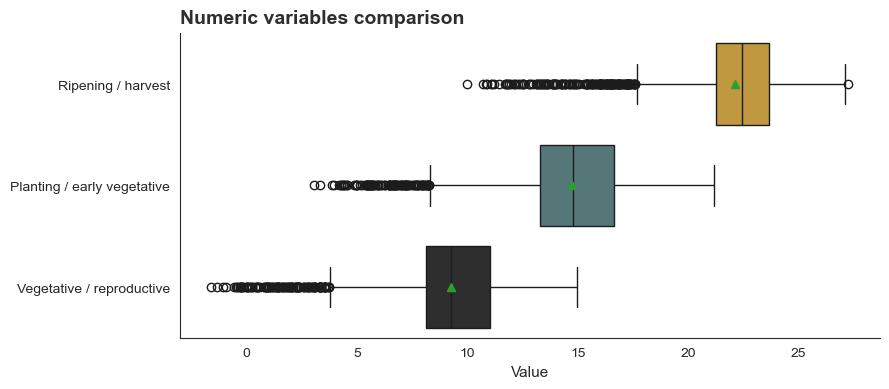

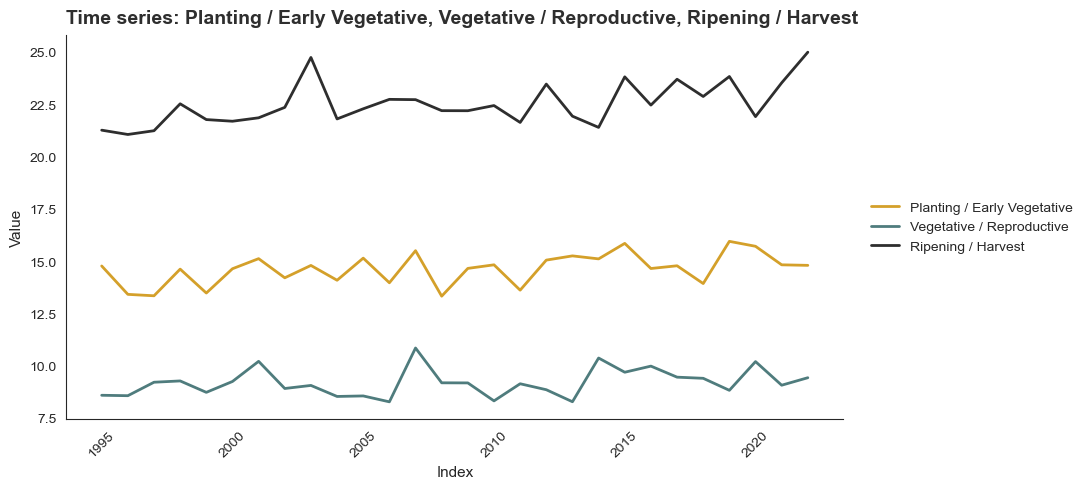


Precipitation Total Month


,count,mean,std,min,25%,50%,75%,max
variable,,,,,,,,
Planting / early vegetative,2968.0,282.338733,131.946353,36.750000,190.941667,260.398684,341.902542,1110.604651
Ripening / harvest,2968.0,92.090631,76.405584,0.000000,37.305601,69.454545,130.065217,452.813953
Vegetative / reproductive,2968.0,403.533196,170.314484,80.210526,284.119260,372.749337,487.271205,1336.400000


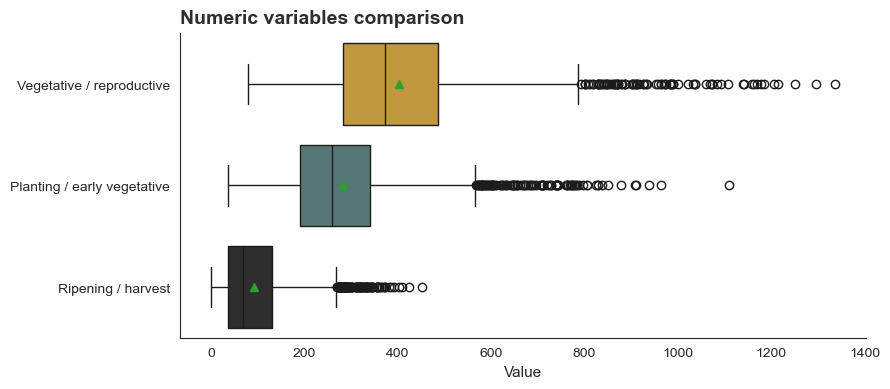

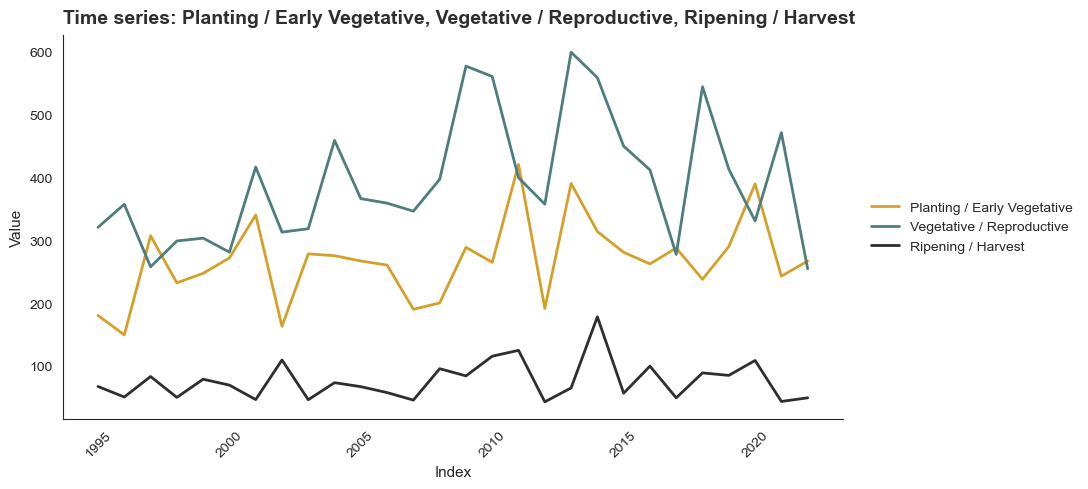


Et0 Total Month


,count,mean,std,min,25%,50%,75%,max
variable,,,,,,,,
Planting / early vegetative,2968.0,186.192216,42.390696,105.415385,150.224965,181.160699,218.312082,306.332955
Ripening / harvest,2968.0,316.590532,39.320232,175.139216,291.628422,317.068574,342.943352,424.792661
Vegetative / reproductive,2968.0,365.851700,58.206394,216.994118,321.861954,358.073913,406.950598,542.184211


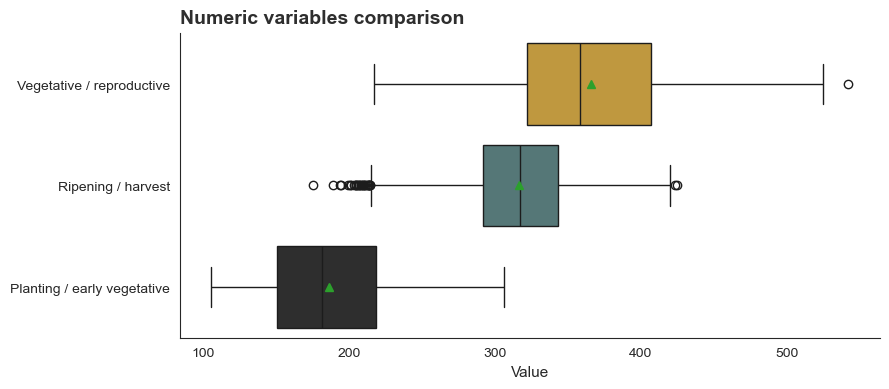

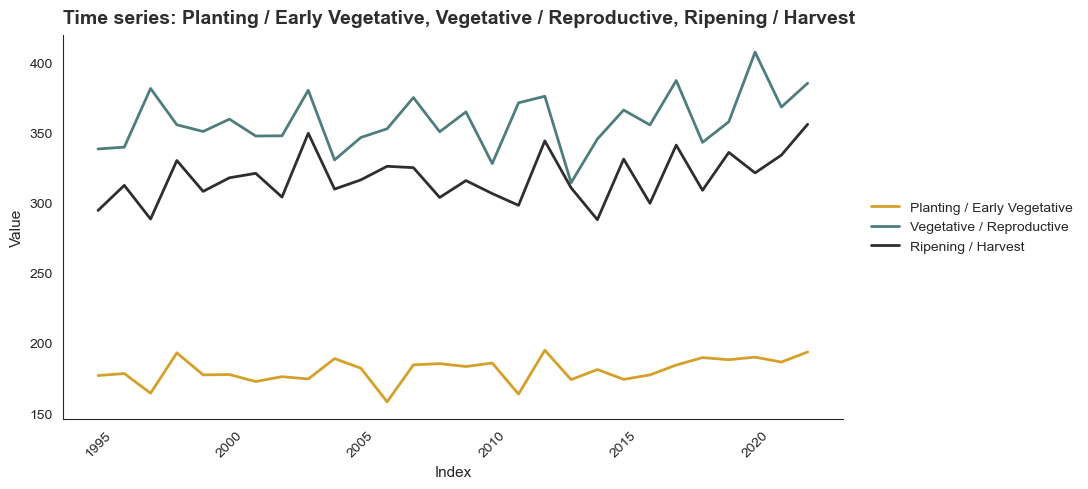


Radiation Total Month


,count,mean,std,min,25%,50%,75%,max
variable,,,,,,,,
Planting / early vegetative,2968.0,1.019392e+06,130087.781268,7.448279e+05,9.132757e+05,1.013940e+06,1.120167e+06,1.389585e+06
Ripening / harvest,2968.0,1.555010e+06,121683.599087,1.164094e+06,1.472472e+06,1.574941e+06,1.643148e+06,1.933394e+06
Vegetative / reproductive,2968.0,2.295365e+06,222010.418014,1.650478e+06,2.132383e+06,2.296283e+06,2.458646e+06,3.137255e+06


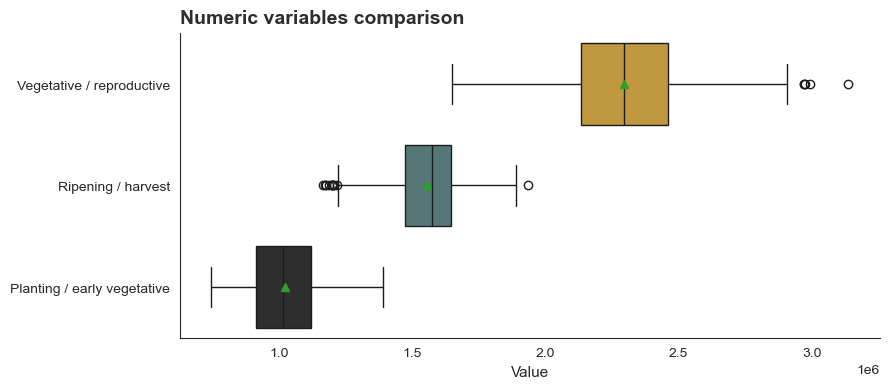

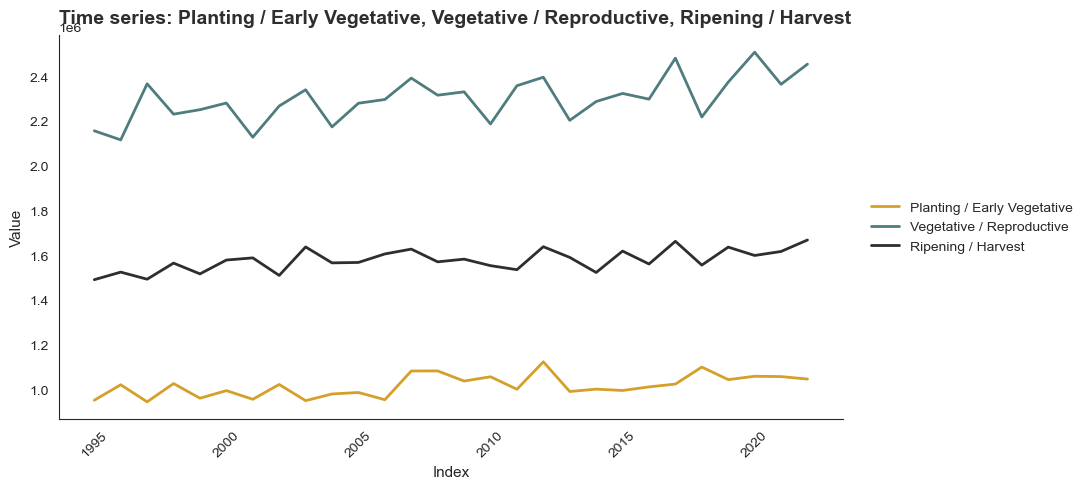


Vapourpressure Avg Month


,count,mean,std,min,25%,50%,75%,max
variable,,,,,,,,
Planting / early vegetative,2968.0,13.357327,2.325851,5.833475,12.094536,13.297782,14.708869,19.556140
Ripening / harvest,2968.0,17.847203,2.231765,9.562961,16.681862,17.968226,19.282939,25.281821
Vegetative / reproductive,2968.0,9.072145,1.609984,4.066671,8.204574,9.073289,10.056439,13.135409


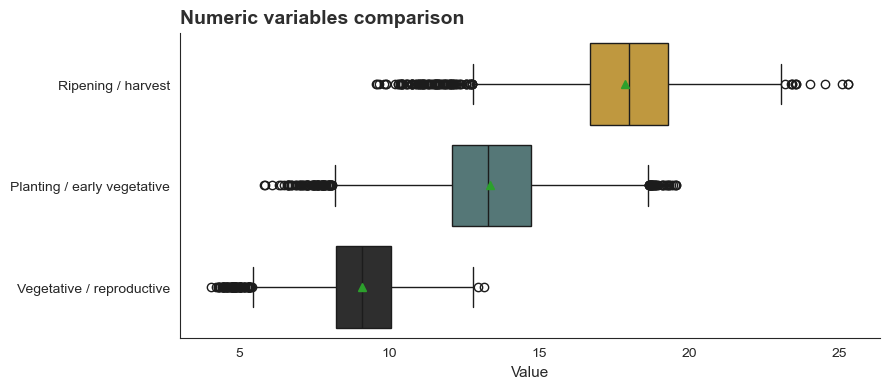

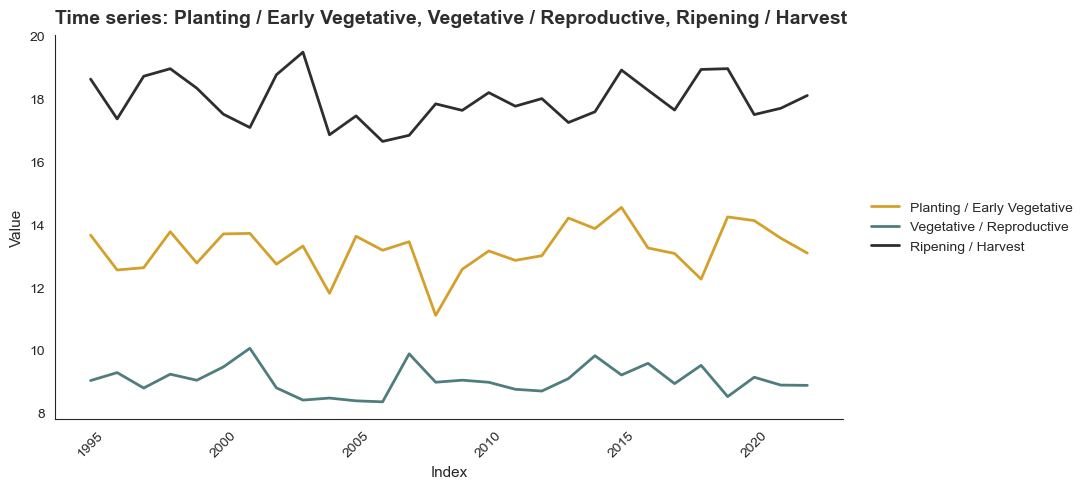


Windspeed Avg Month


,count,mean,std,min,25%,50%,75%,max
variable,,,,,,,,
Planting / early vegetative,2968.0,2.534308,0.834313,0.891095,1.859423,2.414807,3.172023,6.303465
Ripening / harvest,2968.0,2.599219,0.668723,1.205382,2.112130,2.483504,3.022543,5.534775
Vegetative / reproductive,2968.0,2.821256,0.896696,0.950178,2.090005,2.671055,3.503944,6.047233


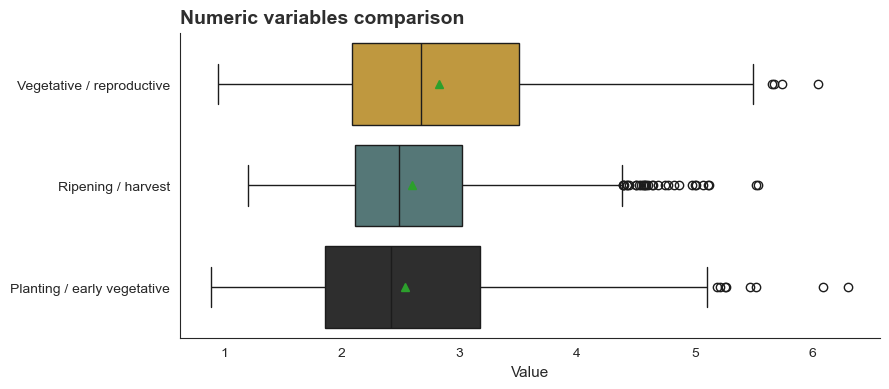

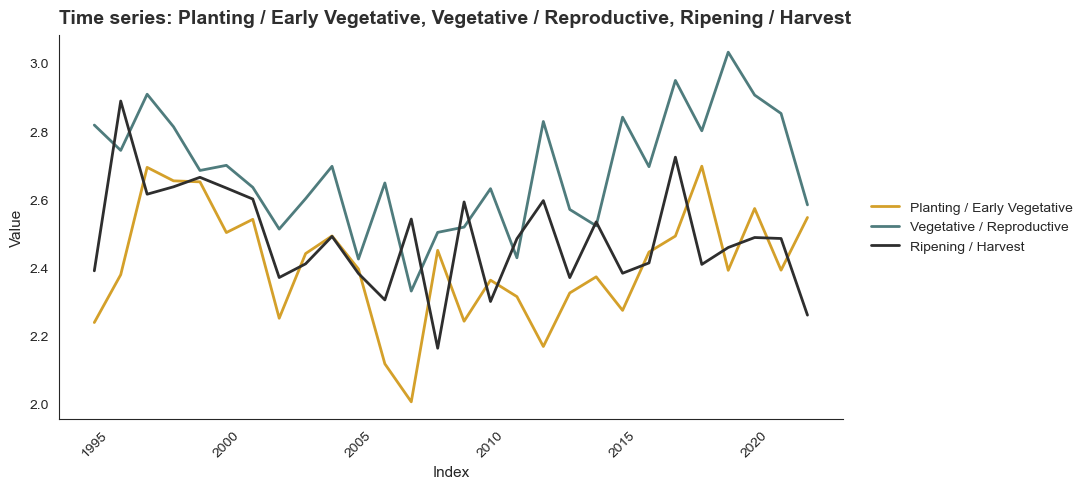


Wet Days Area Mean


,count,mean,std,min,25%,50%,75%,max
variable,,,,,,,,
Planting / early vegetative,2968.0,30.697776,7.941433,8.0,25.0,31.0,36.0,57.0
Ripening / harvest,2968.0,15.132412,9.680835,0.0,8.0,13.0,21.0,50.0
Vegetative / reproductive,2968.0,57.613544,15.137386,18.0,47.0,57.0,67.0,113.0


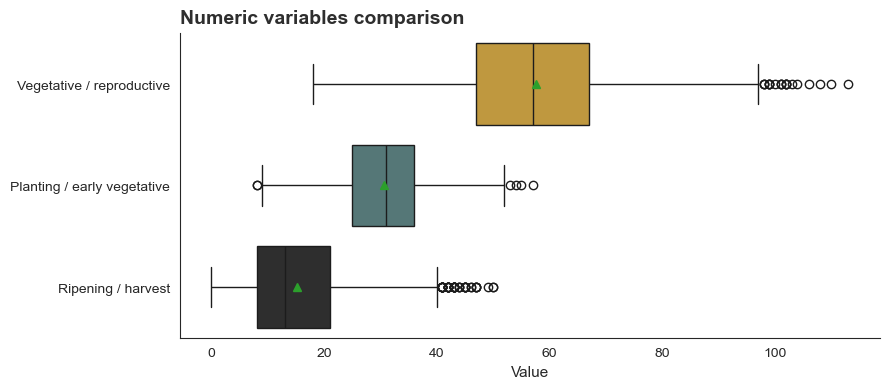

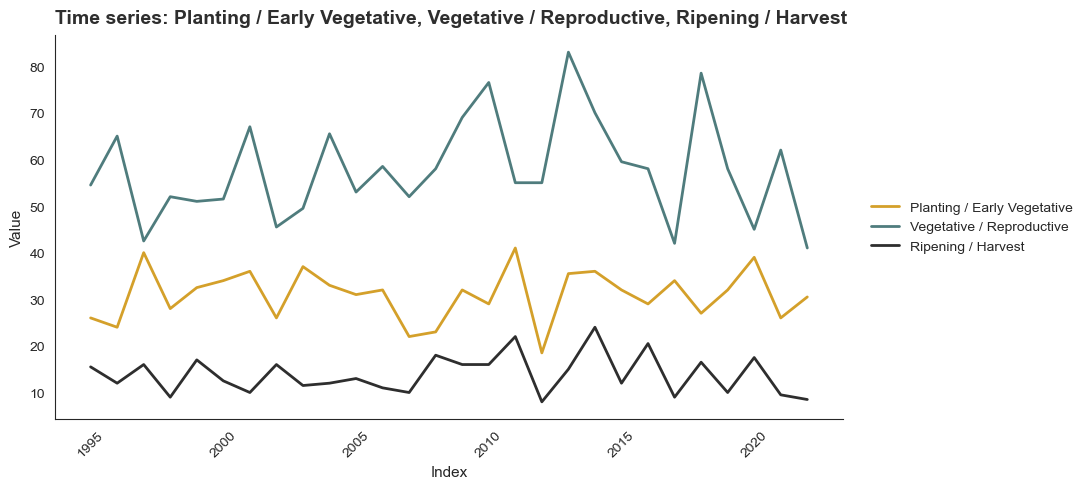


Max Consecutive Dry Days Area Mean


,count,mean,std,min,25%,50%,75%,max
variable,,,,,,,,
Planting / early vegetative,2968.0,14.367251,4.905363,4.0,11.0,14.0,17.0,31.0
Ripening / harvest,2968.0,15.684636,7.559066,2.0,10.0,14.0,20.0,31.0
Vegetative / reproductive,2968.0,18.802898,5.707737,6.0,15.0,18.0,23.0,31.0


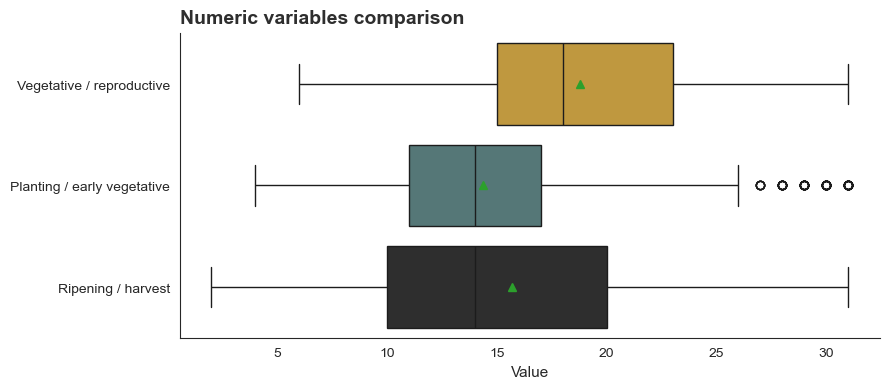

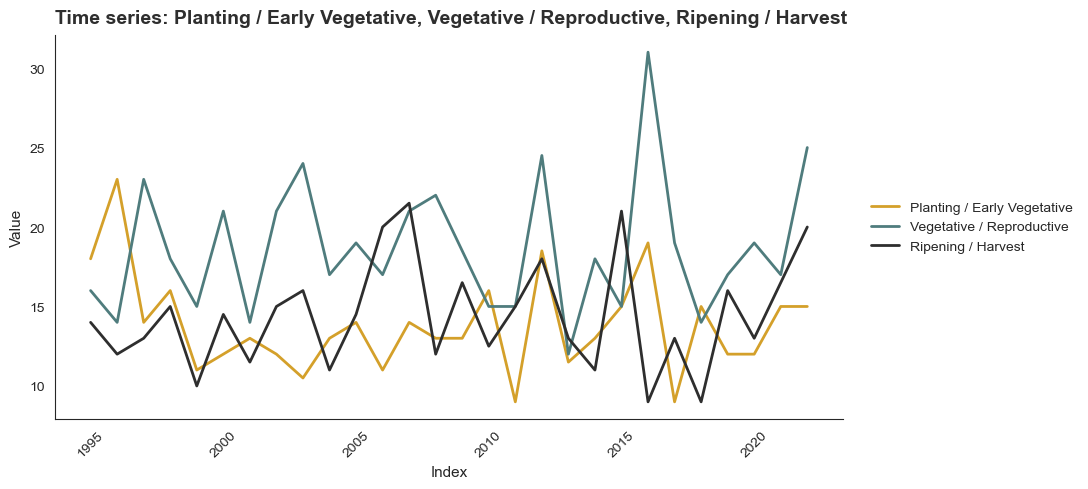


Days Hot 30 10Pct


,count,mean,std,min,25%,50%,75%,max
variable,,,,,,,,
Planting / early vegetative,2968.0,5.456199,5.479942,0.0,1.0,4.0,8.0,31.0
Ripening / harvest,2968.0,33.408019,12.126661,0.0,25.0,34.0,42.0,61.0
Vegetative / reproductive,2968.0,2.054245,2.787996,0.0,0.0,1.0,3.0,17.0


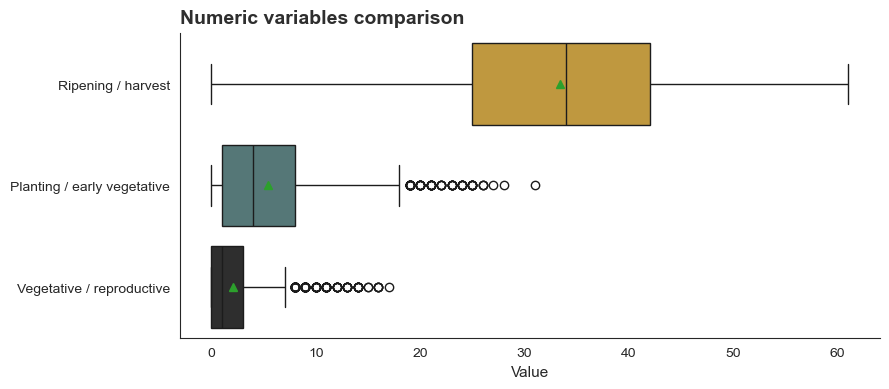

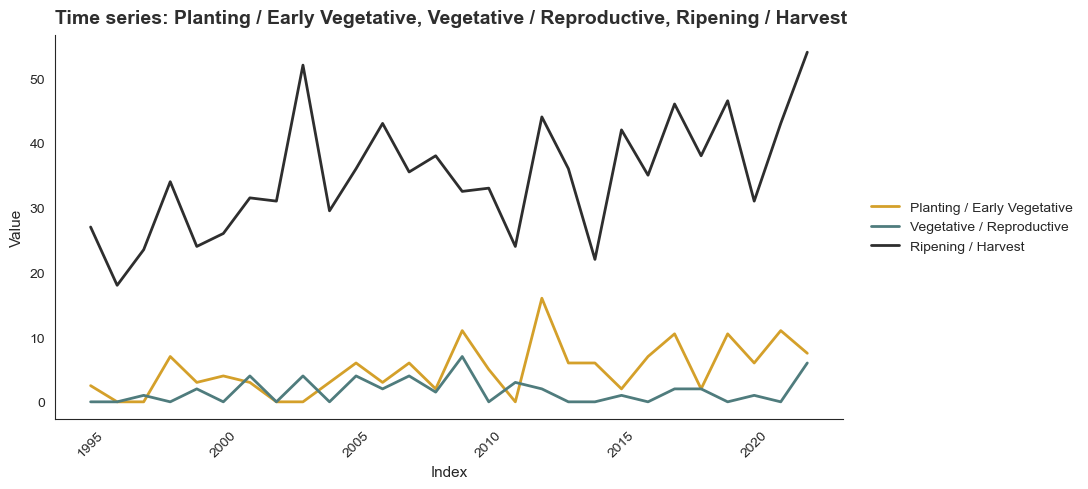


Days Frost 10Pct


,count,mean,std,min,25%,50%,75%,max
variable,,,,,,,,
Planting / early vegetative,2968.0,8.572102,12.896761,0.0,0.0,4.0,10.0,77.0
Ripening / harvest,2968.0,0.248315,1.363493,0.0,0.0,0.0,0.0,19.0
Vegetative / reproductive,2968.0,60.967992,43.126334,0.0,26.0,58.0,84.0,178.0


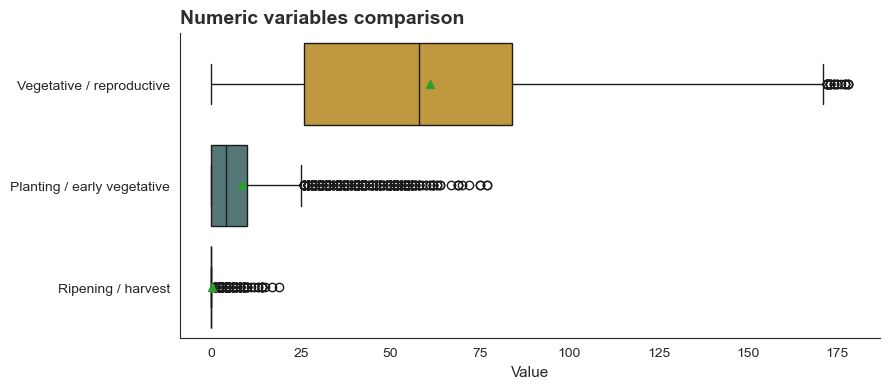

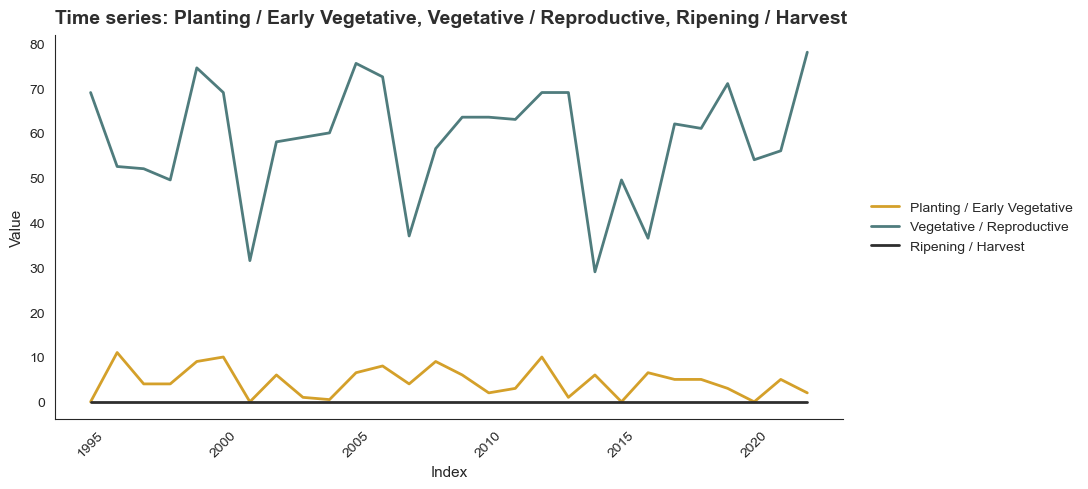


Days Extreme Rain


,count,mean,std,min,25%,50%,75%,max
variable,,,,,,,,
Planting / early vegetative,2968.0,4.506065,2.690275,0.0,3.0,4.0,6.0,17.0
Ripening / harvest,2968.0,2.206199,2.125472,0.0,1.0,2.0,3.0,13.0
Vegetative / reproductive,2968.0,8.302898,4.649954,0.0,5.0,8.0,11.0,29.0


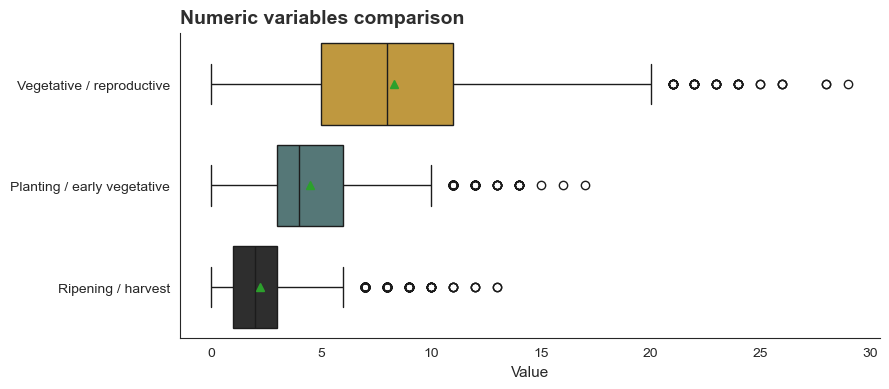

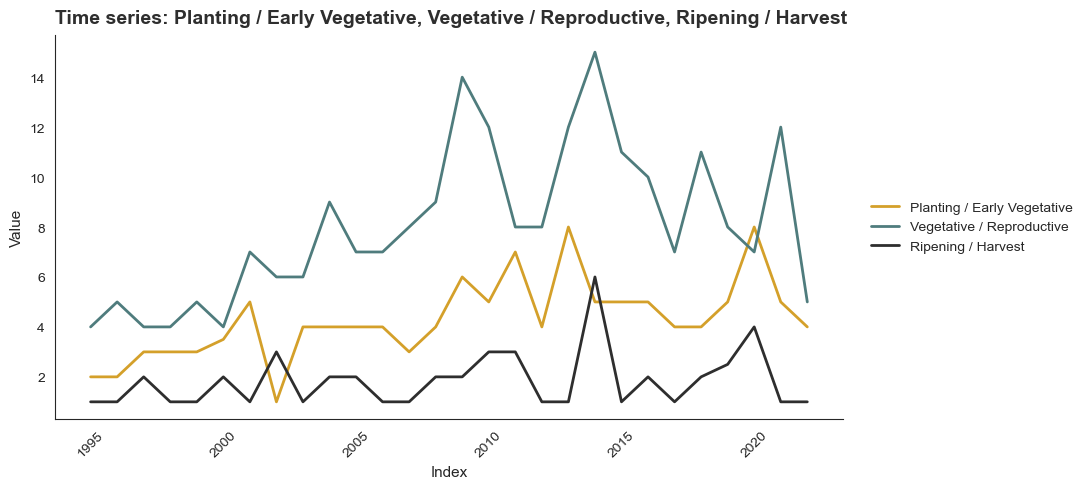


GRAIN MAIZE

Temperature Avg Month


,count,mean,std,min,25%,50%,75%,max
variable,,,,,,,,
Planting / early vegetative,2968.0,12.303739,2.350356,0.780850,11.350000,12.628799,13.788213,17.547576
Ripening / harvest,2968.0,14.763993,2.911282,3.043878,13.342395,14.811561,16.685588,21.161536
Vegetative / reproductive,2968.0,21.047637,2.353484,9.741466,20.222757,21.397052,22.486958,25.602897


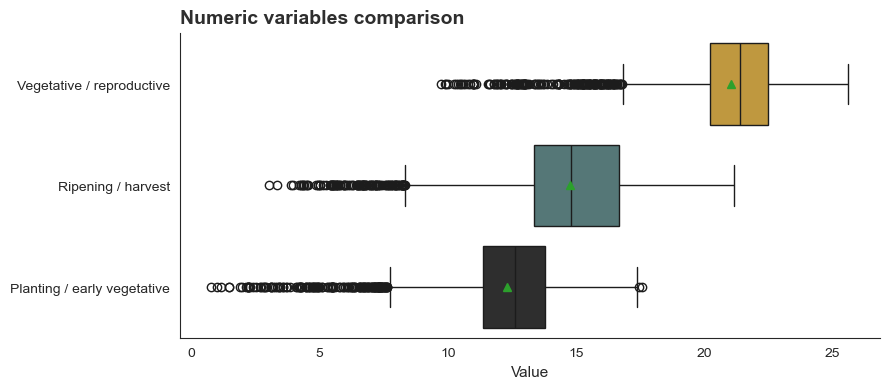

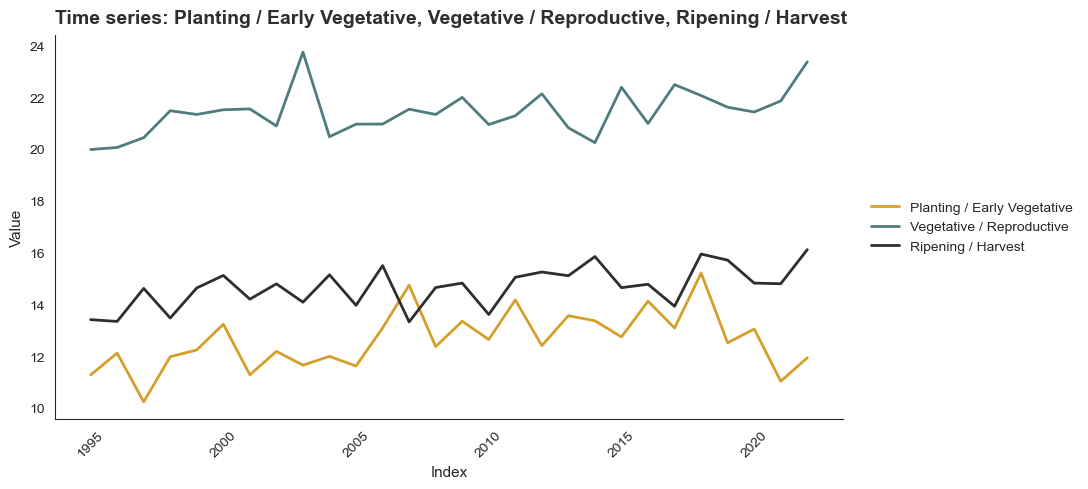


Precipitation Total Month


,count,mean,std,min,25%,50%,75%,max
variable,,,,,,,,
Planting / early vegetative,2968.0,68.339572,44.603733,0.733333,39.273438,59.650581,85.688158,329.842105
Ripening / harvest,2968.0,283.114896,130.475601,41.052632,193.126748,260.557018,340.209900,1110.604651
Vegetative / reproductive,2968.0,207.918497,149.731395,5.421053,96.483851,171.487080,288.650362,998.651163


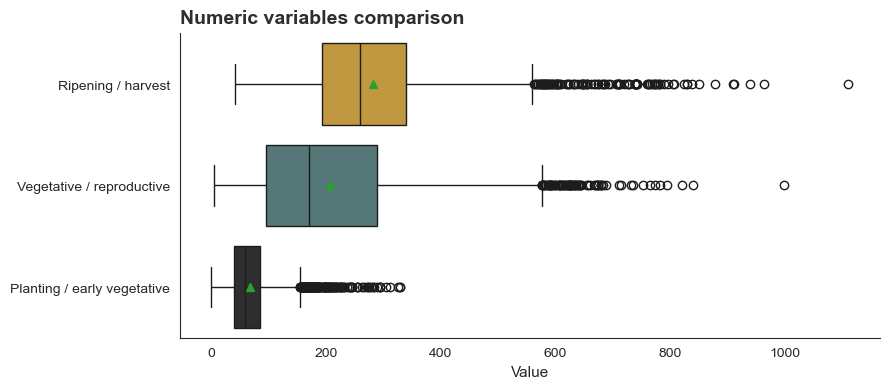

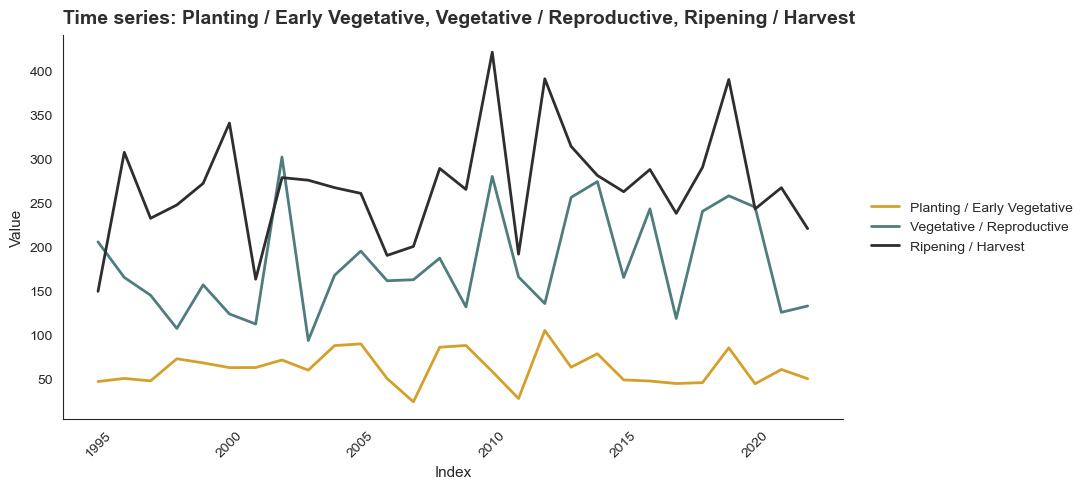


Et0 Total Month


,count,mean,std,min,25%,50%,75%,max
variable,,,,,,,,
Planting / early vegetative,2968.0,87.387126,11.743472,48.384314,79.180114,86.972192,95.589205,126.291667
Ripening / harvest,2968.0,186.639602,42.217371,105.415385,150.955918,181.582331,218.197045,306.332955
Vegetative / reproductive,2968.0,584.175702,72.654645,348.354902,537.094189,584.298203,633.712714,787.201724


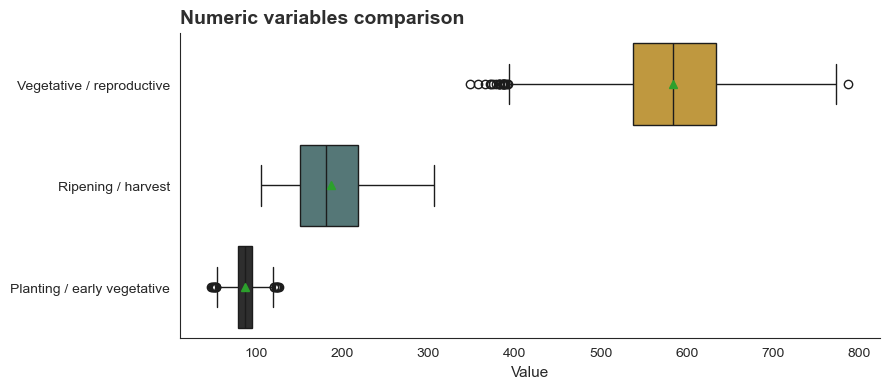

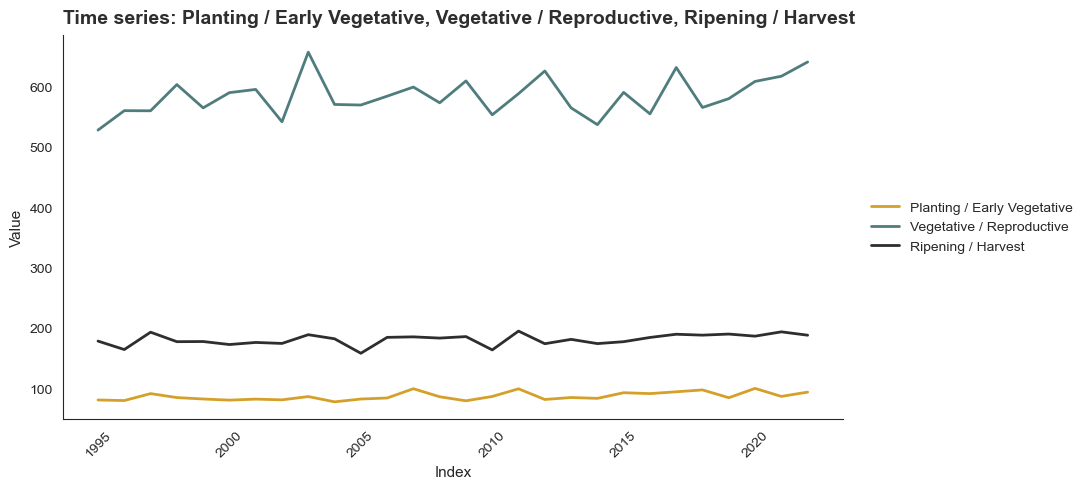


Radiation Total Month


,count,mean,std,min,25%,50%,75%,max
variable,,,,,,,,
Planting / early vegetative,2968.0,5.559252e+05,53514.361433,3.822342e+05,5.191318e+05,5.596342e+05,5.946618e+05,7.400092e+05
Ripening / harvest,2968.0,1.022093e+06,129482.446784,7.448279e+05,9.168667e+05,1.017746e+06,1.121315e+06,1.401840e+06
Vegetative / reproductive,2968.0,2.943240e+06,234090.734222,2.201386e+06,2.772036e+06,2.984994e+06,3.116707e+06,3.676970e+06


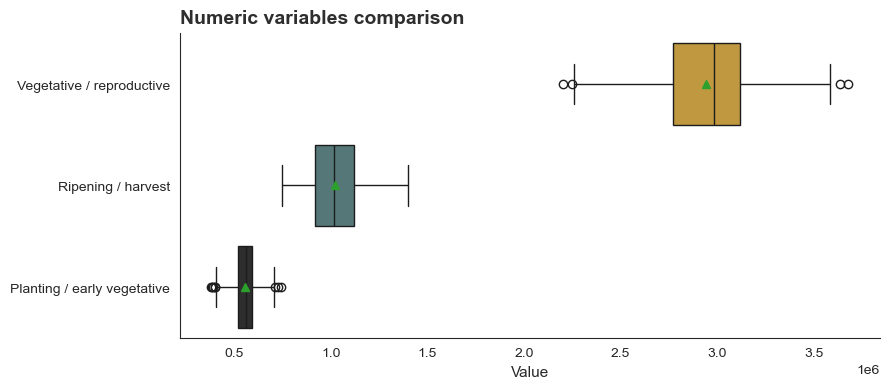

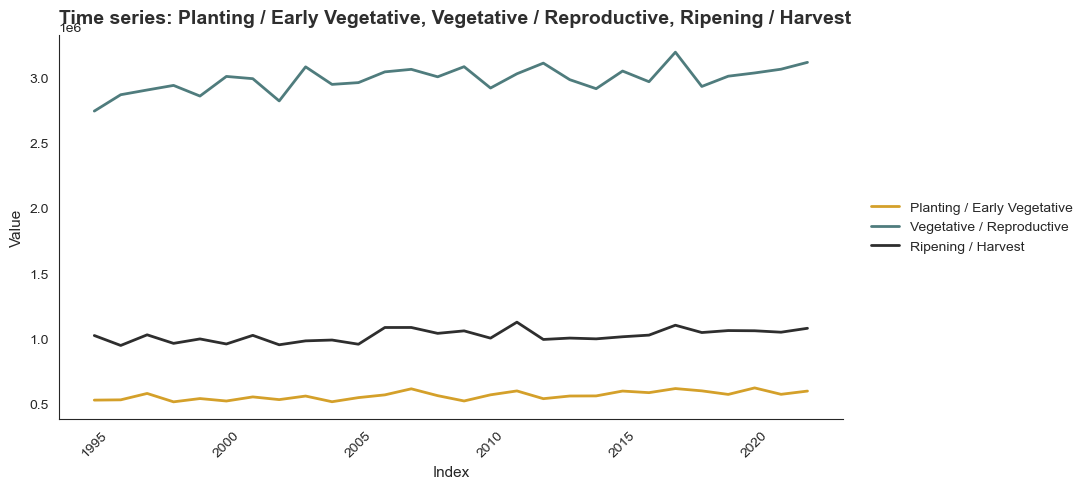


Vapourpressure Avg Month


,count,mean,std,min,25%,50%,75%,max
variable,,,,,,,,
Planting / early vegetative,2968.0,10.311078,1.688942,3.938301,9.333315,10.446306,11.490782,14.869111
Ripening / harvest,2968.0,13.363015,2.322213,5.833475,12.100815,13.306078,14.717937,19.556140
Vegetative / reproductive,2968.0,17.075651,2.146895,9.205465,15.983670,17.186922,18.448054,23.465414


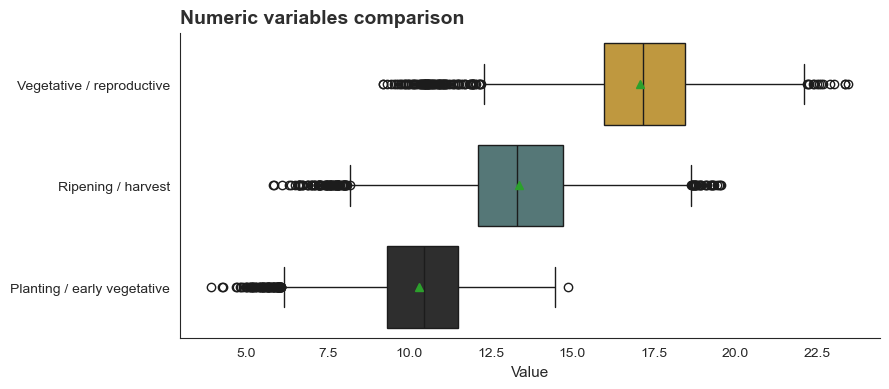

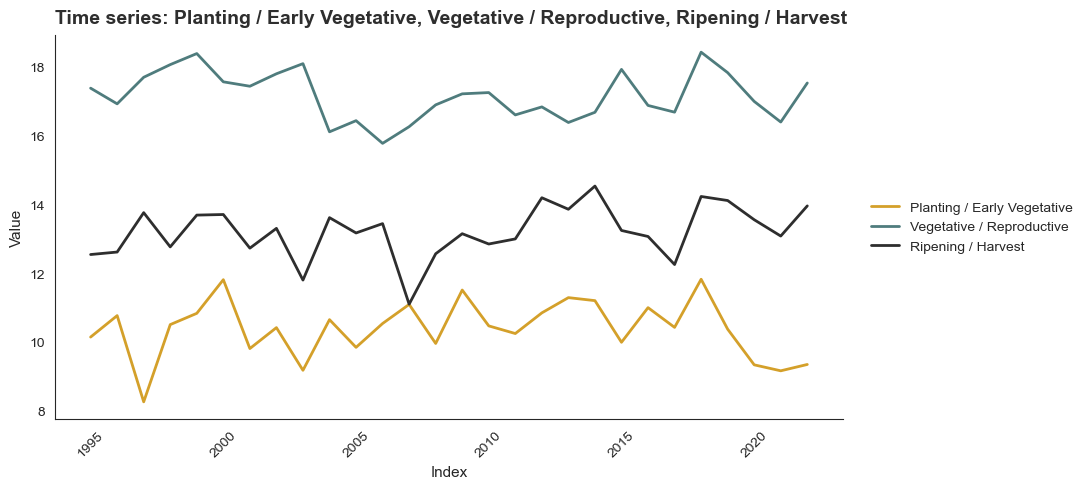


Windspeed Avg Month


,count,mean,std,min,25%,50%,75%,max
variable,,,,,,,,
Planting / early vegetative,2968.0,2.871769,0.837296,1.277105,2.218988,2.692848,3.475684,6.261310
Ripening / harvest,2968.0,2.532397,0.833231,0.891095,1.859652,2.410190,3.180120,6.303465
Vegetative / reproductive,2968.0,2.589238,0.660732,1.120980,2.093256,2.467323,3.020950,5.148128


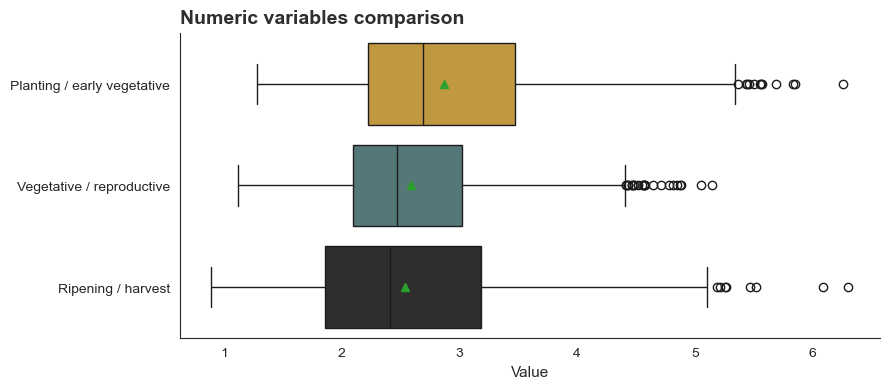

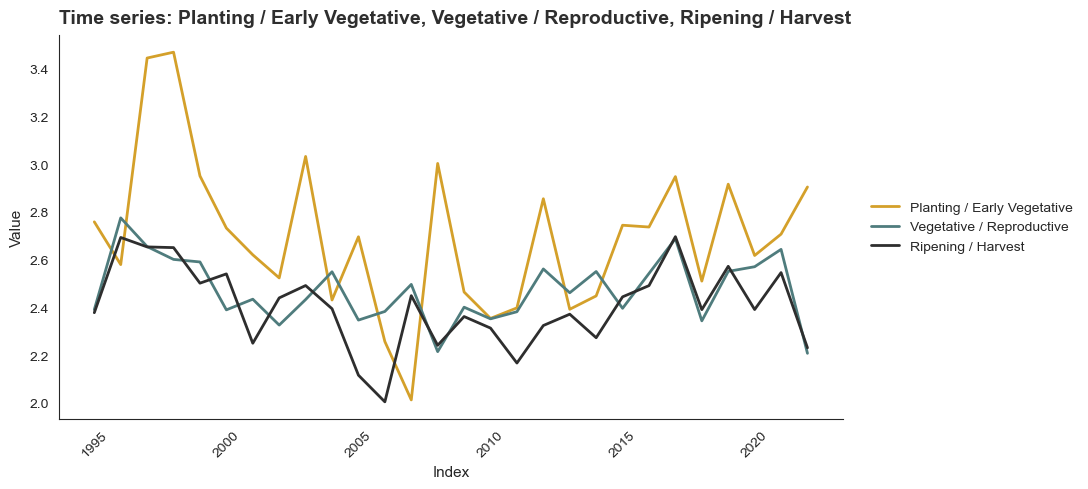


Wet Days Area Mean


,count,mean,std,min,25%,50%,75%,max
variable,,,,,,,,
Planting / early vegetative,2968.0,10.071092,4.078601,0.0,7.0,10.0,13.0,24.0
Ripening / harvest,2968.0,30.839286,7.797322,8.0,25.0,31.0,36.0,57.0
Vegetative / reproductive,2968.0,32.924528,17.552993,1.0,20.0,31.0,44.0,92.0


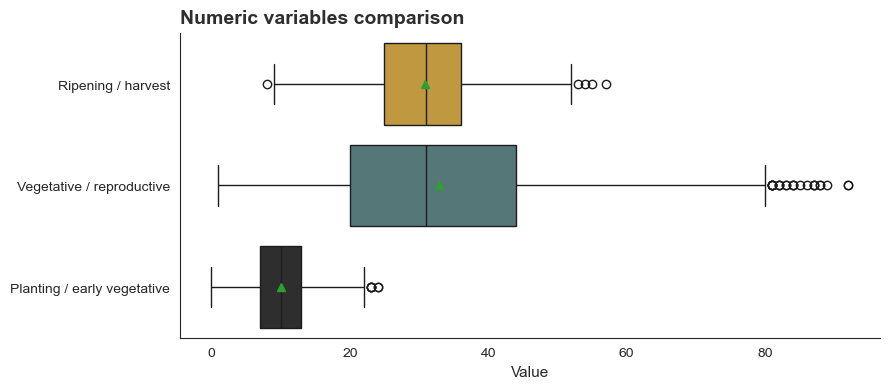

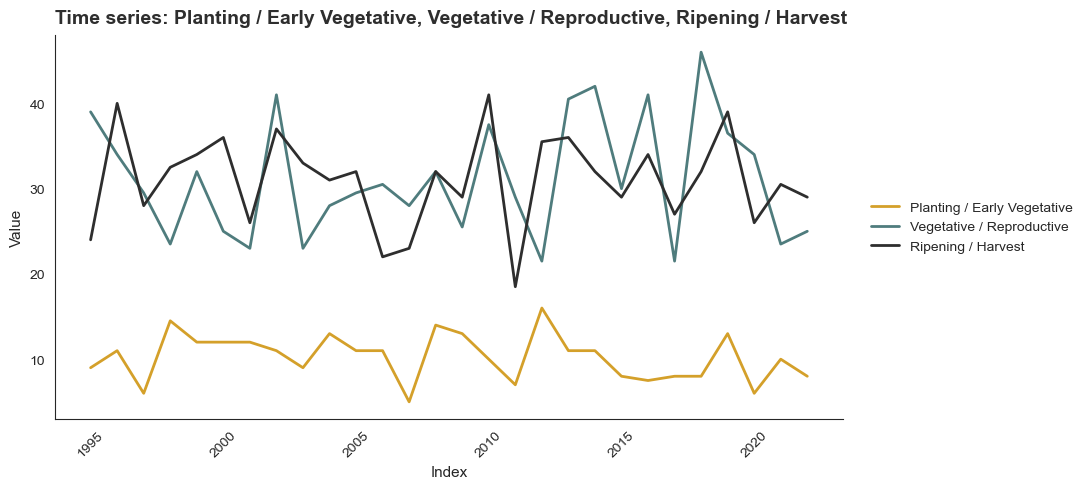


Max Consecutive Dry Days Area Mean


,count,mean,std,min,25%,50%,75%,max
variable,,,,,,,,
Planting / early vegetative,2968.0,9.762466,4.929826,2.0,6.0,8.0,12.0,30.0
Ripening / harvest,2968.0,14.329178,4.935014,4.0,11.0,13.0,17.0,31.0
Vegetative / reproductive,2968.0,17.761119,7.744436,3.0,11.0,17.0,23.0,31.0


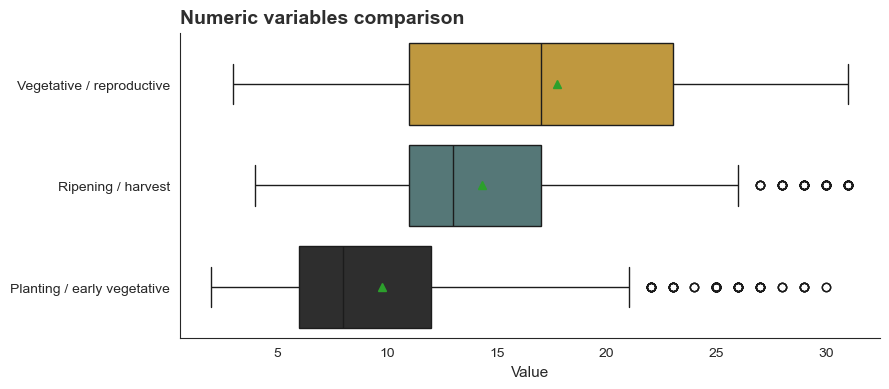

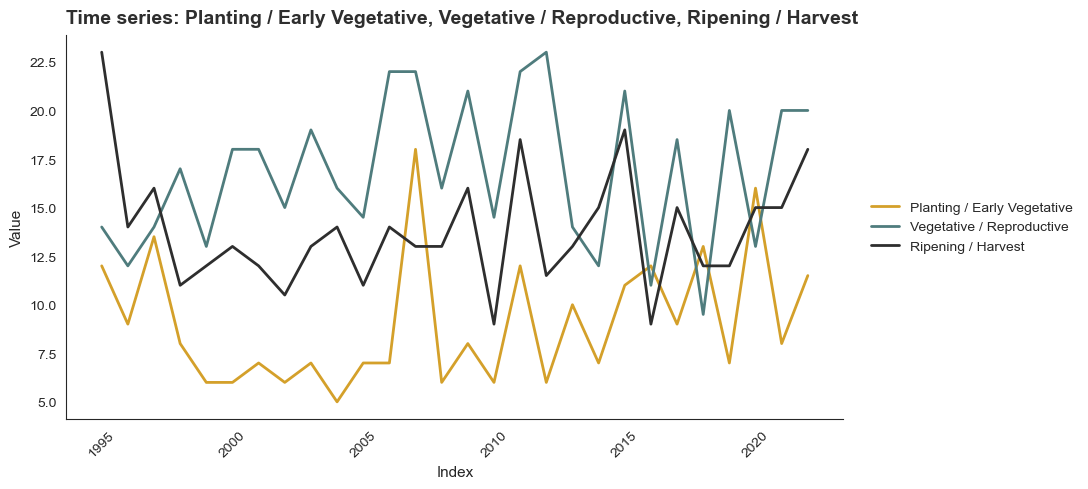


Days Hot 30 10Pct


,count,mean,std,min,25%,50%,75%,max
variable,,,,,,,,
Planting / early vegetative,2968.0,0.066375,0.346354,0.0,0.0,0.0,0.0,5.0
Ripening / harvest,2968.0,5.610849,5.529756,0.0,1.0,4.0,9.0,31.0
Vegetative / reproductive,2968.0,55.881065,19.760301,0.0,43.0,57.0,70.0,107.0


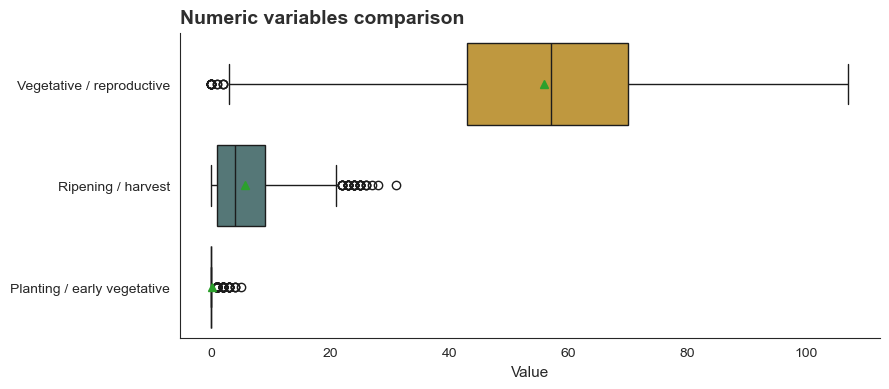

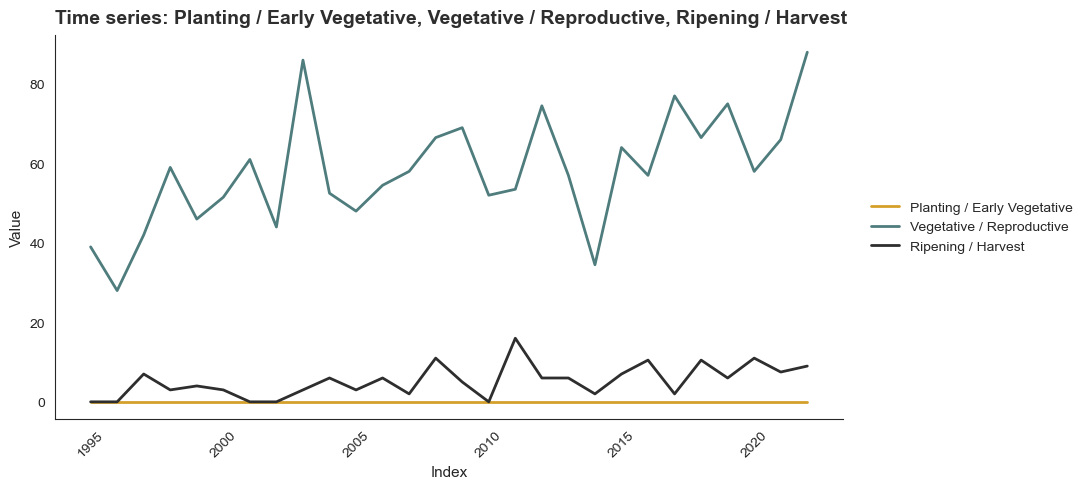


Days Frost 10Pct


,count,mean,std,min,25%,50%,75%,max
variable,,,,,,,,
Planting / early vegetative,2968.0,3.584569,6.839948,0.0,0.0,0.0,3.0,30.0
Ripening / harvest,2968.0,8.542790,12.745157,0.0,0.0,4.0,10.0,77.0
Vegetative / reproductive,2968.0,1.218329,4.865031,0.0,0.0,0.0,0.0,46.0


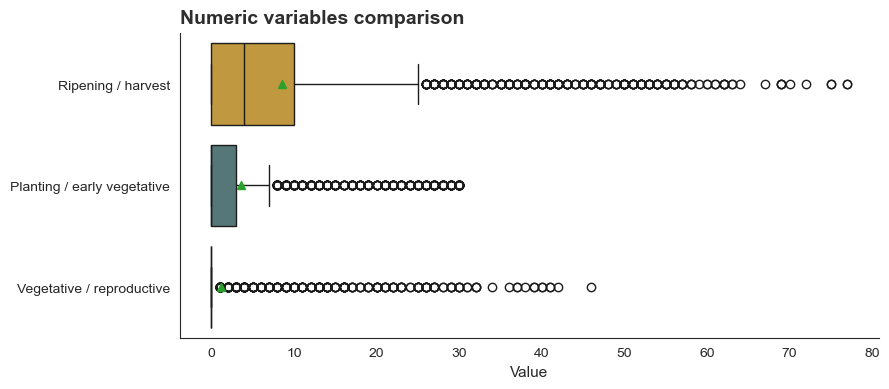

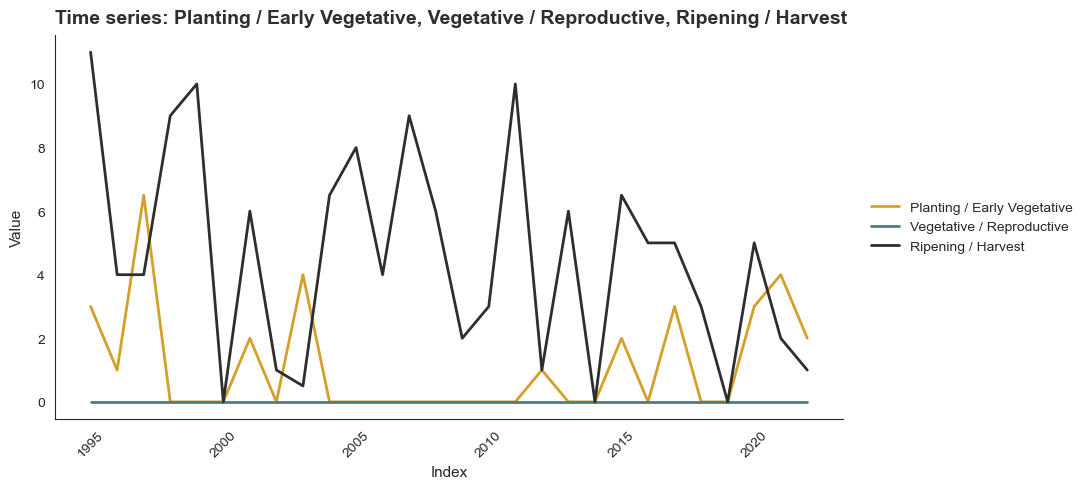


Days Extreme Rain


,count,mean,std,min,25%,50%,75%,max
variable,,,,,,,,
Planting / early vegetative,2968.0,1.419811,1.317600,0.0,0.0,1.0,2.0,9.0
Ripening / harvest,2968.0,4.551213,2.694551,0.0,3.0,4.0,6.0,17.0
Vegetative / reproductive,2968.0,4.676550,3.521396,0.0,2.0,4.0,7.0,22.0


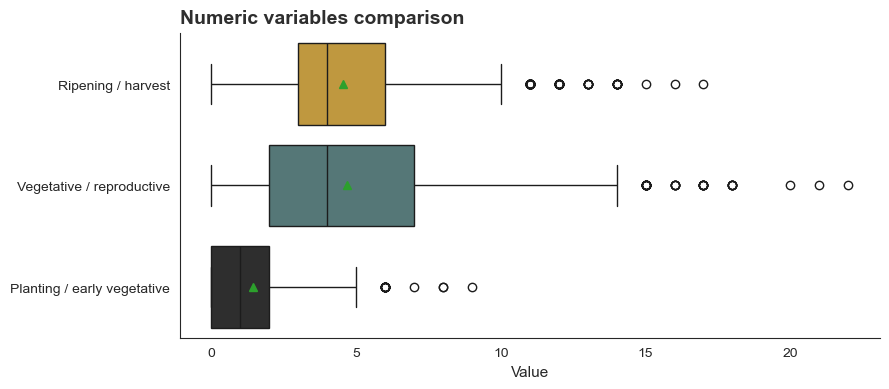

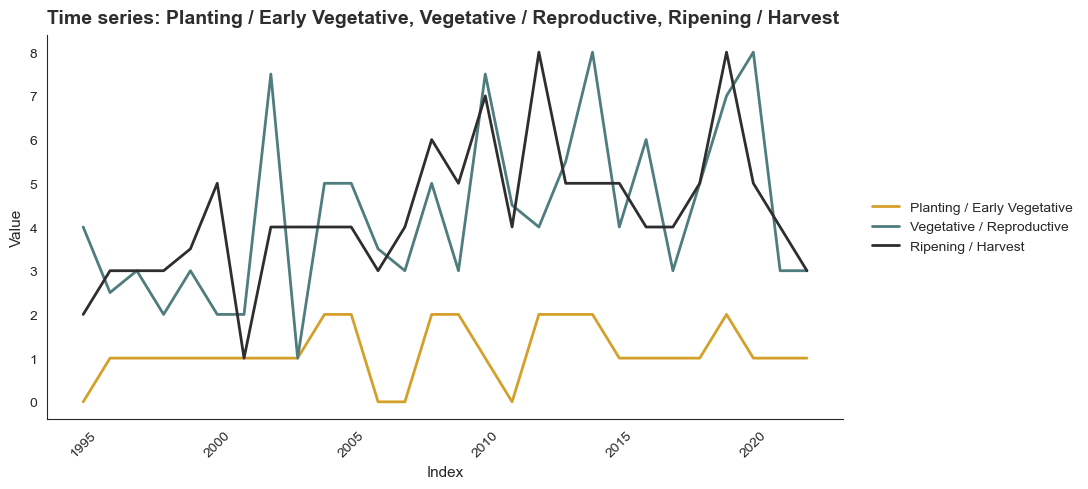

In [67]:
CROP_GROUPS = {
    "Wheat": "Durum wheat",
    "Grain maize": "Grain maize",
}

for crop_label, crop_name in CROP_GROUPS.items():

    print("\n" + crop_label.upper())

    crop_data = modeling_df[
        modeling_df["crop_name"] == crop_name
    ]

    for variable in PHASE_PLOT_SELECTION:

        print("\n" + variable.replace("_", " ").title())

        phase_columns = [
            f"{variable}__{phase}"
            for phase in PHASES
        ]

        rename_map = {
            f"{variable}__{phase}": PHASE_LABELS[phase]
            for phase in PHASES
        }

        # Compare the distributions of the crop phases.
        phase_data = (
            crop_data[phase_columns]
            .rename(columns=rename_map)
        )

        numeric_columns_comparison(
            phase_data,
            phase_data.columns.tolist(),
            kind="box",
            figsize=(9, 4)
        )

        # Show the yearly median across provinces for the same phases.
        yearly_phase_values = (
            crop_data
            .groupby("harvest_year")[phase_columns]
            .median()
            .rename(columns=rename_map)
        )

        plot_time_series(
            yearly_phase_values,
            columns=yearly_phase_values.columns.tolist(),
            figsize=(11, 5)
        )

#### Summary of phase-level environmental patterns

##### Wheat

For the two wheat crops, which share the same phase calendar, the vegetative/reproductive phase is the coolest part of the cycle and contains most frost exposure, while the ripening/harvest phase is clearly warmer and concentrates most hot days.

Water-related variables are more heterogeneous. The vegetative/reproductive phase records the largest precipitation totals, wet-day counts and extreme-rain counts, but it is also the longest phase and therefore accumulates more months. Maximum dry-spell lengths are likewise more pronounced in this phase. Vapour pressure broadly follows the seasonal temperature pattern, while wind speed varies less markedly across phases.

The temporal views suggest that the clearest long-term changes concern heat-related conditions. Temperatures and hot-day counts increase visibly in the ripening/harvest phase, whereas precipitation, wet days, dry spells and extreme-rain counts remain much more irregular from year to year.

##### Grain maize

For grain maize, the phase structure is different. The vegetative/reproductive phase covers the warmest part of the year and shows the highest temperatures, evapotranspiration, radiation and frequency of hot days. Frost exposure is instead concentrated outside this main warm-season phase and is much less relevant during the core development period.

Precipitation is more concentrated toward the ripening/harvest phase, while dry-spell duration remains important during the longer vegetative/reproductive period. As for wheat, totals and event counts must be interpreted together with phase duration.

The temporal series again show the clearest changes in heat-related variables. The vegetative/reproductive phase displays increasing temperatures and hot-day counts, together with rising evapotranspiration and radiation. Water-related indicators remain more variable and do not show an equally clear common direction.

Overall, the results support keeping environmental information separated by crop phase rather than collapsing the whole growing season into a single value. They also suggest that the timing of heat exposure may be particularly informative in the subsequent analysis against yield. The patterns observed here remain descriptive, since no formal trend test is performed in this comparison.